# Top Terms Analysis — Adult (PRR-Filtered)

> **Source:** `filtered_prr/adult_prr_filtered.parquet` (PRR-filtered signals from signal_filtering_and_stratification.ipynb)
> **Dataset:** Adult
> **Output folder:** `data/notebook/output/top_terms_adult/`

This notebook uses the SAME analysis logic as `top_five_faers_terms_pediatric_vs_adult.ipynb`,
but operates on the PRR-filtered signal dataset. For PRR-filtered data, both `df_ped` and `df_adu`
are set to the same underlying dataset to allow the notebook's logic to run unchanged.

In [115]:
from pathlib import Path
import pandas as pd
import polars as pl

try:
    from IPython.display import display
except ImportError:
    display = print

# Paths relative to this notebook (notebook/)
ROOT = Path("..").resolve()
SIGNAL_OUT = ROOT / "data" / "notebook" / "output" / "signal_analysis"

# ──────────────────────────────────────────────────────────────────────────
# VARIANT: Top Terms Analysis — Adult (PRR-Filtered)
# Source: PRR-filtered signal dataset (one row per unique drug-event pair)
# We load the FULL event-level data (not PRR-filtered) for richer analysis,
# but subset to only pairs that passed PRR filter.
# ──────────────────────────────────────────────────────────────────────────

PRR_FILTERED_PATH = SIGNAL_OUT / "filtered_prr/adult_prr_filtered.parquet"
if not PRR_FILTERED_PATH.exists():
    raise FileNotFoundError(f"Run signal_filtering_and_stratification.ipynb first: {PRR_FILTERED_PATH}")

# Load the PRR-filtered pair list
prr_pairs = pl.read_parquet(PRR_FILTERED_PATH)
print(f"PRR-filtered pairs: {prr_pairs.height:,} rows")

# Build a set of (drug, event) keys that passed PRR
pair_key_set = set(zip(prr_pairs["drug"].to_list(), prr_pairs["event"].to_list()))
print(f"Unique (drug, event) signals: {len(pair_key_set):,}")

# Load FULL event data and subset to these pairs
FULL_DATA_ROOT = ROOT / "data" / "output"
ADULT_PATH = FULL_DATA_ROOT / "Adult" / "patient_report_reporter_drug_reaction_full_data.parquet"
PED_PATH = FULL_DATA_ROOT / "Pediatric" / "patient_report_reporter_drug_reaction_full_data.parquet"

print("\nLoading FULL event data ...")
MODE = "adult"
if MODE == "adult":
    df_all = pd.read_parquet(ADULT_PATH)
elif MODE == "pediatric":
    df_all = pd.read_parquet(PED_PATH)
else:  # combined
    df_adult_full = pd.read_parquet(ADULT_PATH)
    df_ped_full = pd.read_parquet(PED_PATH)
    df_all = pd.concat([df_adult_full, df_ped_full], ignore_index=True)
    del df_adult_full, df_ped_full

print(f"Full event rows: {len(df_all):,}")

# Subset to only rows where (medicinal_product, reaction_meddrapt) passed PRR
_key = df_all["medicinal_product"].astype(str) + "||" + df_all["reaction_meddrapt"].astype(str)
_pair_keys = {f"{d}||{e}" for d, e in pair_key_set}
df_filtered = df_all[_key.isin(_pair_keys)].copy()
del df_all, _key

print(f"Filtered rows (PRR-passed pairs only): {len(df_filtered):,}")

# Assign to df_ped and df_adu depending on variant
# (notebook logic expects both dataframes to exist)
if MODE == "adult":
    df_adu = df_filtered
    df_ped = df_filtered.iloc[0:0].copy()  # empty placeholder with same schema
elif MODE == "pediatric":
    df_ped = df_filtered
    df_adu = df_filtered.iloc[0:0].copy()
else:  # combined — use as both for comparison purposes
    df_adu = df_filtered
    df_ped = df_filtered

print(f"\nPediatric rows: {len(df_ped):,} | Adult rows: {len(df_adu):,}")

Loading parquet (may take a while for Adult)...
OK: {'Pediatric': '/ist/ist-share/scads/thanyathonk/fears_dataset/data/output/Pediatric/patient_report_reporter_drug_reaction_full_data.parquet', 'Adult': '/ist/ist-share/scads/thanyathonk/fears_dataset/data/output/Adult/patient_report_reporter_drug_reaction_full_data.parquet'}
Pediatric rows: 953037 | Adult rows: 17813299


In [107]:
import numpy as np


# ── shared ingredient helper ──────────────────────────────────────────────────

def _ing_to_name(val) -> str:
    """Convert ingredient column value (list / ndarray / str) to a readable string."""
    if val is None or (isinstance(val, float) and np.isnan(val)):
        return "(unknown)"
    if isinstance(val, np.ndarray):
        val = val.tolist()
    if isinstance(val, (list, tuple)):
        parts = [str(x).strip() for x in val if x is not None and str(x).strip()]
        return "; ".join(parts) if parts else "(unknown)"
    return str(val).strip() or "(unknown)"


# ── fast label lookup: process only the top-N rows, not the full dataset ──────

def _label_lookups(dedup, key_cols: list, top_df, product_k: int = 10):
    """Precompute display-label components for the top-N rows in top_df.

    Instead of scanning the full `dedup` for every result row (O(N×k)),
    we filter `dedup` to only the top-N keys first (O(N) once), then
    groupby the tiny subset (O(k×m) where m is rows per key).
    """
    has_ing = "ingredient" in dedup.columns

    # Build a string key for fast set-membership test
    sep = "||"
    def _make_key(df, cols):
        key = df[cols[0]].astype(str)
        for c in cols[1:]:
            key = key + sep + df[c].astype(str)
        return key

    top_key_set = set(_make_key(top_df, key_cols))
    key_ser = _make_key(dedup, key_cols)
    dedup_top = dedup[key_ser.isin(top_key_set)].copy()
    dedup_top["_key"] = _make_key(dedup_top, key_cols)

    grp = dedup_top.groupby("_key", observed=True)

    # Most common medicinal_product per key
    def _primary_med(s):
        vc = s.dropna().astype(str).value_counts()
        return str(vc.index[0]) if len(vc) > 0 else "(unknown)"

    med_lkp = grp["medicinal_product"].apply(_primary_med)

    # Top-k medicinal products per key (newline-joined)
    def _top_k_med(s):
        vc = s.dropna().astype(str).value_counts().head(product_k)
        return "\n".join(
            f"{i+1}. {name} ({c})" for i, (name, c) in enumerate(vc.items())
        )

    top_med_lkp = grp["medicinal_product"].apply(_top_k_med)

    # First non-unknown ingredient per key
    if has_ing:
        def _first_ing(series):
            for v in series:
                s = _ing_to_name(v)
                if s != "(unknown)":
                    return s
            return "(unknown)"
        ing_lkp = grp["ingredient"].apply(_first_ing)
    else:
        import pandas as pd
        ing_lkp = pd.Series("(unknown)", index=med_lkp.index)

    return med_lkp, ing_lkp, top_med_lkp


# ── top_n functions ────────────────────────────────────────────────────────────

def top_n_lines(df, col: str, n: int = 5):
    """Frequency by row (drug–reaction lines)."""
    import pandas as pd
    vc = df[col].value_counts().head(n).reset_index()
    vc.columns = [col, "n_lines"]
    return vc


def top_n_reports(df, col: str, n: int = 5):
    """Frequency by distinct safetyreportid (ICSR)."""
    import pandas as pd
    sub = df[["safetyreportid", col]].drop_duplicates()
    vc = sub[col].value_counts().head(n).reset_index()
    vc.columns = [col, "n_reports"]
    return vc


def top_n_lines_rxcui_reaction(df, n: int = 10, product_k: int = 10):
    """Top (rxcui, reaction_meddrapt) pairs by line count with display labels.

    Uses precomputed groupby lookups — fast even on 18M-row Adult data.
    """
    import pandas as pd
    need = ["rxcui", "reaction_meddrapt", "medicinal_product", "safetyreportid"]
    for c in need:
        if c not in df.columns:
            raise ValueError(f"Missing column {c}")

    sub   = df.dropna(subset=["rxcui"])
    dedup = sub.drop_duplicates(subset=["safetyreportid", "rxcui", "reaction_meddrapt"])

    g = (
        dedup.groupby(["rxcui", "reaction_meddrapt"], observed=True)
        .size().reset_index(name="n_lines")
        .sort_values("n_lines", ascending=False).head(n)
    )
    g["pair_label"] = g["rxcui"].astype(str) + " | " + g["reaction_meddrapt"].astype(str)

    med_lkp, ing_lkp, top_med_lkp = _label_lookups(
        dedup, ["rxcui", "reaction_meddrapt"], g, product_k=product_k
    )

    def _key(row):
        return str(row["rxcui"]) + "||" + str(row["reaction_meddrapt"])

    g["medicinal_product_top10"] = g.apply(lambda r: top_med_lkp.get(_key(r), ""), axis=1)
    g["display_label"] = g.apply(
        lambda r: f"{med_lkp.get(_key(r), '(unknown)')}({ing_lkp.get(_key(r), '(unknown)')}) - {r['reaction_meddrapt']}",
        axis=1,
    )
    return g


def top_n_reports_rxcui_reaction(df, n: int = 10, product_k: int = 10):
    """Top (rxcui, reaction_meddrapt) pairs by distinct report count with display labels."""
    import pandas as pd
    need = ["safetyreportid", "rxcui", "reaction_meddrapt", "medicinal_product"]
    for c in need:
        if c not in df.columns:
            raise ValueError(f"Missing column {c}")

    sub   = df.dropna(subset=["rxcui"])
    dedup = sub.drop_duplicates(subset=["safetyreportid", "rxcui", "reaction_meddrapt"])

    g = (
        dedup.groupby(["rxcui", "reaction_meddrapt"], observed=True)
        .size().reset_index(name="n_reports")
        .sort_values("n_reports", ascending=False).head(n)
    )
    g["pair_label"] = g["rxcui"].astype(str) + " | " + g["reaction_meddrapt"].astype(str)

    med_lkp, ing_lkp, top_med_lkp = _label_lookups(
        dedup, ["rxcui", "reaction_meddrapt"], g, product_k=product_k
    )

    def _key(row):
        return str(row["rxcui"]) + "||" + str(row["reaction_meddrapt"])

    g["medicinal_product_top10"] = g.apply(lambda r: top_med_lkp.get(_key(r), ""), axis=1)
    g["display_label"] = g.apply(
        lambda r: f"{med_lkp.get(_key(r), '(unknown)')}({ing_lkp.get(_key(r), '(unknown)')}) - {r['reaction_meddrapt']}",
        axis=1,
    )
    return g


def top_n_lines_rxcui_only(df, n: int = 10):
    """Top rxcui by line count with display labels."""
    import pandas as pd
    need = ["rxcui", "medicinal_product", "safetyreportid"]
    for c in need:
        if c not in df.columns:
            raise ValueError(f"Missing column {c}")

    sub = df.dropna(subset=["rxcui"])
    g = (
        sub.groupby("rxcui", observed=True)
        .size().reset_index(name="n_lines")
        .sort_values("n_lines", ascending=False).head(n)
    )
    g["pair_label"] = g["rxcui"].astype(str)

    med_lkp, ing_lkp, _ = _label_lookups(sub, ["rxcui"], g)
    g["display_label"] = g.apply(
        lambda r: f"{med_lkp.get(str(r['rxcui']), '(unknown)')}({ing_lkp.get(str(r['rxcui']), '(unknown)')})",
        axis=1,
    )
    return g


def top_n_reports_rxcui_only(df, n: int = 10):
    """Top rxcui by distinct report count with display labels."""
    import pandas as pd
    need = ["rxcui", "medicinal_product", "safetyreportid"]
    for c in need:
        if c not in df.columns:
            raise ValueError(f"Missing column {c}")

    sub   = df.dropna(subset=["rxcui"])
    dedup = sub.drop_duplicates(subset=["safetyreportid", "rxcui"])
    g = (
        dedup.groupby("rxcui", observed=True)
        .size().reset_index(name="n_reports")
        .sort_values("n_reports", ascending=False).head(n)
    )
    g["pair_label"] = g["rxcui"].astype(str)

    med_lkp, ing_lkp, _ = _label_lookups(dedup, ["rxcui"], g)
    g["display_label"] = g.apply(
        lambda r: f"{med_lkp.get(str(r['rxcui']), '(unknown)')}({ing_lkp.get(str(r['rxcui']), '(unknown)')})",
        axis=1,
    )
    return g


# ── comparison / plot helpers (unchanged) ─────────────────────────────────────

import textwrap
import matplotlib.pyplot as plt


def show_side_by_side(ped, adu, col, *, count_col=None):
    """Align top-N rows by rank index for comparison (not a join on term)."""
    if count_col is None:
        count_ped = [c for c in ped.columns if c != col][0]
        count_adu = [c for c in adu.columns if c != col][0]
    else:
        count_ped = count_adu = count_col
    ped2 = ped.reset_index(drop=True).copy()
    ped2.insert(0, "rank", range(1, len(ped2) + 1))
    ped2 = ped2.rename(columns={col: "Pediatric", count_ped: f"{count_ped}_ped"})
    adu2 = adu.reset_index(drop=True).copy()
    adu2.insert(0, "rank", range(1, len(adu2) + 1))
    adu2 = adu2.rename(columns={col: "Adult", count_adu: f"{count_adu}_adu"})
    return ped2.merge(adu2, on="rank", how="outer").sort_values("rank")


def setup_plot_style():
    plt.rcParams["figure.dpi"]  = 110
    plt.rcParams["font.size"]   = 9
    plt.rcParams["axes.titlepad"] = 14


def shorten_label(s, max_len: int = 52) -> str:
    t = str(s)
    return t if len(t) <= max_len else t[: max_len - 1] + chr(8230)


def plot_barh_topn(df, label_col, value_col, title, ax=None, color="#2b6cb0", *,
                   title_wrap=48, show_bar_labels=True, show_pct=True,
                   pct_denominator=None, pct_digits=1, bar_label_fontsize=8, xlabel=None):
    if ax is None:
        _, ax = plt.subplots(figsize=(9, 4.2))
    d    = df.iloc[::-1]
    y    = d[label_col].astype(str)
    vals = d[value_col].to_numpy()
    bars = ax.barh(y, vals, color=color)
    wrapped = textwrap.fill(title, width=title_wrap, break_long_words=False, break_on_hyphens=True) if title_wrap and title else title
    ax.set_title(wrapped, fontsize=10, pad=14, loc="left")
    ax.set_xlabel(xlabel if xlabel is not None else value_col)
    ax.margins(x=0.02)
    if len(vals):
        vmax = float(np.nanmax(vals.astype(float)))
        if np.isfinite(vmax) and vmax > 0:
            ax.set_xlim(0, vmax * (1.22 if (show_bar_labels and show_pct) else 1.14))
    if show_bar_labels and len(bars.patches):
        den = float(pct_denominator) if pct_denominator is not None else float(np.nansum(df[value_col].astype(float)))
        if not np.isfinite(den) or den <= 0:
            den = 1.0
        lbls = []
        for v in vals:
            if not np.isfinite(float(v)):
                lbls.append(""); continue
            base = f"{int(round(float(v))):,}" if abs(float(v) - round(float(v))) <= 1e-6 * max(1.0, abs(float(v))) else f"{float(v):.3g}"
            lbls.append(f"{base} ({100.0*float(v)/den:.{pct_digits}f}%)" if show_pct else base)
        ax.bar_label(bars, labels=lbls, padding=4, fontsize=bar_label_fontsize)
    return ax


def plot_barh_grouped(df, term_col, ped_col, adu_col, title, figsize=(14, 7),
                      ped_color="#2b6cb0", adu_color="#c05621",
                      bar_label_fontsize=7, title_wrap=64, xlabel="distinct reports", label_max_len=60):
    fig, ax = plt.subplots(figsize=figsize)
    d     = df.iloc[::-1].reset_index(drop=True)
    terms = d[term_col].astype(str).apply(lambda s: shorten_label(s, label_max_len))
    y, h  = np.arange(len(terms)), 0.38
    bars_ped = ax.barh(y + h/2, d[ped_col].astype(float), h, label="Pediatric", color=ped_color)
    bars_adu = ax.barh(y - h/2, d[adu_col].astype(float), h, label="Adult",     color=adu_color)
    ax.set_yticks(y); ax.set_yticklabels(terms, fontsize=8)
    ax.set_xlabel(xlabel)
    ax.set_title(textwrap.fill(title, width=title_wrap, break_long_words=False), fontsize=10, pad=14, loc="left")
    ax.legend(loc="lower right", fontsize=8)
    vmax = max(float(d[ped_col].max()), float(d[adu_col].max()))
    if vmax > 0:
        ax.set_xlim(0, vmax * 1.22)
    def _fmt(x):
        try:   return f"{int(round(float(x))):,}"
        except: return ""
    ax.bar_label(bars_ped, labels=[_fmt(v) for v in d[ped_col]], padding=3, fontsize=bar_label_fontsize)
    ax.bar_label(bars_adu, labels=[_fmt(v) for v in d[adu_col]], padding=3, fontsize=bar_label_fontsize)
    plt.tight_layout()
    return fig, ax


def plot_barh_stacked_pct(df, term_col, ped_col, adu_col, title, figsize=(14, 7),
                          ped_color="#2b6cb0", adu_color="#c05621",
                          bar_label_fontsize=8, title_wrap=64, label_max_len=60,
                          ped_denom=None, adu_denom=None):
    """Stacked bar chart — Ped (left) | Adult (right).

    Labels drawn INSIDE wide bars (white) or OUTSIDE narrow bars (coloured).
    Threshold: bar < 8% of total bar width → label drawn outside to avoid overlap.
    """
    fig, ax = plt.subplots(figsize=figsize)
    d     = df.iloc[::-1].reset_index(drop=True)
    terms = d[term_col].astype(str).apply(lambda s: shorten_label(s, label_max_len))
    y, h  = np.arange(len(terms)), 0.55
    n_ped   = d[ped_col].astype(float).to_numpy()
    n_adu   = d[adu_col].astype(float).to_numpy()
    n_tot   = n_ped + n_adu
    n_safe  = np.where(n_tot == 0, 1.0, n_tot)
    pct_ped = 100.0 * n_ped / float(ped_denom) if ped_denom else 100.0 * n_ped / n_safe
    pct_adu = 100.0 * n_adu / float(adu_denom) if adu_denom else 100.0 * n_adu / n_safe
    ax.barh(y, n_ped, h, label="Pediatric", color=ped_color)
    ax.barh(y, n_adu, h, left=n_ped, label="Adult", color=adu_color)
    ax.set_yticks(y); ax.set_yticklabels(terms, fontsize=8)
    ax.set_xlabel("distinct reports in intersection (Pediatric + Adult)")
    ax.set_title(textwrap.fill(title, width=title_wrap, break_long_words=False), fontsize=10, pad=14, loc="left")
    ax.legend(loc="lower right", fontsize=9, framealpha=0.85)
    vmax = float(n_tot.max()) if len(n_tot) else 1.0
    ax.set_xlim(0, vmax * 1.48)          # extra space for outside labels
    min_inside = vmax * 0.08             # bars narrower than this → label outside
    def _lbl(cnt, pct): return f"{int(round(cnt)):,} ({pct:.1f}%)"
    for i, (cnt, pct) in enumerate(zip(n_ped, pct_ped)):
        if cnt <= 0: continue
        lbl = _lbl(cnt, pct)
        if cnt >= min_inside:
            ax.text(cnt / 2, y[i], lbl, ha="center", va="center",
                    fontsize=bar_label_fontsize, color="white", fontweight="bold", clip_on=False)
        else:
            ax.text(cnt + vmax * 0.005, y[i] + h * 0.52, lbl, ha="left", va="bottom",
                    fontsize=bar_label_fontsize - 1, color=ped_color, fontweight="bold", clip_on=False)
    for i, (cnt, pct, left) in enumerate(zip(n_adu, pct_adu, n_ped)):
        if cnt <= 0: continue
        lbl = _lbl(cnt, pct)
        if cnt >= min_inside:
            ax.text(left + cnt / 2, y[i], lbl, ha="center", va="center",
                    fontsize=bar_label_fontsize, color="white", fontweight="bold", clip_on=False)
        else:
            ax.text(left + cnt + vmax * 0.005, y[i] - h * 0.52, lbl, ha="left", va="top",
                    fontsize=bar_label_fontsize - 1, color=adu_color, fontweight="bold", clip_on=False)
    plt.tight_layout()
    return fig, ax


def plot_barh_intersection(df, term_col, ped_col, adu_col, title, figsize=(16, 9),
                           ped_color="#6BAED6", adu_color="#FD8D3C",
                           label_fontsize=9, title_wrap=90, label_max_len=65,
                           ped_denom=None, adu_denom=None,
                           xlabel="% of each cohort\'s intersection reports"):
    """Stacked horizontal percentage bar — x-axis ALWAYS starts at 0.

    Segment labels:
      wide  (>=6% of widest bar) : 'N\n(X%)' centred inside, white bold
      narrow (<6%)               : label above the bar + small tick line
    Pastel palette: Ped=#6BAED6 (blue), Adult=#FD8D3C (orange).
    """
    fig, ax = plt.subplots(figsize=figsize)
    d     = df.iloc[::-1].reset_index(drop=True)
    n     = len(d)
    terms = d[term_col].astype(str).apply(lambda s: shorten_label(s, label_max_len))

    n_ped = d[ped_col].astype(float).to_numpy()
    n_adu = d[adu_col].astype(float).to_numpy()
    pct_ped = 100.0 * n_ped / float(ped_denom) if ped_denom else n_ped.copy()
    pct_adu = 100.0 * n_adu / float(adu_denom) if adu_denom else n_adu.copy()

    y_pos = np.arange(n, dtype=float)
    h     = 0.55

    ped_lbl = f"Pediatric  (n={ped_denom:,})" if ped_denom else "Pediatric"
    adu_lbl = f"Adult  (n={adu_denom:,})"     if adu_denom else "Adult"
    ax.barh(y_pos, pct_ped, h, color=ped_color, label=ped_lbl,
            zorder=3, edgecolor="white", linewidth=0.5)
    ax.barh(y_pos, pct_adu, h, left=pct_ped, color=adu_color, label=adu_lbl,
            zorder=3, edgecolor="white", linewidth=0.5)

    vmax      = float((pct_ped + pct_adu).max())
    threshold = vmax * 0.06
    above_gap = h / 2 + 0.06

    # ── Pediatric labels ──────────────────────────────────────────────────────
    for i, (raw, pct) in enumerate(zip(n_ped, pct_ped)):
        lbl = f"{int(round(raw)):,} ({pct:.1f}%)"
        if pct >= threshold:
            ax.text(pct / 2, y_pos[i], f"{int(round(raw)):,}\n({pct:.1f}%)",
                    ha="center", va="center", fontsize=label_fontsize,
                    color="white", fontweight="bold", linespacing=1.3)
        else:
            # above bar + small tick — stays at x>=0
            x_pos = max(pct / 2, vmax * 0.003)
            ax.text(x_pos, y_pos[i] + above_gap, lbl,
                    ha="center", va="bottom", fontsize=label_fontsize - 1.5,
                    color=ped_color, fontweight="bold", clip_on=False)
            ax.plot([x_pos, x_pos],
                    [y_pos[i] + h / 2, y_pos[i] + above_gap - 0.02],
                    color=ped_color, lw=0.8, clip_on=False)

    # ── Adult labels ─────────────────────────────────────────────────────────
    for i, (raw, pct, left) in enumerate(zip(n_adu, pct_adu, pct_ped)):
        lbl = f"{int(round(raw)):,} ({pct:.1f}%)"
        if pct >= threshold:
            ax.text(left + pct / 2, y_pos[i], f"{int(round(raw)):,}\n({pct:.1f}%)",
                    ha="center", va="center", fontsize=label_fontsize,
                    color="white", fontweight="bold", linespacing=1.3)
        else:
            ax.text(left + pct + vmax * 0.008, y_pos[i], lbl,
                    ha="left", va="center", fontsize=label_fontsize - 1.5,
                    color=adu_color, fontweight="bold", clip_on=False)

    # ── Axes formatting ───────────────────────────────────────────────────────
    ax.set_xlim(0, vmax * 1.18)
    ax.xaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f"{x:.0f}%"))
    ax.set_yticks(y_pos)
    ax.set_yticklabels(terms, fontsize=9)
    ax.set_xlabel(xlabel, fontsize=9)
    ax.set_title(
        textwrap.fill(title, width=title_wrap, break_long_words=False),
        fontsize=11, pad=14, loc="left", fontweight="bold",
    )
    ax.legend(loc="lower right", fontsize=9, framealpha=0.85)
    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)
    ax.spines["left"].set_visible(False)
    ax.tick_params(axis="y", length=0)
    ax.grid(axis="x", linestyle="--", alpha=0.35, zorder=0)
    ax.set_axisbelow(True)
    # Re-assert xlim AFTER all drawing is done — prevents auto-margin from adding negative space
    ax.set_xlim(0, vmax * 1.18)
    return fig, ax


def intersect_adr_reports(df_ped, df_adu, n=10, col="reaction_meddrapt"):
    """Top N ADR terms in Ped & Adult intersection."""
    import pandas as pd
    isect = set(df_ped[col].dropna().astype(str)) & set(df_adu[col].dropna().astype(str))
    def _cnts(df, sfx):
        sub = df[df[col].astype(str).isin(isect)].drop_duplicates(["safetyreportid", col])
        vc  = sub[col].value_counts().reset_index()
        vc.columns = [col, f"n_{sfx}"]
        return vc
    merged = _cnts(df_ped, "ped").merge(_cnts(df_adu, "adu"), on=col, how="inner")
    merged["n_combined"] = merged["n_ped"] + merged["n_adu"]
    merged = merged.sort_values("n_combined", ascending=False).head(n).reset_index(drop=True)
    merged.insert(0, "rank", range(1, len(merged)+1))
    return merged


def intersect_drug_reports(df_ped, df_adu, n=10):
    """Top N rxcui values in Ped & Adult intersection."""
    import pandas as pd
    isect = set(df_ped["rxcui"].dropna()) & set(df_adu["rxcui"].dropna())
    df_p  = df_ped[df_ped["rxcui"].isin(isect)].dropna(subset=["rxcui"])
    df_a  = df_adu[df_adu["rxcui"].isin(isect)].dropna(subset=["rxcui"])
    def _cnts(df, sfx):
        return df.drop_duplicates(["safetyreportid","rxcui"]).groupby("rxcui", observed=True).size().reset_index(name=f"n_{sfx}")
    merged = _cnts(df_p,"ped").merge(_cnts(df_a,"adu"), on="rxcui", how="inner")
    merged["n_combined"] = merged["n_ped"] + merged["n_adu"]
    merged = merged.sort_values("n_combined", ascending=False).head(n).reset_index(drop=True)
    merged.insert(0, "rank", range(1, len(merged)+1))
    med_lkp, ing_lkp, _ = _label_lookups(df_p, ["rxcui"], merged)
    merged["display_label"] = merged["rxcui"].apply(
        lambda r: f"{med_lkp.get(str(r),'(unknown)')}({ing_lkp.get(str(r),'(unknown)')})"
    )
    return merged


def intersect_drug_adr_reports(df_ped, df_adu, n=10):
    """Top N (rxcui, reaction_meddrapt) pairs in Ped & Adult intersection."""
    import pandas as pd
    def _pair_set(df):
        sub = df.dropna(subset=["rxcui"])[["rxcui","reaction_meddrapt"]].drop_duplicates()
        return set(zip(sub["rxcui"].astype(str), sub["reaction_meddrapt"].astype(str)))
    isect_keys = {rx+"||"+adr for rx,adr in _pair_set(df_ped) & _pair_set(df_adu)}
    def _filter(df):
        sub = df.dropna(subset=["rxcui"]).copy()
        sub["_key"] = sub["rxcui"].astype(str) + "||" + sub["reaction_meddrapt"].astype(str)
        return sub[sub["_key"].isin(isect_keys)].drop(columns=["_key"])
    df_p = _filter(df_ped)
    df_a = _filter(df_adu)
    def _cnts(df, sfx):
        return df.drop_duplicates(["safetyreportid","rxcui","reaction_meddrapt"]).groupby(["rxcui","reaction_meddrapt"], observed=True).size().reset_index(name=f"n_{sfx}")
    merged = _cnts(df_p,"ped").merge(_cnts(df_a,"adu"), on=["rxcui","reaction_meddrapt"], how="inner")
    merged["n_combined"] = merged["n_ped"] + merged["n_adu"]
    merged = merged.sort_values("n_combined", ascending=False).head(n).reset_index(drop=True)
    merged.insert(0, "rank", range(1, len(merged)+1))
    dedup_p = df_p.drop_duplicates(["safetyreportid","rxcui","reaction_meddrapt"])
    med_lkp, ing_lkp, _ = _label_lookups(dedup_p, ["rxcui","reaction_meddrapt"], merged)
    def _key(row): return str(row["rxcui"]) + "||" + str(row["reaction_meddrapt"])
    merged["display_label"] = merged.apply(
        lambda r: f"{med_lkp.get(_key(r),'(unknown)')}({ing_lkp.get(_key(r),'(unknown)')}) -- {r['reaction_meddrapt']}",
        axis=1
    )
    return merged


print("Helper functions defined.")


Helper functions defined.


# A — Demographics, Reporting & Severity

ภาพรวมของข้อมูลรายงานยาใน FAERS แบ่งตามกลุ่ม Pediatric และ Adult

| กราฟ | ข้อมูล |
|------|--------|
| Pie chart | สัดส่วน Pediatric vs Adult (จำนวน unique `safetyreportid`) |
| NICHD bands | การแจกแจงช่วงอายุใน Pediatric (Neonate → Adolescent) |
| Annual trend | จำนวนรายงานรายปี 2014–2025 |
| Severity bars | จำนวน unique drug–reaction pairs แบ่งตาม seriousness class |

In [39]:
df_adu.columns

Index(['safetyreportid', 'age_years', 'patient_sex', 'receive_date',
       'mostrecent_receive_date', 'lastupdate_date', 'serious',
       'congenital_anomali', 'death', 'disabling', 'hospitalization',
       'life_threatening', 'other', 'reporter_country', 'reporter_company',
       'reporter_qualification', 'medicinal_product', 'rxcui',
       'mapping_method', 'ingredient', 'faers_ingredients', 'ingredient_count',
       'faers_ingredient_count', 'is_combination_product',
       'drug_characterization', 'drug_administration', 'drug_indication',
       'reaction_meddrapt', 'reaction_outcome', 'meddra_concept_id',
       'meddra_concept_code', 'meddra_soc_codes', 'meddra_soc_names'],
      dtype='object')

In [40]:
df_ped['nichd'].value_counts()

early_adolescence    317459
late_adolescence     228528
middle_childhood     173351
early_childhood      136785
infancy               64675
toddler               32239
Name: nichd, dtype: int64

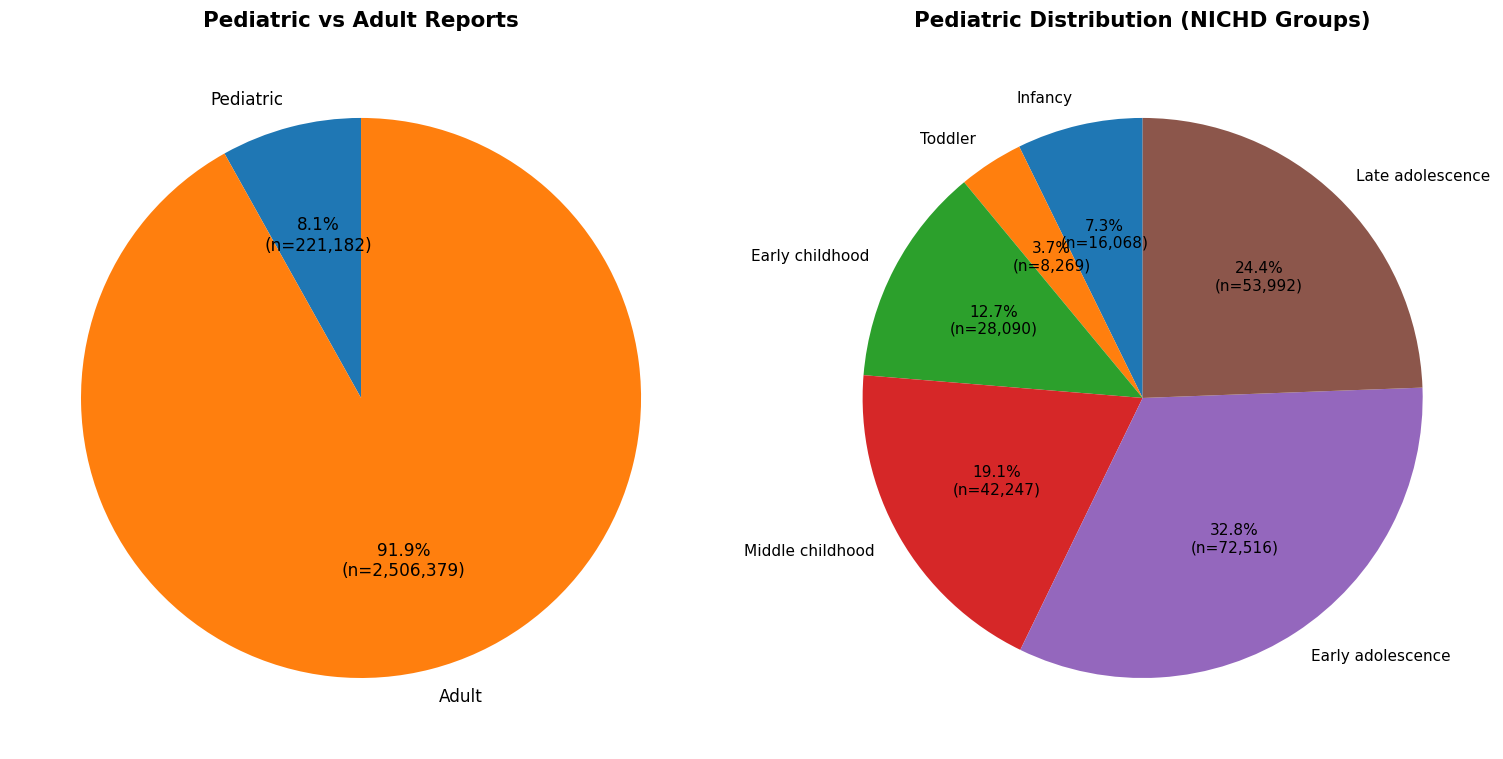

In [41]:
import matplotlib.pyplot as plt
import pandas as pd

# =========================================
# 1) Count data
# =========================================
# ถ้าอยากนับเป็นจำนวนเคสจริง แนะนำใช้ nunique()
ped_count = df_ped["safetyreportid"].nunique()
adu_count = df_adu["safetyreportid"].nunique()

outer_labels = ["Pediatric", "Adult"]
outer_sizes = [ped_count, adu_count]

# -----------------------------------------
# NICHD groups (เด็ก)
# -----------------------------------------
nichd_order = [
    "infancy",
    "toddler",
    "early_childhood",
    "middle_childhood",
    "early_adolescence",
    "late_adolescence",
]

nichd_counts = (
    df_ped[["safetyreportid", "nichd"]]
    .drop_duplicates()
    ["nichd"]
    .value_counts()
    .reindex(nichd_order, fill_value=0)
)

inner_labels = [
    "Infancy",
    "Toddler",
    "Early childhood",
    "Middle childhood",
    "Early adolescence",
    "Late adolescence",
]
inner_sizes = nichd_counts.values

# =========================================
# 2) Label function
# =========================================
def autopct_with_n(values):
    total = sum(values)
    def _fmt(pct):
        n = int(round(pct * total / 100.0))
        return f"{pct:.1f}%\n(n={n:,})"
    return _fmt

# =========================================
# 3) Plot
# =========================================
fig, axes = plt.subplots(1, 2, figsize=(14, 7))

# -------- Pie 1: Pediatric vs Adult --------
axes[0].pie(
    outer_sizes,
    labels=outer_labels,
    autopct=autopct_with_n(outer_sizes),
    startangle=90,
    textprops=dict(fontsize=11)
)
axes[0].set_title("Pediatric vs Adult Reports", fontsize=14, weight="bold")

# -------- Pie 2: Pediatric NICHD --------
axes[1].pie(
    inner_sizes,
    labels=inner_labels,
    autopct=autopct_with_n(inner_sizes),
    startangle=90,
    textprops=dict(fontsize=10)
)
axes[1].set_title("Pediatric Distribution (NICHD Groups)", fontsize=14, weight="bold")

plt.tight_layout()
plt.savefig('output/figures/proportion.png')
plt.show()

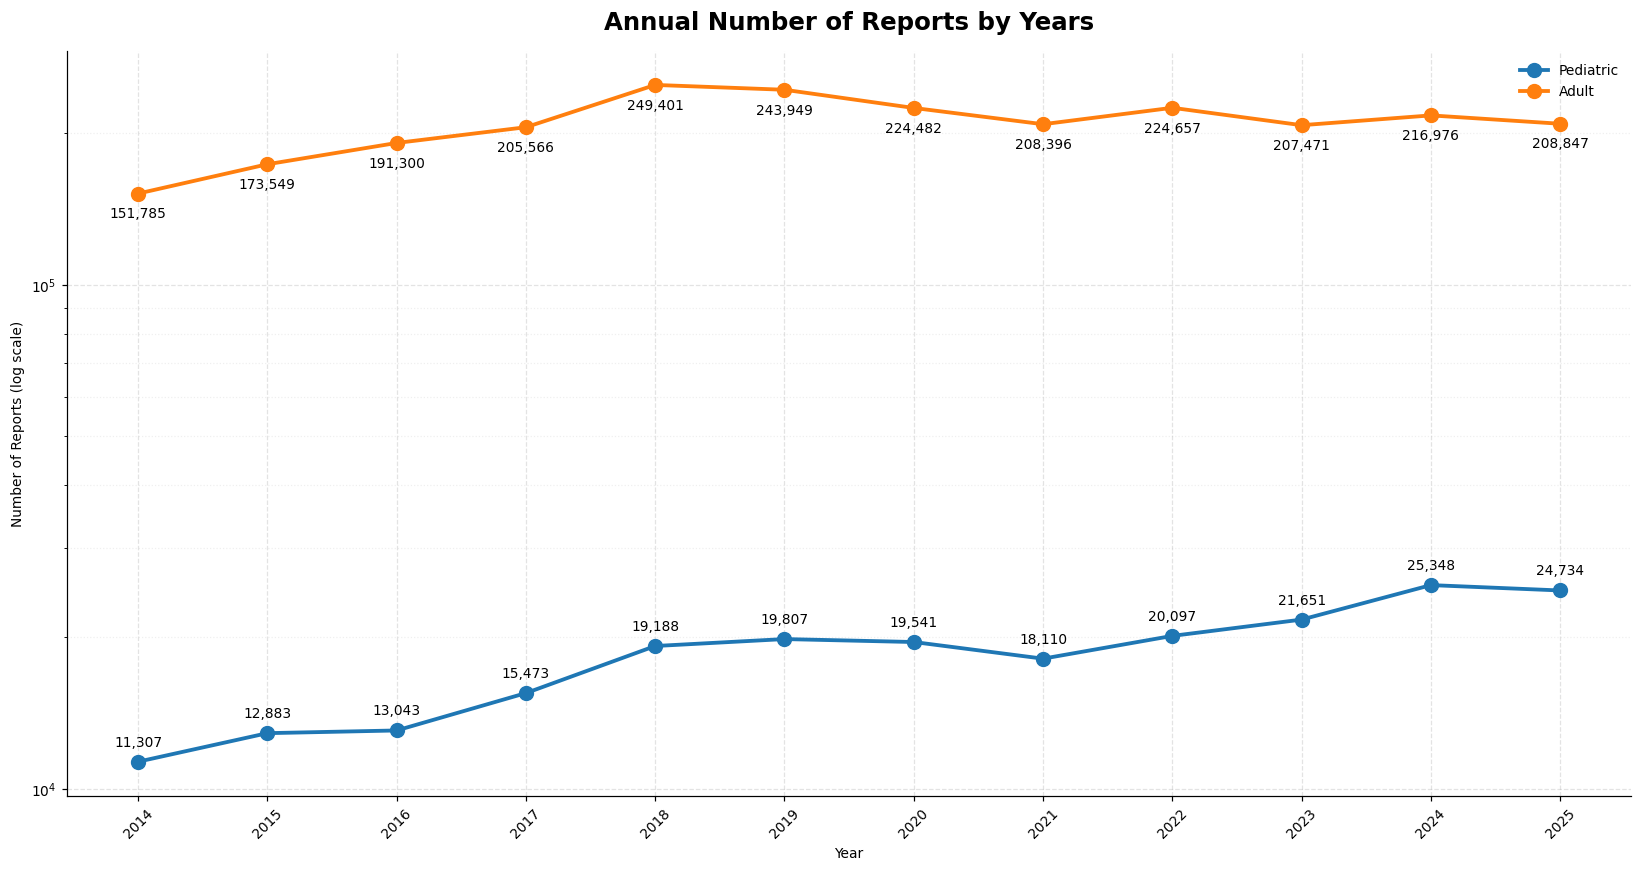

In [42]:
import pandas as pd
import matplotlib.pyplot as plt

# Only need safetyreportid + receive_date — avoid copying the full 30-col DataFrames
ped_dates = df_ped[["safetyreportid", "receive_date"]].copy()
adu_dates = df_adu[["safetyreportid", "receive_date"]].copy()

ped_dates["receive_date"] = pd.to_datetime(ped_dates["receive_date"], errors="coerce")
adu_dates["receive_date"] = pd.to_datetime(adu_dates["receive_date"], errors="coerce")
ped_dates["year"] = ped_dates["receive_date"].dt.year
adu_dates["year"] = adu_dates["receive_date"].dt.year

all_years  = sorted(set(ped_dates["year"].dropna().astype(int)) | set(adu_dates["year"].dropna().astype(int)))
year_range = list(range(min(all_years), max(all_years) + 1))

ped_yearly = (
    ped_dates.dropna(subset=["year"])
    .groupby("year")["safetyreportid"].nunique()
    .reindex(year_range, fill_value=0).reset_index()
)
ped_yearly.columns = ["year", "n_reports"]

adu_yearly = (
    adu_dates.dropna(subset=["year"])
    .groupby("year")["safetyreportid"].nunique()
    .reindex(year_range, fill_value=0).reset_index()
)
adu_yearly.columns = ["year", "n_reports"]

fig, ax = plt.subplots(figsize=(15, 8))
ax.plot(ped_yearly["year"], ped_yearly["n_reports"], marker="o", markersize=9, linewidth=2.5, label="Pediatric")
ax.plot(adu_yearly["year"], adu_yearly["n_reports"], marker="o", markersize=9, linewidth=2.5, label="Adult")
ax.set_yscale("log")

for x, y in zip(ped_yearly["year"], ped_yearly["n_reports"]):
    if y > 0:
        ax.annotate(f"{y:,}", (x, y), xytext=(0, 10), textcoords="offset points", ha="center", fontsize=9)
for x, y in zip(adu_yearly["year"], adu_yearly["n_reports"]):
    if y > 0:
        ax.annotate(f"{y:,}", (x, y), xytext=(0, -16), textcoords="offset points", ha="center", fontsize=9)

ax.set_title("Annual Number of Reports by Years", fontsize=16, weight="bold")
ax.set_xlabel("Year"); ax.set_ylabel("Number of Reports (log scale)")
ax.set_xticks(year_range); ax.set_xticklabels(year_range, rotation=45)
ax.grid(True, which="major", linestyle="--", alpha=0.35)
ax.grid(True, which="minor", linestyle=":", alpha=0.2)
ax.legend(frameon=False)
ax.spines["top"].set_visible(False); ax.spines["right"].set_visible(False)
plt.tight_layout()
plt.savefig("output/figures/reports_pediatric_vs_adult_2014_2025.png", dpi=300, bbox_inches="tight")
plt.show()


## Serious Class — การจัดกลุ่มความรุนแรง

ตรวจสอบว่ารายงานมี flag `serious` (death, hospitalization, life-threatening, ฯลฯ) หรือไม่  
และนับจำนวน unique drug–reaction pairs ในแต่ละกลุ่ม

In [43]:
df_ped['death'].value_counts()

0    843168
1    109869
Name: death, dtype: int64

### Adult — Severity Breakdown

,severity,n_reports,percent
0,Death,323534,12.908423
1,Life-threatening,143954,5.743505
2,Hospitalization,891058,35.551607
3,Disabling,52914,2.111173
4,Congenital anomaly,3281,0.130906
5,Other,1173159,46.806927
6,Non-serious,623319,24.869303


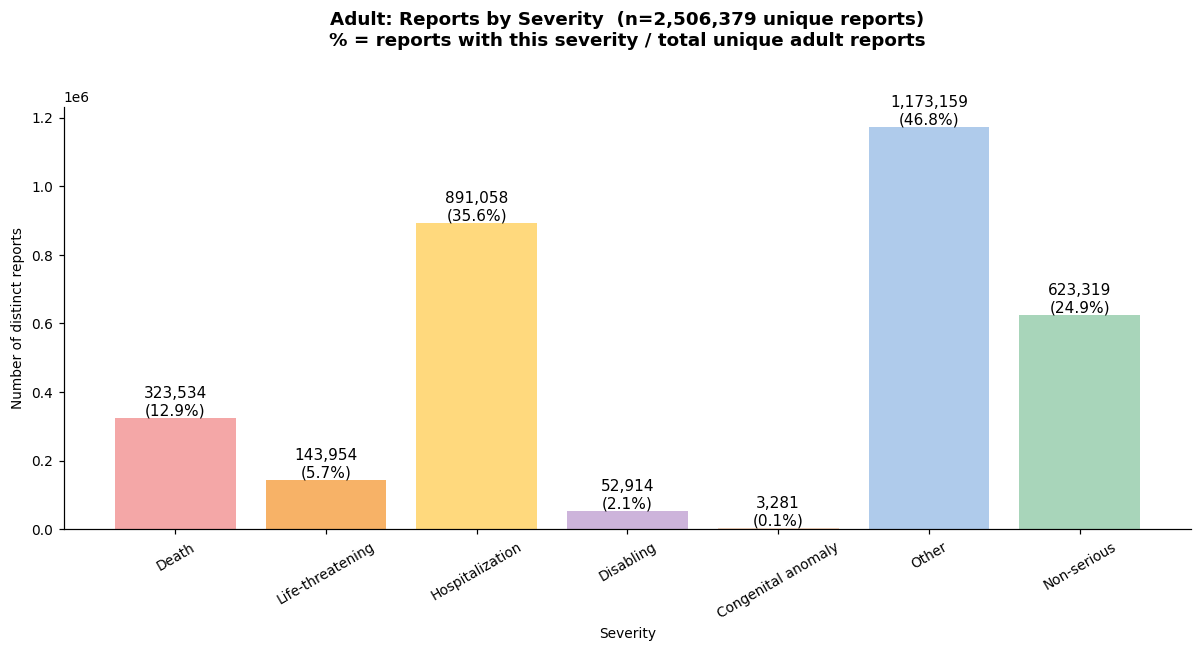

In [44]:
import pandas as pd
import matplotlib.pyplot as plt

# =========================================
# Adult: Distinct Reports by Severity
# =========================================
# Severity flags are report-level attributes — the same value appears on all rows
# of the same safetyreportid.  Dedup to 1 row per report before counting so that
# each report is counted exactly once per severity category.
# Data is guaranteed clean (no nulls, no invalid values) — no preprocessing needed.

severity_cols = [
    "congenital_anomali",
    "death",
    "disabling",
    "hospitalization",
    "life_threatening",
    "other",
]

adult_sev = df_adu[["safetyreportid", "serious"] + severity_cols].drop_duplicates("safetyreportid")
total_reports = len(adult_sev)

plot_order = [
    "death",
    "life_threatening",
    "hospitalization",
    "disabling",
    "congenital_anomali",
    "other",
    "non_serious",
]
plot_labels = [
    "Death",
    "Life-threatening",
    "Hospitalization",
    "Disabling",
    "Congenital anomaly",
    "Other",
    "Non-serious",
]
color_map = {
    "death":             "#F4A7A7",
    "life_threatening":  "#F7B267",
    "hospitalization":   "#FFD97D",
    "disabling":         "#CDB4DB",
    "congenital_anomali":"#F7D6BF",
    "other":             "#AFCBEB",
    "non_serious":       "#A8D5BA",
}

# Non-serious = serious == 0  (direct column; 6-flag approach over-counts
# ~1730 adult reports that have serious=1 but no specific flag set)
non_serious_count = int((adult_sev["serious"] == 0).sum())

adult_counts = [
    int((adult_sev[sev] == 1).sum()) if sev != "non_serious" else non_serious_count
    for sev in plot_order
]

adult_summary = pd.DataFrame({
    "severity_key": plot_order,
    "severity":     plot_labels,
    "n_reports":    adult_counts,
})
adult_summary["percent"] = adult_summary["n_reports"] / total_reports * 100

display(adult_summary[["severity", "n_reports", "percent"]])

# =========================================
# Plot
# =========================================
fig, ax = plt.subplots(figsize=(11, 6))

bars = ax.bar(
    adult_summary["severity"],
    adult_summary["n_reports"],
    color=[color_map[s] for s in adult_summary["severity_key"]],
    edgecolor="none",
)

for bar, n, pct in zip(bars, adult_summary["n_reports"], adult_summary["percent"]):
    ax.text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height(),
        f"{n:,}\n({pct:.1f}%)",
        ha="center", va="bottom", fontsize=10,
    )

ax.set_title(
    f"Adult: Reports by Severity  (n={total_reports:,} unique reports)\n"
    "% = reports with this severity / total unique adult reports",
    fontsize=12, weight="bold", pad=40,
)
ax.set_xlabel("Severity")
ax.set_ylabel("Number of distinct reports")
ax.tick_params(axis="x", rotation=30)
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)

plt.tight_layout()
plt.savefig("output/figures/adult_drug_reaction_pairs.png", dpi=300, bbox_inches="tight")
plt.show()


### Pediatric — Severity Breakdown

,severity,n_reports,percent
0,Death,15230,6.885732
1,Life-threatening,16109,7.283142
2,Hospitalization,78379,35.436428
3,Disabling,3306,1.494697
4,Congenital anomaly,2765,1.250102
5,Other,112596,50.906493
6,Non-serious,55161,24.939190


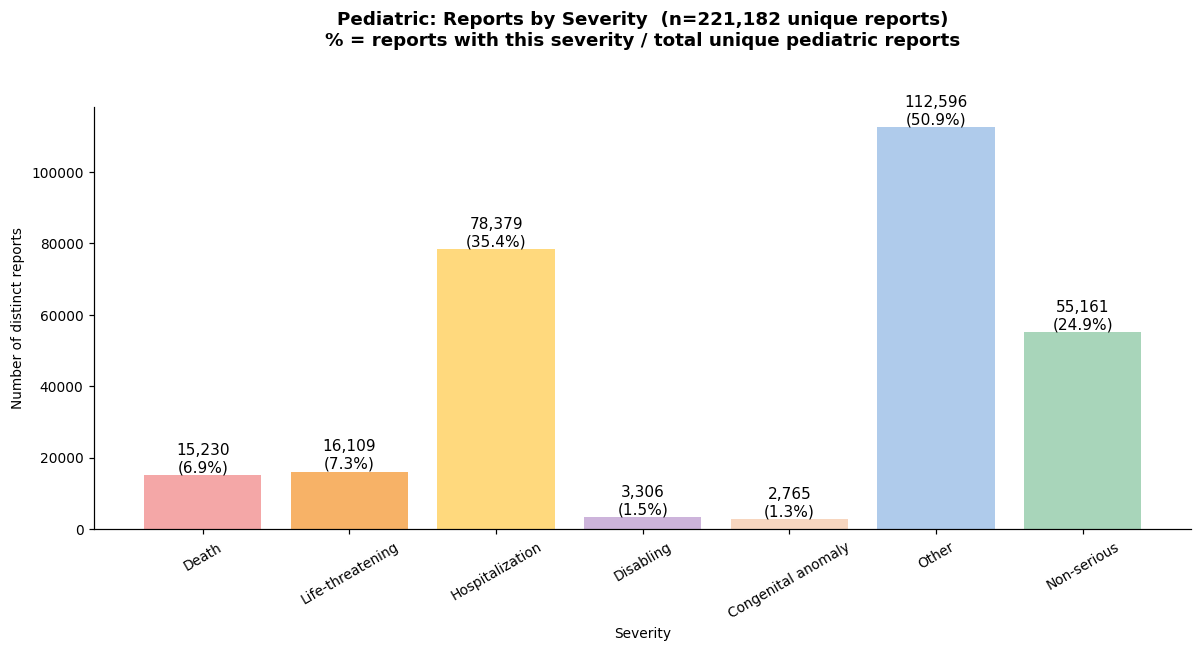

In [45]:
import pandas as pd
import matplotlib.pyplot as plt

# =========================================
# Pediatric: Distinct Reports by Severity
# =========================================
severity_cols = [
    "congenital_anomali",
    "death",
    "disabling",
    "hospitalization",
    "life_threatening",
    "other",
]

ped_sev = df_ped[["safetyreportid", "serious"] + severity_cols].drop_duplicates("safetyreportid")
total_reports = len(ped_sev)

plot_order = [
    "death",
    "life_threatening",
    "hospitalization",
    "disabling",
    "congenital_anomali",
    "other",
    "non_serious",
]
plot_labels = [
    "Death",
    "Life-threatening",
    "Hospitalization",
    "Disabling",
    "Congenital anomaly",
    "Other",
    "Non-serious",
]
color_map = {
    "death":             "#F4A7A7",
    "life_threatening":  "#F7B267",
    "hospitalization":   "#FFD97D",
    "disabling":         "#CDB4DB",
    "congenital_anomali":"#F7D6BF",
    "other":             "#AFCBEB",
    "non_serious":       "#A8D5BA",
}

# Non-serious = serious == 0  (direct column; 6-flag approach over-counts
# ~172 ped reports that have serious=1 but no specific flag set)
non_serious_count = int((ped_sev["serious"] == 0).sum())

ped_counts = [
    int((ped_sev[sev] == 1).sum()) if sev != "non_serious" else non_serious_count
    for sev in plot_order
]

ped_summary = pd.DataFrame({
    "severity_key": plot_order,
    "severity":     plot_labels,
    "n_reports":    ped_counts,
})
ped_summary["percent"] = ped_summary["n_reports"] / total_reports * 100

display(ped_summary[["severity", "n_reports", "percent"]])

# =========================================
# Plot
# =========================================
fig, ax = plt.subplots(figsize=(11, 6))

bars = ax.bar(
    ped_summary["severity"],
    ped_summary["n_reports"],
    color=[color_map[s] for s in ped_summary["severity_key"]],
    edgecolor="none",
)

for bar, n, pct in zip(bars, ped_summary["n_reports"], ped_summary["percent"]):
    ax.text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height(),
        f"{n:,}\n({pct:.1f}%)",
        ha="center", va="bottom", fontsize=10,
    )

ax.set_title(
    f"Pediatric: Reports by Severity  (n={total_reports:,} unique reports)\n"
    "% = reports with this severity / total unique pediatric reports",
    fontsize=12, weight="bold", pad=40,
)
ax.set_xlabel("Severity")
ax.set_ylabel("Number of distinct reports")
ax.tick_params(axis="x", rotation=30)
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)

plt.tight_layout()
plt.savefig("output/figures/ped_drug_reaction_pairs.png", dpi=300, bbox_inches="tight")
plt.show()



# B — Top 10 Analysis (Pediatric & Adult แยกกัน)

สามหัวข้อต่อไปนี้วิเคราะห์ **Pediatric** และ **Adult** อิสระต่อกัน  
เพื่อดูว่า term / drug / pair ใดที่มีความถี่สูงที่สุดในแต่ละกลุ่ม

> ดู **หมวด C** สำหรับ term ที่ปรากฏร่วมกันทั้งสองกลุ่ม (intersection)

# 1. Adverse Reactions — Top 10 `reaction_meddrapt`

นับ **MedDRA Preferred Term (PT)** ตามที่รายงานใน FAERS แยก Pediatric และ Adult

| วิธีนับ | Helper | คำอธิบาย |
|---------|--------|---------|
| Line counts | `top_n_lines()` | นับทุกแถว (1 report หลาย PT ได้) |
| Report counts | `top_n_reports()` | dedup `(safetyreportid, PT)` แล้วนับ ICSR |

**Label:** `reaction_meddrapt` (MedDRA PT, Title Case หลัง S09)  
**% บนกราฟ:** สัดส่วนต่อ distinct reports ทั้งหมดของ cohort (`ped_count` / `adu_count`)

In [46]:
COL_RXN = "reaction_meddrapt"

rxn_lines_ped = top_n_lines(df_ped, COL_RXN, 10)
rxn_lines_adu = top_n_lines(df_adu, COL_RXN, 10)
rxn_rep_ped = top_n_reports(df_ped, COL_RXN, 10)
rxn_rep_adu = top_n_reports(df_adu, COL_RXN, 10)

print("=== Top 10 ADVERSE REACTIONS — line counts ===")
display(rxn_lines_ped)
display(rxn_lines_adu)
print("=== Top 10 ADVERSE REACTIONS — distinct report counts ===")
display(rxn_rep_ped)
display(rxn_rep_adu)

=== Top 10 ADVERSE REACTIONS — line counts ===


,reaction_meddrapt,n_lines
0,Pyrexia,33308
1,Vomiting,31381
2,Nausea,21740
3,Seizure,18025
4,Diarrhoea,17419
5,Neutropenia,17222
6,Hypotension,16452
7,Rash,16049
8,Somnolence,15677
9,Headache,15452


,reaction_meddrapt,n_lines
0,Fatigue,470630
1,Nausea,460165
2,Pain,418498
3,Dyspnoea,409770
4,Diarrhoea,395562
5,Rash,363907
6,Headache,353784
7,Vomiting,345296
8,Pyrexia,335150
9,Arthralgia,319993


=== Top 10 ADVERSE REACTIONS — distinct report counts ===


,reaction_meddrapt,n_reports
0,Vomiting,15316
1,Pyrexia,14953
2,Rash,11193
3,Pruritus,11109
4,Nausea,11108
5,Headache,9834
6,Seizure,8656
7,Diarrhoea,7484
8,Somnolence,6954
9,Dyspnoea,6813


,reaction_meddrapt,n_reports
0,Death,181336
1,Nausea,174269
2,Fatigue,160620
3,Diarrhoea,159786
4,Dyspnoea,143851
5,Headache,124671
6,Vomiting,107504
7,Rash,107114
8,Pain,103800
9,Arthralgia,99967


## กราฟ 1.1 — ADR Frequency (Pediatric / Adult แยกกัน)

- **Barh** (แท่งแนวนอน): top 10 PT ต่อ cohort, ปลายแท่งแสดง `จำนวน (% ต่อ cohort)`
- **สี:** น้ำเงิน = Pediatric · ส้ม = Adult

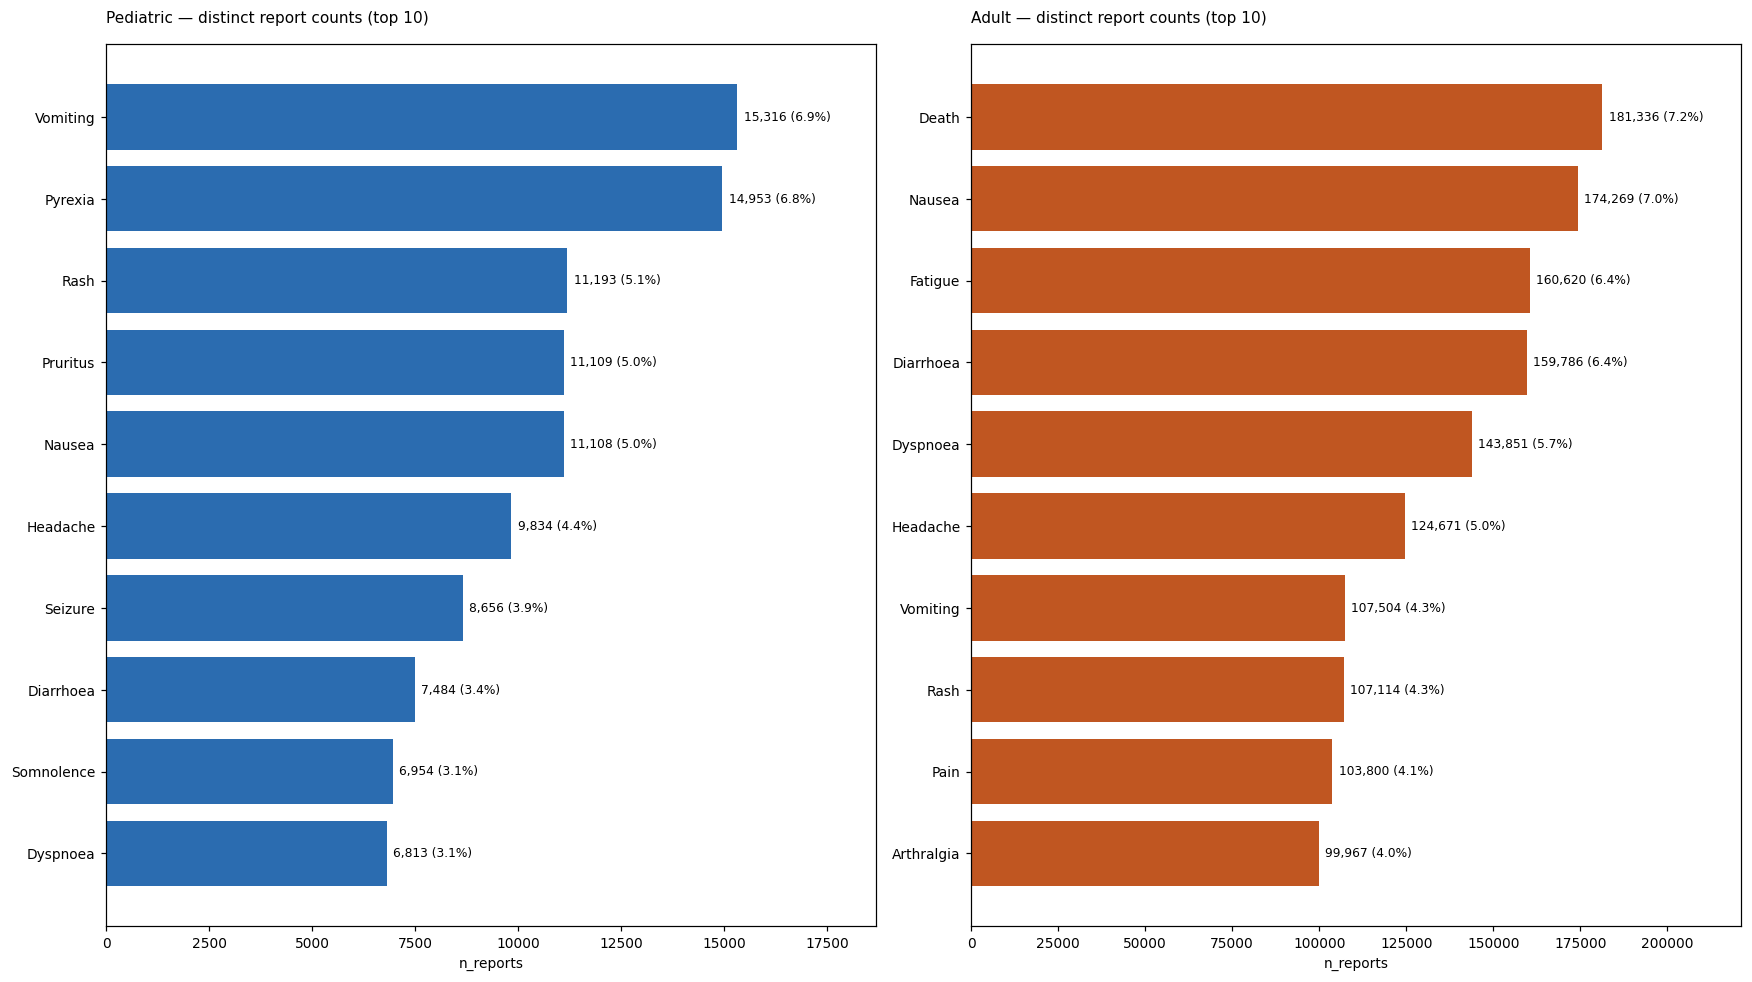

In [47]:
setup_plot_style()

fig, axes = plt.subplots(1, 2, figsize=(16, 9))
# plot_barh_topn(rxn_lines_ped, COL_RXN, "n_lines", "Pediatric — line counts (top 5)", ax=axes[0, 0])
# plot_barh_topn(rxn_lines_adu, COL_RXN, "n_lines", "Adult — line counts (top 5)", ax=axes[0, 1], color="#c05621")
plot_barh_topn(rxn_rep_ped, COL_RXN, "n_reports", "Pediatric — distinct report counts (top 10)", ax=axes[0], pct_denominator=ped_count)
plot_barh_topn(rxn_rep_adu, COL_RXN, "n_reports", "Adult — distinct report counts (top 10)", ax=axes[1], color="#c05621", pct_denominator=adu_count)
plt.tight_layout()
plt.savefig("output/figures/top10_adr_adult_ped.png", dpi=300, bbox_inches="tight")
plt.show()

# fig2, axes2 = plt.subplots(2, 2, figsize=(10, 9))
# plot_pie_topn(rxn_lines_ped, COL_RXN, "n_lines", "Pediatric — share among top-5 line counts", ax=axes2[0, 0])
# plot_pie_topn(rxn_lines_adu, COL_RXN, "n_lines", "Adult — share among top-5 line counts", ax=axes2[0, 1])
# plot_pie_topn(rxn_rep_ped, COL_RXN, "n_reports", "Pediatric — share among top-5 report counts", ax=axes2[1, 0])
# plot_pie_topn(rxn_rep_adu, COL_RXN, "n_reports", "Adult — share among top-5 report counts", ax=axes2[1, 1])
# plt.tight_layout()
# plt.show()


In [48]:
cmp_rxn_line = show_side_by_side(rxn_lines_ped, rxn_lines_adu, COL_RXN)
cmp_rxn_rep = show_side_by_side(rxn_rep_ped, rxn_rep_adu, COL_RXN)
print("Side-by-side (rank 1–5): reactions — LINE counts")
display(cmp_rxn_line)
print("Side-by-side (rank 1–5): reactions — REPORT counts")
display(cmp_rxn_rep)

Side-by-side (rank 1–5): reactions — LINE counts


,rank,Pediatric,n_lines_ped,Adult,n_lines_adu
0,1,Pyrexia,33308,Fatigue,470630
1,2,Vomiting,31381,Nausea,460165
2,3,Nausea,21740,Pain,418498
3,4,Seizure,18025,Dyspnoea,409770
4,5,Diarrhoea,17419,Diarrhoea,395562
5,6,Neutropenia,17222,Rash,363907
6,7,Hypotension,16452,Headache,353784
7,8,Rash,16049,Vomiting,345296
8,9,Somnolence,15677,Pyrexia,335150
9,10,Headache,15452,Arthralgia,319993


Side-by-side (rank 1–5): reactions — REPORT counts


,rank,Pediatric,n_reports_ped,Adult,n_reports_adu
0,1,Vomiting,15316,Death,181336
1,2,Pyrexia,14953,Nausea,174269
2,3,Rash,11193,Fatigue,160620
3,4,Pruritus,11109,Diarrhoea,159786
4,5,Nausea,11108,Dyspnoea,143851
5,6,Headache,9834,Headache,124671
6,7,Seizure,8656,Vomiting,107504
7,8,Diarrhoea,7484,Rash,107114
8,9,Somnolence,6954,Pain,103800
9,10,Dyspnoea,6813,Arthralgia,99967


## กราฟ 1.2 — เปรียบเทียบตาม Rank — ADR

- **Line chart:** count ต่อ rank (1–10); Ped = วงกลม · Adult = สี่เหลี่ยม
- *แต่ละ rank ไม่จำเป็นต้องเป็น PT เดียวกัน — ดู Section 4 สำหรับ intersection*

In [49]:
# setup_plot_style()
# fig, axes = plt.subplots(1, 2, figsize=(16, 5))
# plot_rank_vs_count(
#     cmp_rxn_line,
#     "n_lines_ped",
#     "n_lines_adu",
#     "Reactions — line counts by rank (1–5)",
#     "Count",
#     ax=axes[0],
# )
# plot_rank_vs_count(
#     cmp_rxn_rep,
#     "n_reports_ped",
#     "n_reports_adu",
#     "Reactions — distinct report counts by rank (1–5)",
#     "Count",
#     ax=axes[1],
# )
# plt.tight_layout()
# plt.show()


## กราฟ 1.3 — Severity Distribution: Vomiting & Rash (Pediatric vs Adult)

เลือก **Vomiting** และ **Rash** ซึ่งอยู่ใน top 10 ADR ของทั้งสอง cohort  
เพื่อดูว่า severity profile ของ ADR เดียวกันแตกต่างกันระหว่าง Pediatric และ Adult อย่างไร

### วิธีกราฟ

- **2 รูปแยกกัน** — รูปละ 1 ADR (Vomiting / Rash)
- **แต่ละรูปมี 2 subplots** คือ Pediatric (ซ้าย) และ Adult (ขวา)
- **แกน X** = 7 ระดับ severity, **แกน Y** = จำนวน reports
- ตัวเลขบนแต่ละแท่งแสดง **count** และ **%** ของ cohort นั้น
- แต่ละ severity bar มีสีต่างกัน:

| ระดับ | ฟิลด์ | คำอธิบาย |
|-------|-------|---------|
| Death | `death = 1` | เสียชีวิต |
| Life-threatening | `life_threatening = 1` | อาการรุนแรงเสี่ยงชีวิต |
| Hospitalization | `hospitalization = 1` | นอนโรงพยาบาล |
| Disabling | `disabling = 1` | ทุพพลภาพ |
| Congenital anomaly | `congenital_anomali = 1` | ความผิดปกติแต่กำเนิด |
| Other | `other = 1` | serious — อื่น ๆ |
| Non-serious | ไม่มี severity flag | ไม่ serious |

> **วิธีนับ:** dedup ต่อ `(safetyreportid, reaction_meddrapt)` → ใช้ priority hierarchy (Death สูงสุด) → แต่ละ report นับใน severity เดียวเท่านั้น  
> ตัวเลข % บน bar แสดงสัดส่วน severity นั้น ต่อ total reports ของ cohort-ADR นั้น

In [76]:
import pandas as pd
import numpy as np

ADR_FOCUS = ["Vomiting", "Rash"]

# Severity hierarchy: first flag that is 1 wins (Death = highest)
SEV_COLS   = ["death", "life_threatening", "hospitalization",
              "disabling", "congenital_anomali", "other"]
SEV_LABELS = ["Death", "Life-threatening", "Hospitalization",
              "Disabling", "Congenital anomaly", "Other", "Non-serious"]
SEV_COLORS = ["#252525", "#e41a1c", "#ff7f0e", "#984ea3", "#31a354", "#a65628", "#d9d9d9"]


def _sev_profile(df: pd.DataFrame, adrs: list) -> pd.DataFrame:
    """Filter rows to given ADR terms, deduplicate per (report, ADR),
    then assign each report to its highest-severity category."""
    sub = (
        df[df["reaction_meddrapt"].isin(adrs)]
        .drop_duplicates(subset=["safetyreportid", "reaction_meddrapt"])
        .copy()
    )
    # Vectorised severity assignment using priority hierarchy
    conds = [sub[c].fillna(0).astype(int) == 1 for c in SEV_COLS]
    sub["_sev"] = np.select(conds, SEV_LABELS[:-1], default="Non-serious")
    return (
        sub.groupby(["reaction_meddrapt", "_sev"], observed=True)
        .size()
        .reset_index(name="n_reports")
    )


sev_ped = _sev_profile(df_ped, ADR_FOCUS)
sev_adu = _sev_profile(df_adu, ADR_FOCUS)

print("Pediatric — severity breakdown:")
display(
    sev_ped.pivot(index="_sev", columns="reaction_meddrapt", values="n_reports")
    .reindex(SEV_LABELS).fillna(0).astype(int)
)
print("\nAdult — severity breakdown:")
display(
    sev_adu.pivot(index="_sev", columns="reaction_meddrapt", values="n_reports")
    .reindex(SEV_LABELS).fillna(0).astype(int)
)

Pediatric — severity breakdown:


reaction_meddrapt,Rash,Vomiting
_sev,,
Death,148,784
Life-threatening,401,1234
Hospitalization,1810,7058
Disabling,54,84
Congenital anomaly,11,10
Other,2466,3576
Non-serious,6303,2570



Adult — severity breakdown:


reaction_meddrapt,Rash,Vomiting
_sev,,
Death,4938,9109
Life-threatening,3643,6583
Hospitalization,20637,42599
Disabling,1578,1089
Congenital anomaly,20,16
Other,31259,26630
Non-serious,45039,21478


/tmp/ipykernel_1115303/130745232.py:73: UserWarning: Setting the 'color' property will override the edgecolor or facecolor properties.
  handles = [plt.Rectangle((0, 0), 1, 1, color=c, edgecolor="none") for c in SEV_COLORS]


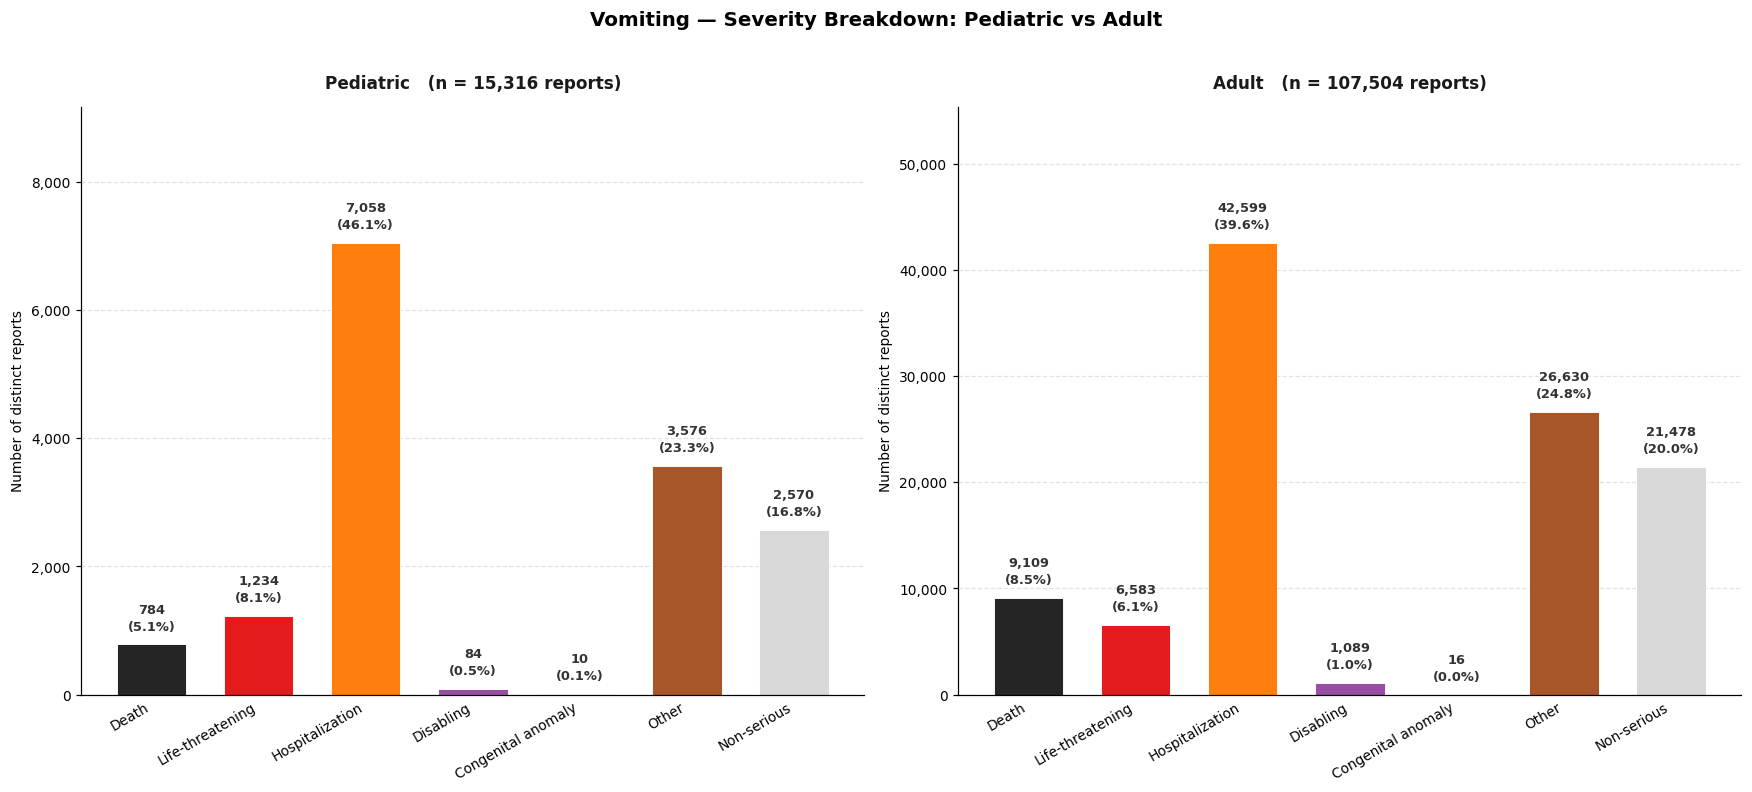

/tmp/ipykernel_1115303/130745232.py:73: UserWarning: Setting the 'color' property will override the edgecolor or facecolor properties.
  handles = [plt.Rectangle((0, 0), 1, 1, color=c, edgecolor="none") for c in SEV_COLORS]


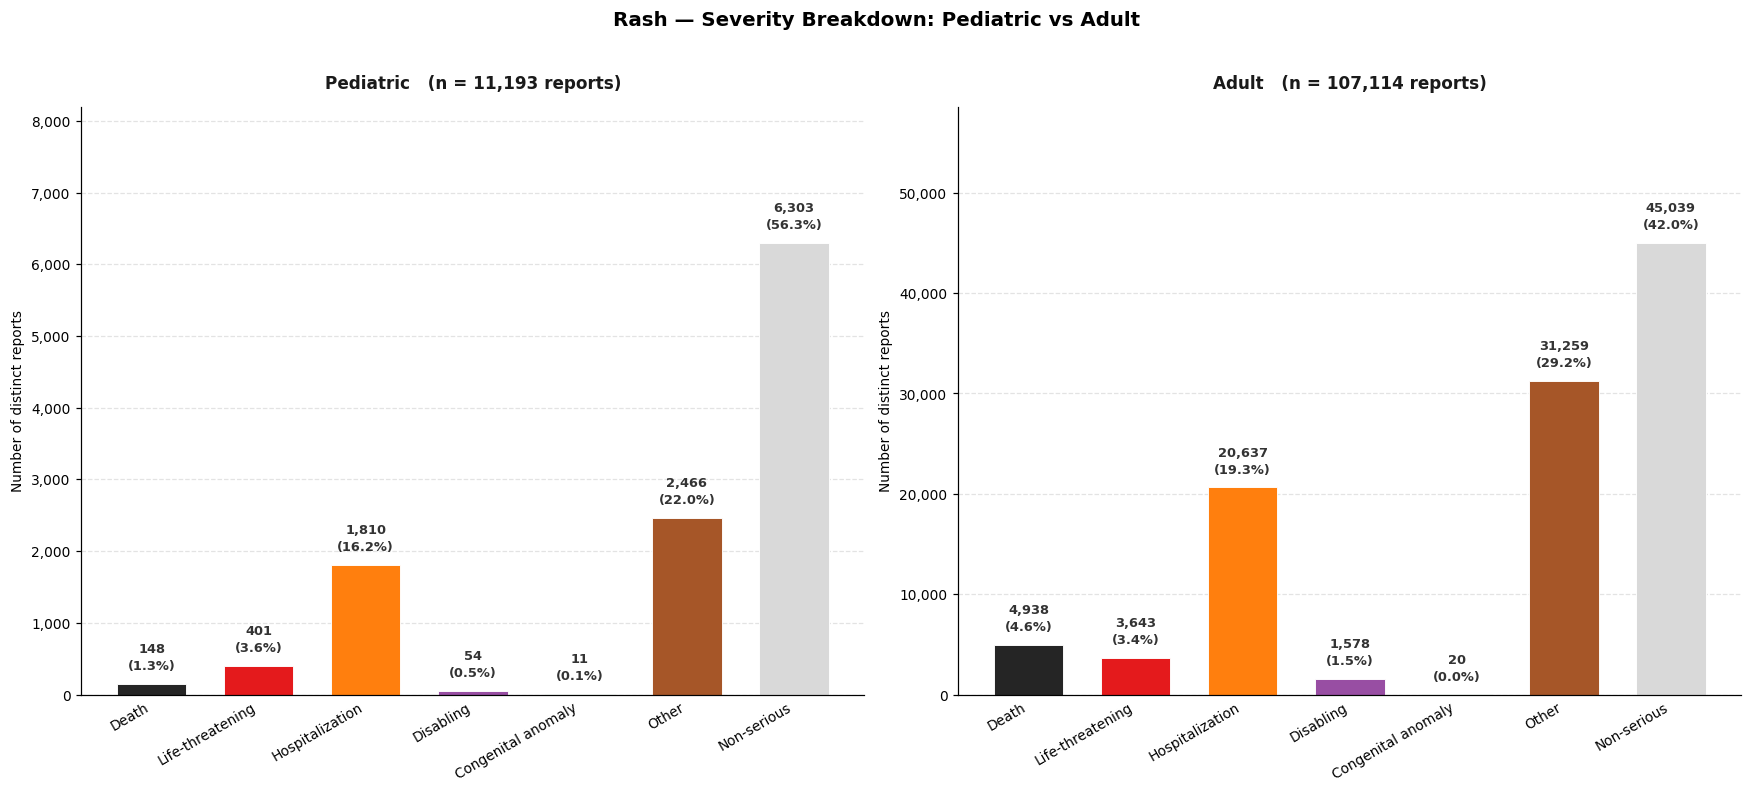

In [80]:
import matplotlib.pyplot as plt
import numpy as np
from pathlib import Path

setup_plot_style()
figures_dir = Path("../data/notebook/output/top_terms_adult/figures")
figures_dir.mkdir(parents=True, exist_ok=True)

# ── One figure per ADR ────────────────────────────────────────────────────────
for adr in ADR_FOCUS:
    ped_s = sev_ped[sev_ped["reaction_meddrapt"] == adr].set_index("_sev")["n_reports"]
    adu_s = sev_adu[sev_adu["reaction_meddrapt"] == adr].set_index("_sev")["n_reports"]

    pv = pd.Series({s: int(ped_s.get(s, 0)) for s in SEV_LABELS})
    av = pd.Series({s: int(adu_s.get(s, 0)) for s in SEV_LABELS})
    pt, at = pv.sum(), av.sum()

    fig, axes = plt.subplots(1, 2, figsize=(16, 7), sharey=False)
    fig.suptitle(
        f"{adr} — Severity Breakdown: Pediatric vs Adult",
        fontsize=13, fontweight="bold", y=1.02,
    )

    cohorts = [
        (axes[0], pv, pt, "Pediatric", "#4292C6"),
        (axes[1], av, at, "Adult",     "#E6550D"),
    ]

    for ax, vals, total, cohort_name, bar_color in cohorts:
        x = np.arange(len(SEV_LABELS))

        # Colored bars (one color per severity) with a matching border
        bars = ax.bar(
            x, vals.values,
            color=SEV_COLORS,
            edgecolor="white", linewidth=0.6,
            width=0.65,
        )

        # Count + % label above each bar
        y_max = vals.max() if vals.max() > 0 else 1
        for bar, v in zip(bars, vals.values):
            pct = 100.0 * v / total if total > 0 else 0.0
            if v > 0:
                ax.text(
                    bar.get_x() + bar.get_width() / 2,
                    bar.get_height() + y_max * 0.025,
                    f"{v:,}\n({pct:.1f}%)",
                    ha="center", va="bottom",
                    fontsize=8.5, fontweight="bold", color="#333333",
                    linespacing=1.4,
                )

        ax.set_title(
            f"{cohort_name}   (n = {total:,} reports)",
            fontsize=11, fontweight="bold", pad=12,
            color="#1a1a1a",
        )
        ax.set_xticks(x)
        ax.set_xticklabels(SEV_LABELS, rotation=30, ha="right", fontsize=9)
        ax.set_ylabel("Number of distinct reports", fontsize=9)
        ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda v, _: f"{int(v):,}"))

        # Give breathing room above tallest bar for labels
        ax.set_ylim(0, y_max * 1.30)
        ax.spines["top"].set_visible(False)
        ax.spines["right"].set_visible(False)
        ax.tick_params(axis="x", length=0)
        ax.grid(axis="y", linestyle="--", alpha=0.35, zorder=0)
        ax.set_axisbelow(True)

    # Legend: severity colour guide
    handles = [plt.Rectangle((0, 0), 1, 1, color=c, edgecolor="none") for c in SEV_COLORS]
    # fig.legend(
    #     handles, SEV_LABELS,
    #     title="Severity (highest priority per report)",
    #     loc="lower center", ncol=4,
    #     fontsize=8.5, title_fontsize=9,
    #     bbox_to_anchor=(0.5, -0.07),
    #     frameon=True, edgecolor="#cccccc",
    # )

    plt.tight_layout()
    fname = f"severity_{adr.lower().replace(' ', '_')}.png"
    plt.savefig(figures_dir / fname, dpi=150, bbox_inches="tight")
    plt.show()

## กราฟ 1.3b — Severity × NICHD Subgroup: Vomiting & Rash (Pediatric only)

เจาะลึกเฉพาะ **Pediatric cohort** — ดูว่า severity profile ของ ADR แตกต่างกันตาม **อายุกลุ่ม** อย่างไร

### NICHD Age Bands (`nichd` column)

| ค่า | อายุ | คำอธิบาย |
|-----|------|---------|
| `infancy` | 0–11 เดือน | Neonates + Infants |
| `toddler` | 1 ปี | Toddler |
| `early_childhood` | 2–5 ปี | Early Childhood |
| `middle_childhood` | 6–11 ปี | Middle Childhood |
| `early_adolescence` | 12–17 ปี | Early Adolescence |
| `late_adolescence` | 18–21 ปี | Late Adolescence |

### วิธีกราฟ

- **1 รูปต่อ 1 ADR** (Vomiting / Rash)
- **แกน X** = NICHD subgroup เรียงจากอายุน้อย → มาก
- **Stack** = 7 ระดับ severity (Death บนสุด → Non-serious ล่างสุด)
- ตัวเลข **%** บนแต่ละ segment (แสดงถ้า ≥ 5%)
- **n = X** บนสุดของแต่ละแท่งแสดง total reports ใน subgroup นั้น
- Dedup ต่อ `safetyreportid` → 1 report = 1 count

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path

# ── NICHD ordering (youngest → oldest) ───────────────────────────────────────
NICHD_ORDER  = ["infancy", "toddler", "early_childhood",
                "middle_childhood", "early_adolescence", "late_adolescence"]
NICHD_LABELS = ["Infancy\n(0–11m)", "Toddler\n(1yr)", "Early\nChildhood\n(2–5yr)",
                "Middle\nChildhood\n(6–11yr)", "Early\nAdolescence\n(12–17yr)",
                "Late\nAdolescence\n(18–21yr)"]

# Severity definition (same as section 1.3)
_SEV_COLS_NB   = ["death", "life_threatening", "hospitalization",
                  "disabling", "congenital_anomali", "other"]
_SEV_LABELS_NB = ["Death", "Life-threatening", "Hospitalization",
                  "Disabling", "Congenital anomaly", "Other", "Non-serious"]
_SEV_COLORS_NB = ["#252525", "#e41a1c", "#ff7f0e", "#984ea3",
                  "#31a354", "#a65628", "#d9d9d9"]


def _nichd_sev_pivot(df: pd.DataFrame, adr: str) -> pd.DataFrame:
    """Filter to ADR, dedup per report, assign severity, pivot to NICHD × severity."""
    sub = (
        df[df["reaction_meddrapt"] == adr]
        .drop_duplicates(subset=["safetyreportid"])
        .copy()
    )
    conds = [sub[c].fillna(0).astype(int) == 1 for c in _SEV_COLS_NB]
    sub["_sev"] = np.select(conds, _SEV_LABELS_NB[:-1], default="Non-serious")

    pivot = (
        sub.groupby(["nichd", "_sev"], observed=True)
        .size()
        .unstack(fill_value=0)
        .reindex(index=NICHD_ORDER, columns=_SEV_LABELS_NB, fill_value=0)
    )
    return pivot


# ── Plot: one figure per ADR ──────────────────────────────────────────────────
setup_plot_style()
figures_dir = Path("../data/notebook/output/top_terms_adult/figures")
figures_dir.mkdir(parents=True, exist_ok=True)

for adr in ADR_FOCUS:   # ADR_FOCUS = ["Vomiting", "Rash"] defined in cell 23
    pivot = _nichd_sev_pivot(df_ped, adr)
    totals = pivot.sum(axis=1).values   # total reports per NICHD subgroup

    fig, ax = plt.subplots(figsize=(13, 7))
    fig.suptitle(
        f"กราฟ 1.3b  {adr} — Severity by NICHD Subgroup  (Pediatric only)",
        fontsize=12, fontweight="bold", y=1.01,
    )

    x   = np.arange(len(NICHD_ORDER))
    bot = np.zeros(len(NICHD_ORDER))

    for sev, color in zip(_SEV_LABELS_NB, _SEV_COLORS_NB):
        vals = pivot[sev].values.astype(float)

        ax.bar(
            x, vals, bottom=bot,
            color=color, edgecolor="white", linewidth=0.5,
            width=0.65, label=sev,
        )

        # % label inside segment (show if >= 5%)
        for xi, (v, b, tot) in enumerate(zip(vals, bot, totals)):
            pct = 100.0 * v / tot if tot > 0 else 0.0
            if pct >= 5 and v > 0:
                ax.text(
                    xi, b + v / 2,
                    f"{pct:.0f}%",
                    ha="center", va="center",
                    fontsize=7.5, fontweight="bold", color="white",
                )

        bot += vals

    # Total-count label on top of each stacked bar
    bar_top = bot   # bot now = total height after all segments
    ymax = float(bar_top.max()) if bar_top.max() > 0 else 1.0
    for xi, (total, top) in enumerate(zip(totals, bar_top)):
        if total > 0:
            ax.text(
                xi, top + ymax * 0.02,
                f"n={int(total):,}",
                ha="center", va="bottom",
                fontsize=8.5, fontweight="bold", color="#222222",
            )

    ax.set_xticks(x)
    ax.set_xticklabels(NICHD_LABELS, fontsize=9)
    ax.set_ylabel("Number of distinct reports", fontsize=9)
    ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda v, _: f"{int(v):,}"))
    ax.set_ylim(0, ymax * 1.18)
    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)
    ax.tick_params(axis="x", length=0)
    ax.grid(axis="y", linestyle="--", alpha=0.35, zorder=0)
    ax.set_axisbelow(True)

    # Legend (severity colours)
    handles = [plt.Rectangle((0, 0), 1, 1, color=c, edgecolor="none") for c in _SEV_COLORS_NB]
    ax.legend(
        handles, _SEV_LABELS_NB,
        title="Severity (highest priority per report)",
        loc="upper right", ncol=1,
        fontsize=8, title_fontsize=8.5,
        frameon=True, edgecolor="#cccccc",
    )

    plt.tight_layout()
    fname = f"severity_nichd_{adr.lower()}.png"
    plt.savefig(figures_dir / fname, dpi=150, bbox_inches="tight")
    plt.show()
    print(f"Saved → {figures_dir / fname}")

# 2. Drug only — Top 10 by `rxcui`

นับ **`rxcui`** (RxNorm Concept Unique Identifier) โดยไม่แยกตาม ADR  
แยก Pediatric และ Adult อิสระต่อกัน

| วิธีนับ | Helper | คำอธิบาย |
|---------|--------|---------|
| Line counts | `top_n_lines_rxcui_only()` | นับทุกแถวที่มี rxcui นั้น |
| Report counts | `top_n_reports_rxcui_only()` | dedup `(safetyreportid, rxcui)` แล้วนับ |

**Label:** `FAERS_medicinal_product(RxNorm_ingredient)` ต่อ rxcui (ดึงจากแต่ละ cohort)

In [50]:
N_TOP_DRUG = 10

drug_lines_ped = top_n_lines_rxcui_only(df_ped, n=N_TOP_DRUG)
drug_lines_adu = top_n_lines_rxcui_only(df_adu, n=N_TOP_DRUG)
drug_rep_ped = top_n_reports_rxcui_only(df_ped, n=N_TOP_DRUG)
drug_rep_adu = top_n_reports_rxcui_only(df_adu, n=N_TOP_DRUG)

# print("=== Top 10 DRUGS (rxcui) — line counts ===")
# display(drug_lines_ped)
# display(drug_lines_adu)
print("=== Top 10 DRUGS (rxcui) — distinct report counts ===")
display(drug_rep_ped)
display(drug_rep_adu)


=== Top 10 DRUGS (rxcui) — distinct report counts ===


,rxcui,n_reports,pair_label,display_label
1174,1876402,23703,1876402,DUPIXENT(dupilumab)
3847,6851,11846,6851,METHOTREXATE.(methotrexate)
216,11202,8235,11202,VINCRISTINE(vincristine)
2793,3002,8008,3002,CYCLOPHOSPHAMIDE(cyclophosphamide; cyclophosph...
961,161,7162,161,ACETAMINOPHEN(acetaminophen; acetaminophen / a...
2811,3041,5756,3041,CYTARABINE.(cytarabine; cytarabine / daunorubi...
3305,4179,5227,4179,ETOPOSIDE.(etoposide)
3548,5640,5158,5640,IBUPROFEN.(acetaminophen / ibuprofen; caffeine...
4335,8640,4708,8640,PREDNISONE.(chloramphenicol / prednisone; piro...
2891,3264,4644,3264,DEXAMETHASONE.(astemizole / dexamethasone; car...


,rxcui,n_reports,pair_label,display_label
3050,216891,101575,216891,ENBREL(etanercept)
2106,1876402,94741,1876402,DUPIXENT(dupilumab)
5384,337535,84944,337535,REVLIMID(lenalidomide)
6885,6851,67089,6851,METHOTREXATE(methotrexate)
7649,8640,47669,8640,PREDNISONE(chloramphenicol / prednisone; pirox...
5507,353484,47636,353484,HUMIRA(adalimumab)
863,1357542,46423,1357542,XELJANZ(tofacitinib)
465,121191,44553,121191,RITUXIMAB(hyaluronidase / rituximab; rituximab)
1358,1492733,41038,1492733,OTEZLA(apremilast)
1738,161,38014,161,ACETAMINOPHEN(acetaminophen; acetaminophen / a...


## กราฟ 2.1 — Drug Frequency (Pediatric / Adult แยกกัน)

- **Barh:** top 10 drug ต่อ cohort; label = `FAERS_name(RxNorm_ingredient)`
- ปลายแท่งแสดง `จำนวน (% ต่อ cohort)`

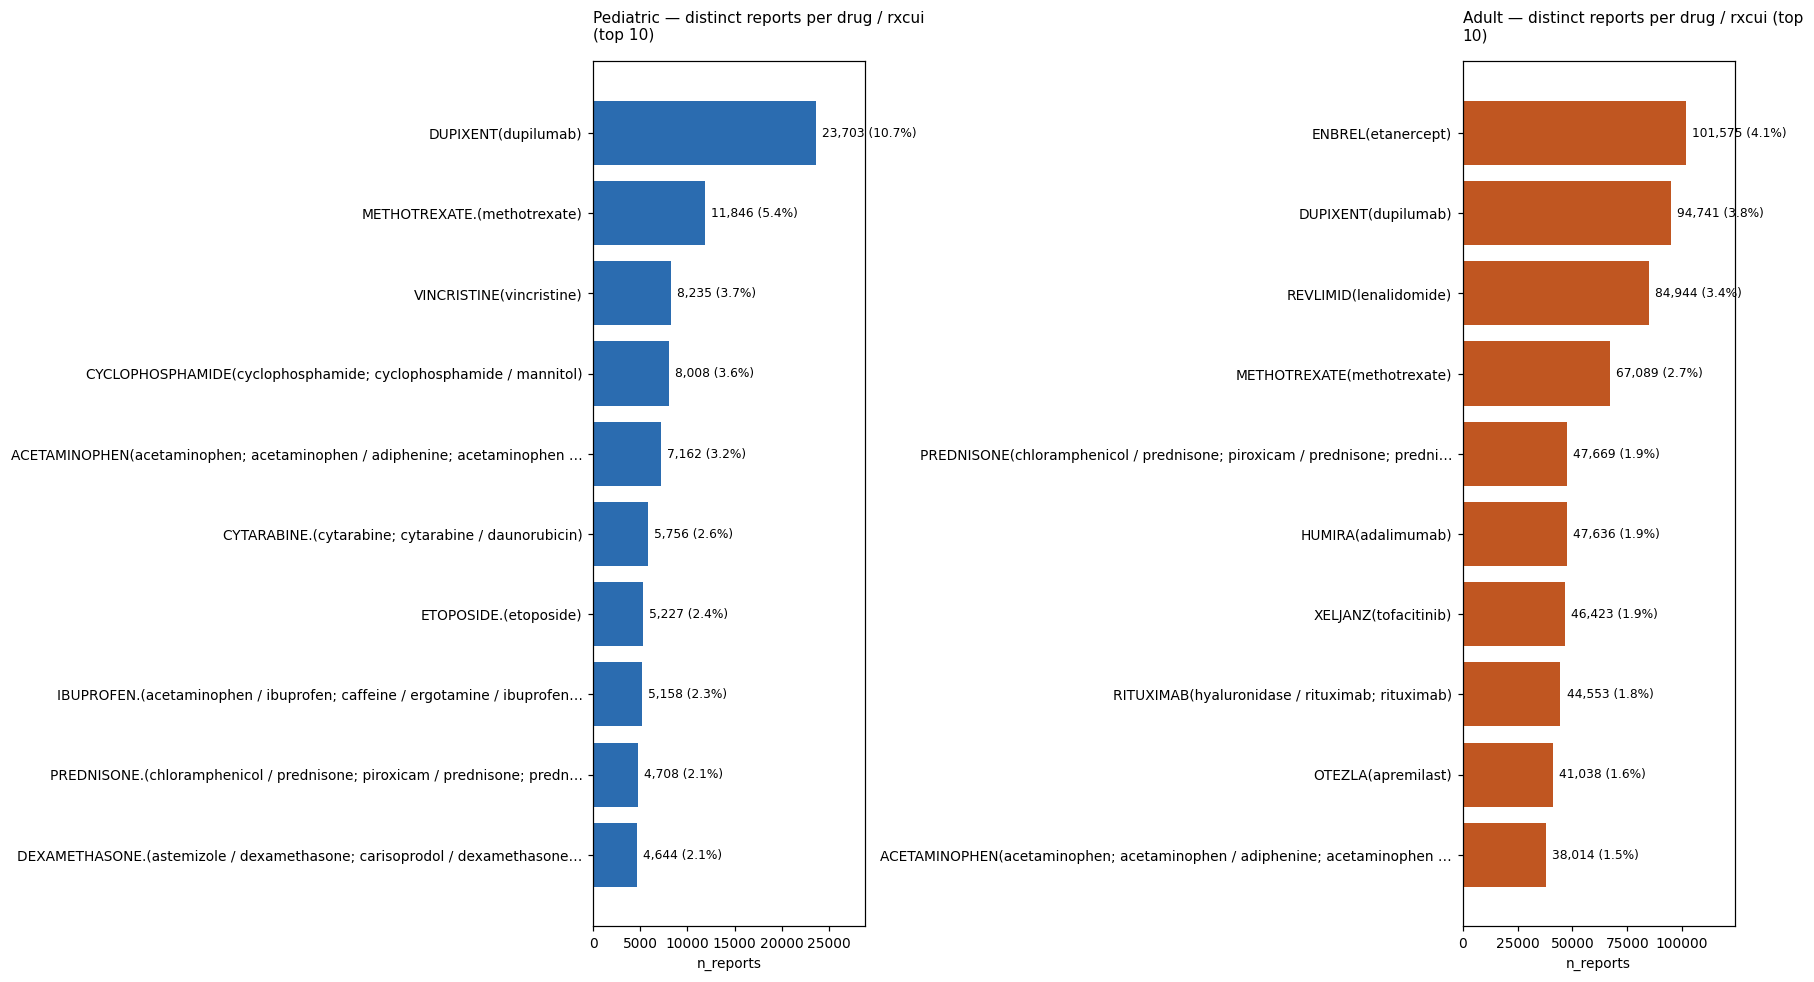

In [ ]:
setup_plot_style()

fig, axes = plt.subplots(1, 2, figsize=(16, 9))
_pl_drug = lambda d: d.assign(
    _plot_lbl=d["display_label"].map(lambda s: shorten_label(s, 72))
)
plot_barh_topn(
    _pl_drug(drug_rep_ped), "_plot_lbl", "n_reports", "Pediatric — distinct reports per drug / rxcui (top 10)", ax=axes[0], pct_denominator=ped_count
)
plot_barh_topn(
    _pl_drug(drug_rep_adu), "_plot_lbl", "n_reports", "Adult — distinct reports per drug / rxcui (top 10)", ax=axes[1], color="#c05621", pct_denominator=adu_count
)
plt.tight_layout()
plt.savefig("output/figures/top10_drugs_adult_ped.png", dpi=300, bbox_inches="tight")
plt.show()


In [52]:
# cmp_drug_line = show_side_by_side(
#     drug_lines_ped[["display_label", "n_lines"]],
#     drug_lines_adu[["display_label", "n_lines"]],
#     "display_label",
#     count_col="n_lines",
# )
# cmp_drug_rep = show_side_by_side(
#     drug_rep_ped[["display_label", "n_reports"]],
#     drug_rep_adu[["display_label", "n_reports"]],
#     "display_label",
#     count_col="n_reports",
# )
# print("Side-by-side (rank 1–10): drugs (rxcui) — LINE counts")
# display(cmp_drug_line)
# print("Side-by-side (rank 1–10): drugs (rxcui) — REPORT counts")
# display(cmp_drug_rep)


## กราฟ 2.2 — เปรียบเทียบตาม Rank — Drug

- *แต่ละ rank อาจเป็นยาคนละตัวในสองกลุ่ม — ดู Section 5 สำหรับ intersection*

In [ ]:
# setup_plot_style()
# fig, axes = plt.subplots(1, 2, figsize=(16, 5))
# plot_rank_vs_count(
#     cmp_drug_line,
#     "n_lines_ped",
#     "n_lines_adu",
#     "Drugs (rxcui) — line counts by rank (1–10)",
#     "Count",
#     ax=axes[0],
#     rank_xlabel="Rank (1–10)",
# )
# plot_rank_vs_count(
#     cmp_drug_rep,
#     "n_reports_ped",
#     "n_reports_adu",
#     "Drugs (rxcui) — distinct report counts by rank (1–10)",
#     "Count",
#     ax=axes[1],
#     rank_xlabel="Rank (1–10)",
# )
# plt.tight_layout()
# plt.show()


# 3. Drug–ADR Pairs — Top 10 `(rxcui, reaction_meddrapt)`

นับ **คู่ยา–ปฏิกิริยา** หลัง dedup `(safetyreportid, rxcui, reaction_meddrapt)` ต่อ report  
แยก Pediatric และ Adult อิสระต่อกัน

| วิธีนับ | Helper | คำอธิบาย |
|---------|--------|---------|
| Lines (deduped) | `top_n_lines_rxcui_reaction()` | unique reports per pair ≈ distinct ICSR ต่อ pair |
| Report counts | `top_n_reports_rxcui_reaction()` | เหมือน line counts หลัง dedup |

**Label:** `FAERS_name(RxNorm_ingredient) — reaction_meddrapt`

In [ ]:
N_TOP_RX_PT = 10
N_TOP_PRODUCT_NAMES = 10

mp_lines_ped = top_n_lines_rxcui_reaction(
    df_ped, n=N_TOP_RX_PT, product_k=N_TOP_PRODUCT_NAMES
)
mp_lines_adu = top_n_lines_rxcui_reaction(
    df_adu, n=N_TOP_RX_PT, product_k=N_TOP_PRODUCT_NAMES
)
mp_rep_ped = top_n_reports_rxcui_reaction(
    df_ped, n=N_TOP_RX_PT, product_k=N_TOP_PRODUCT_NAMES
)
mp_rep_adu = top_n_reports_rxcui_reaction(
    df_adu, n=N_TOP_RX_PT, product_k=N_TOP_PRODUCT_NAMES
)

# print("=== Top 10 (rxcui × PT) — counts after report dedup (same as distinct reports per pair) ===")
# display(mp_lines_ped)
# display(mp_lines_adu)
print("=== Top 10 (rxcui × PT) — distinct report counts ===")
display(mp_rep_ped)
display(mp_rep_adu)


=== Top 10 (rxcui × PT) — distinct report counts ===


,rxcui,reaction_meddrapt,n_reports,pair_label,medicinal_product_top10,display_label
38090,1876402,Pruritus,7205,1876402 | Pruritus,1. DUPIXENT (7205),DUPIXENT(dupilumab) - Pruritus
37866,1876402,Eczema,5150,1876402 | Eczema,1. DUPIXENT (5150),DUPIXENT(dupilumab) - Eczema
38098,1876402,Rash,4499,1876402 | Rash,1. DUPIXENT (4499),DUPIXENT(dupilumab) - Rash
37885,1876402,Erythema,2192,1876402 | Erythema,1. DUPIXENT (2192),DUPIXENT(dupilumab) - Erythema
31797,161,Vomiting,1994,161 | Vomiting,1. ACETAMINOPHEN (903)\n2. PARACETAMOL (629)\n...,ACETAMINOPHEN(acetaminophen; acetaminophen / a...
126577,6851,Pyrexia,1311,6851 | Pyrexia,1. METHOTREXATE. (553)\n2. METHOTREXATE (487)\...,METHOTREXATE.(methotrexate) - Pyrexia
37783,1876402,Asthma,1213,1876402 | Asthma,1. DUPIXENT (1213),DUPIXENT(dupilumab) - Asthma
112986,56466,Paraesthesia,1144,56466 | Paraesthesia,1. ANTICOAGULANT SODIUM CITRATE (1144),ANTICOAGULANT SODIUM CITRATE(ammonium chloride...
7954,11202,Neutropenia,1037,11202 | Neutropenia,1. VINCRISTINE (641)\n2. VINCRISTINE SULFATE. ...,VINCRISTINE(vincristine) - Neutropenia
9512,114477,Seizure,1025,114477 | Seizure,1. LEVETIRACETAM. (555)\n2. LEVETIRACETAM (420...,LEVETIRACETAM.(levetiracetam) - Seizure


,rxcui,reaction_meddrapt,n_reports,pair_label,medicinal_product_top10,display_label
181685,1876402,Pruritus,24341,1876402 | Pruritus,1. DUPIXENT (24341),DUPIXENT(dupilumab) - Pruritus
260003,216891,Arthralgia,16284,216891 | Arthralgia,1. ENBREL (16282)\n2. ENBREL 50 MG/ML PFS (1)\...,ENBREL(etanercept) - Arthralgia
260568,216891,Pain,16158,216891 | Pain,1. ENBREL (16158),ENBREL(etanercept) - Pain
181702,1876402,Rash,13420,1876402 | Rash,1. DUPIXENT (13420),DUPIXENT(dupilumab) - Rash
349756,2626,Neutropenia,12910,2626 | Neutropenia,1. CLOZAPINE (9944)\n2. CLOZAPINE. (1981)\n3. ...,CLOZAPINE(clozapine) - Neutropenia
105400,1492733,Diarrhoea,11840,1492733 | Diarrhoea,1. OTEZLA (11840),OTEZLA(apremilast) - Diarrhoea
519105,616011,Arthralgia,10866,616011 | Arthralgia,1. ORENCIA (10865)\n2. ORENCIA FOR INJ 250 MG/...,ORENCIA(abatacept) - Arthralgia
260218,216891,Fatigue,10561,216891 | Fatigue,1. ENBREL (10561),ENBREL(etanercept) - Fatigue
545407,6851,Pain,10455,6851 | Pain,1. METHOTREXATE (5296)\n2. METHOTREXATE. (3408...,METHOTREXATE(methotrexate) - Pain
105644,1492733,Nausea,10440,1492733 | Nausea,1. OTEZLA (10440),OTEZLA(apremilast) - Nausea


## กราฟ 3.1 — Drug–ADR Pair Frequency (Pediatric / Adult แยกกัน)

- **Barh:** top 10 pairs ต่อ cohort; label = `FAERS_name(RxNorm) — PT`
- ปลายแท่งแสดง `จำนวน (% ต่อ cohort)`

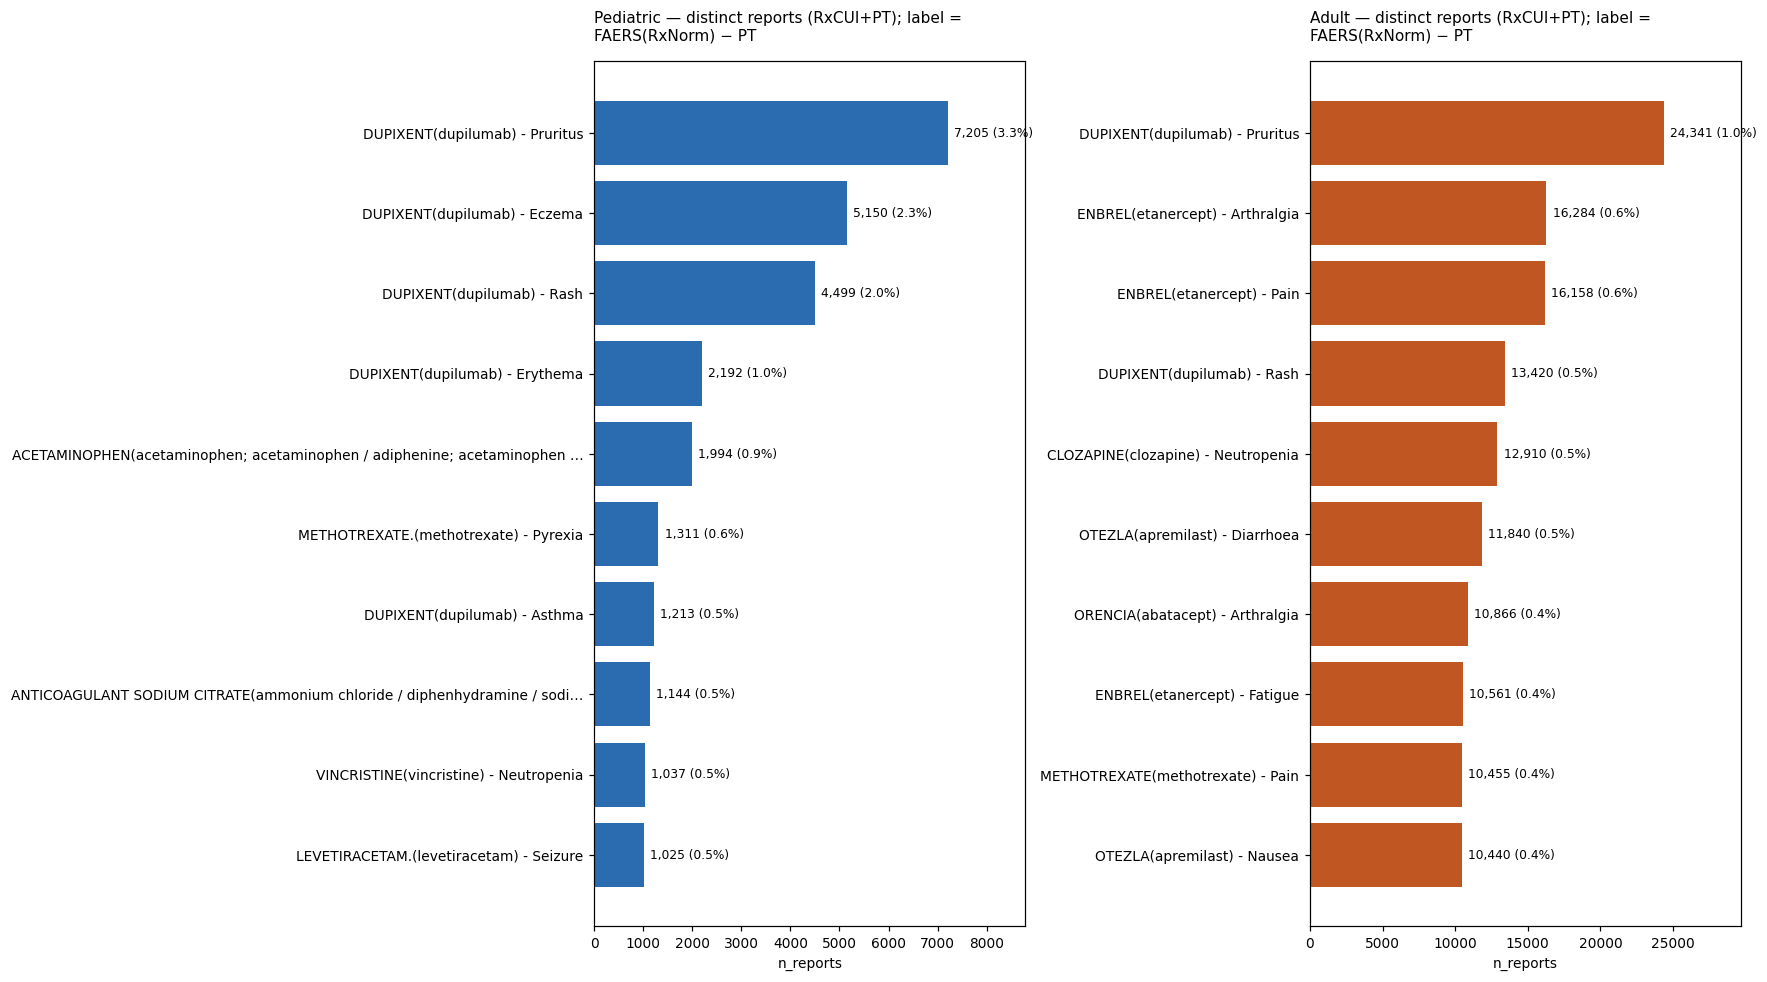

In [55]:
setup_plot_style()

fig, axes = plt.subplots(1, 2, figsize=(16, 9))
_pl = lambda d: d.assign(
        _plot_lbl=d["display_label"].map(lambda s: shorten_label(s, 72))
    )
plot_barh_topn(
    _pl(mp_rep_ped), "_plot_lbl", "n_reports", "Pediatric — distinct reports (RxCUI+PT); label = FAERS(RxNorm) − PT", ax=axes[0], pct_denominator=ped_count
)
plot_barh_topn(
    _pl(mp_rep_adu), "_plot_lbl", "n_reports", "Adult — distinct reports (RxCUI+PT); label = FAERS(RxNorm) − PT", ax=axes[1], color="#c05621", pct_denominator=adu_count
)
plt.tight_layout()
plt.savefig("output/figures/top10_drug_adr_pairs_adult_ped.png", dpi=300, bbox_inches="tight")
plt.show()




In [ ]:
# cmp_mp_line = show_side_by_side(
#     mp_lines_ped[["display_label", "n_lines"]],
#     mp_lines_adu[["display_label", "n_lines"]],
#     "display_label",
#     count_col="n_lines",
# )
# cmp_mp_rep = show_side_by_side(
#     mp_rep_ped[["display_label", "n_reports"]],
#     mp_rep_adu[["display_label", "n_reports"]],
#     "display_label",
#     count_col="n_reports",
# )
# print("Side-by-side (rank 1–10): FAERS(RxNorm) − PT — LINE counts (report-dedup per RxCUI+PT)")
# display(cmp_mp_line)
# print("Side-by-side (rank 1–10): FAERS(RxNorm) − PT — REPORT counts (RxCUI+PT)")
# display(cmp_mp_rep)


## กราฟ 3.2 — เปรียบเทียบตาม Rank — Drug–ADR Pairs

- *ดู Section 6 สำหรับ pair ที่พบร่วมกันทั้งสองกลุ่ม*

In [ ]:
# setup_plot_style()
# fig, axes = plt.subplots(1, 2, figsize=(16, 5))
# plot_rank_vs_count(
#     cmp_mp_line,
#     "n_lines_ped",
#     "n_lines_adu",
#     "RxCUI+PT — report-dedup counts by rank (1–10); rows = FAERS(RxNorm) − PT",
#     "Count",
#     ax=axes[0],
#     rank_xlabel="Rank (1–10)",
# )
# plot_rank_vs_count(
#     cmp_mp_rep,
#     "n_reports_ped",
#     "n_reports_adu",
#     "RxCUI+PT — distinct reports by rank (1–10); rows = FAERS(RxNorm) − PT",
#     "Count",
#     ax=axes[1],
#     rank_xlabel="Rank (1–10)",
# )
# plt.tight_layout()
# plt.show()


## กราฟ 3.3 — Severity Distribution: DUPIXENT (dupilumab) — Rash (Pediatric vs Adult)

เปรียบเทียบ severity breakdown ของคู่ **DUPIXENT × Rash** ระหว่าง Pediatric และ Adult  
Dupixent (dupilumab) เป็นยากลุ่ม biologic ที่ใช้รักษา atopic dermatitis และ asthma  
"Rash" เป็น ADR ที่พบบ่อยใน FAERS สำหรับยานี้ทั้งในเด็กและผู้ใหญ่

### วิธีกราฟ

- **1 รูป** มี 2 subplots: **Pediatric (ซ้าย)** | **Adult (ขวา)**
- ค้นหาจาก `medicinal_product` ที่ขึ้นต้นด้วย `"DUPIXENT"` (case-insensitive) + `reaction_meddrapt = "Rash"`
- **แกน X** = 7 ระดับ severity, **แกน Y** = จำนวน distinct reports
- ตัวเลขบนแต่ละแท่งแสดง count และ %
- Dedup ต่อ `safetyreportid` → 1 report = 1 count → severity ใช้ priority hierarchy (Death = สูงสุด)

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path

# ── Config ────────────────────────────────────────────────────────────────────
DUPIXENT_PRODUCT  = "DUPIXENT"   # prefix to match medicinal_product (case-insensitive)
DUPIXENT_REACTION = "Rash"       # reaction_meddrapt

_SEV_COLS   = ["death", "life_threatening", "hospitalization",
               "disabling", "congenital_anomali", "other"]
_SEV_LABELS = ["Death", "Life-threatening", "Hospitalization",
               "Disabling", "Congenital anomaly", "Other", "Non-serious"]
_SEV_COLORS = ["#252525", "#e41a1c", "#ff7f0e", "#984ea3",
               "#31a354", "#a65628", "#d9d9d9"]


# ── Helper: severity counts filtered by product prefix × reaction ─────────────
def _dupixent_sev_counts(df: pd.DataFrame, product_prefix: str, reaction: str):
    """Filter by medicinal_product prefix + reaction; dedup per report; assign severity."""
    mask = (
        df["medicinal_product"].str.upper().str.startswith(product_prefix.upper(), na=False)
        & (df["reaction_meddrapt"] == reaction)
    )
    sub = df[mask].drop_duplicates(subset=["safetyreportid"]).copy()
    if sub.empty:
        return pd.Series(0, index=_SEV_LABELS), 0
    conds = [sub[c].fillna(0).astype(int) == 1 for c in _SEV_COLS]
    sub["_sev"] = np.select(conds, _SEV_LABELS[:-1], default="Non-serious")
    counts = sub["_sev"].value_counts().reindex(_SEV_LABELS, fill_value=0)
    return counts, len(sub)


# ── Compute ───────────────────────────────────────────────────────────────────
ped_sev, ped_n = _dupixent_sev_counts(df_ped, DUPIXENT_PRODUCT, DUPIXENT_REACTION)
adu_sev, adu_n = _dupixent_sev_counts(df_adu, DUPIXENT_PRODUCT, DUPIXENT_REACTION)

pair_title = f"DUPIXENT (dupilumab) — {DUPIXENT_REACTION}"
print(f"Pair:  {pair_title}")
print(f"  Pediatric reports: {ped_n:,}")
print(f"  Adult reports:     {adu_n:,}")
display(
    pd.DataFrame({"Pediatric": ped_sev, "Adult": adu_sev})
    .assign(
        **{"Ped %": lambda d: (100 * d["Pediatric"] / ped_n).round(1) if ped_n else 0,
           "Adult %": lambda d: (100 * d["Adult"] / adu_n).round(1) if adu_n else 0}
    )
)


# ── Plot ──────────────────────────────────────────────────────────────────────
setup_plot_style()
figures_dir = Path("../data/notebook/output/top_terms_adult/figures")
figures_dir.mkdir(parents=True, exist_ok=True)

fig, axes = plt.subplots(1, 2, figsize=(16, 7), sharey=False)
fig.suptitle(
    f"กราฟ 3.3  Drug–ADR Pair:  {pair_title}\n"
    "Severity Breakdown — Pediatric vs Adult",
    fontsize=11, fontweight="bold", y=1.03,
)

for ax, vals, total, cohort_name in [
    (axes[0], ped_sev, ped_n, "Pediatric"),
    (axes[1], adu_sev, adu_n, "Adult"),
]:
    x    = np.arange(len(_SEV_LABELS))
    ymax = int(vals.max()) if vals.max() > 0 else 1

    bars = ax.bar(
        x, vals.values,
        color=_SEV_COLORS, edgecolor="white", linewidth=0.6, width=0.65,
    )

    for bar, v in zip(bars, vals.values):
        pct = 100.0 * v / total if total > 0 else 0.0
        if v > 0:
            ax.text(
                bar.get_x() + bar.get_width() / 2,
                bar.get_height() + ymax * 0.025,
                f"{int(v):,}\n({pct:.1f}%)",
                ha="center", va="bottom",
                fontsize=8.5, fontweight="bold",
                color="#333333", linespacing=1.4,
            )

    ax.set_title(f"{cohort_name}   (n = {total:,} reports)", fontsize=11, fontweight="bold", pad=12)
    ax.set_xticks(x)
    ax.set_xticklabels(_SEV_LABELS, rotation=30, ha="right", fontsize=9)
    ax.set_ylabel("Number of distinct reports", fontsize=9)
    ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda v, _: f"{int(v):,}"))
    ax.set_ylim(0, ymax * 1.32)
    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)
    ax.tick_params(axis="x", length=0)
    ax.grid(axis="y", linestyle="--", alpha=0.35, zorder=0)
    ax.set_axisbelow(True)

handles = [plt.Rectangle((0, 0), 1, 1, color=c, edgecolor="none") for c in _SEV_COLORS]
fig.legend(
    handles, _SEV_LABELS,
    title="Severity (highest priority per report)",
    loc="lower center", ncol=4, fontsize=8.5, title_fontsize=9,
    bbox_to_anchor=(0.5, -0.07), frameon=True, edgecolor="#cccccc",
)

plt.tight_layout()
fname = "severity_pair_dupixent_rash.png"
plt.savefig(figures_dir / fname, dpi=150, bbox_inches="tight")
plt.show()
print(f"Saved → {figures_dir / fname}")

## กราฟ 3.3b — Severity × NICHD Subgroup: DUPIXENT × Rash (Pediatric only)

เจาะลึก **Pediatric cohort** สำหรับคู่ **DUPIXENT × Rash**  
ดูว่า severity profile เปลี่ยนแปลงตาม **NICHD age subgroup** อย่างไร

- **แกน X** = NICHD subgroup (infancy → late adolescence)
- **Stack** = 7 ระดับ severity
- % label บน segment (≥ 5%), `n=X` total บนสุดของแต่ละแท่ง

DUPIXENT × Rash — Pediatric reports per NICHD subgroup:


_sev,Death,Life-threatening,Hospitalization,Disabling,Congenital anomaly,Other,Non-serious,TOTAL
nichd,,,,,,,,
infancy,0,0,0,0,0,2,34,36
toddler,0,0,3,0,0,5,176,184
early_childhood,0,0,11,0,0,7,891,909
middle_childhood,0,0,15,3,0,19,1012,1049
early_adolescence,0,1,12,5,0,18,1345,1381
late_adolescence,0,2,12,1,0,19,906,940


/tmp/ipykernel_1115303/225085355.py:86: UserWarning: Setting the 'color' property will override the edgecolor or facecolor properties.
  handles = [plt.Rectangle((0, 0), 1, 1, color=c, edgecolor="none") for c in _N33B_SEV_COLORS]
/tmp/ipykernel_1115303/225085355.py:91: UserWarning: Glyph 3585 (\N{THAI CHARACTER KO KAI}) missing from current font.
  plt.tight_layout()
/tmp/ipykernel_1115303/225085355.py:91: UserWarning: Glyph 3619 (\N{THAI CHARACTER RO RUA}) missing from current font.
  plt.tight_layout()
/tmp/ipykernel_1115303/225085355.py:91: UserWarning: Glyph 3634 (\N{THAI CHARACTER SARA AA}) missing from current font.
  plt.tight_layout()
/tmp/ipykernel_1115303/225085355.py:91: UserWarning: Glyph 3615 (\N{THAI CHARACTER FO FAN}) missing from current font.
  plt.tight_layout()
/tmp/ipykernel_1115303/225085355.py:93: UserWarning: Glyph 3585 (\N{THAI CHARACTER KO KAI}) missing from current font.
  plt.savefig(figures_dir / fname, dpi=150, bbox_inches="tight")
/tmp/ipykernel_1115303/22

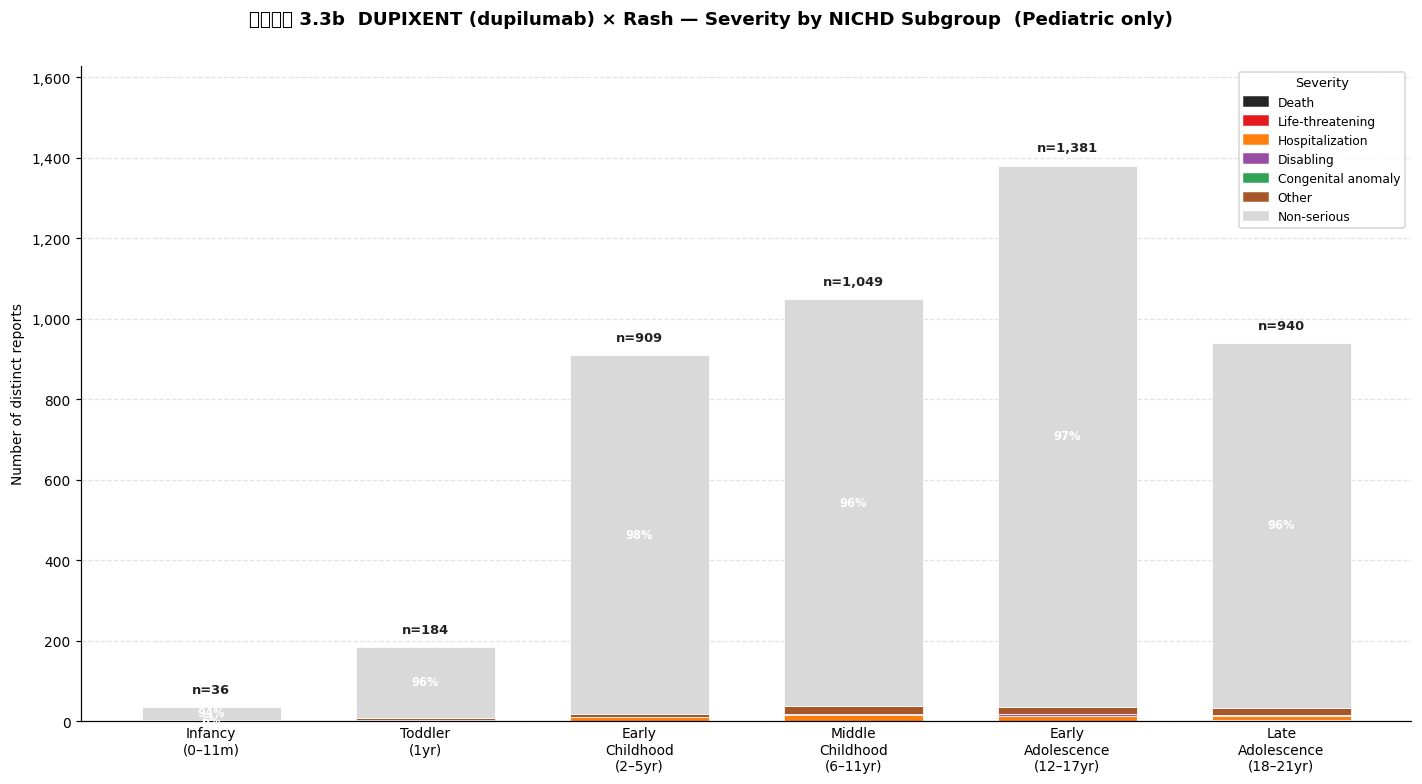

Saved → output/figures/severity_nichd_dupixent_rash.png


In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path

_N33B_ORDER  = ["infancy", "toddler", "early_childhood",
                "middle_childhood", "early_adolescence", "late_adolescence"]
_N33B_LABELS = ["Infancy\n(0–11m)", "Toddler\n(1yr)", "Early\nChildhood\n(2–5yr)",
                "Middle\nChildhood\n(6–11yr)", "Early\nAdolescence\n(12–17yr)",
                "Late\nAdolescence\n(18–21yr)"]
_N33B_SEV_COLS   = ["death", "life_threatening", "hospitalization",
                    "disabling", "congenital_anomali", "other"]
_N33B_SEV_LABELS = ["Death", "Life-threatening", "Hospitalization",
                    "Disabling", "Congenital anomaly", "Other", "Non-serious"]
_N33B_SEV_COLORS = ["#252525", "#e41a1c", "#ff7f0e", "#984ea3",
                    "#31a354", "#a65628", "#d9d9d9"]


def _nichd_pair_pivot(df: pd.DataFrame, product_prefix: str, reaction: str) -> pd.DataFrame:
    """Filter product×reaction, dedup per report, assign severity → NICHD × severity pivot."""
    mask = (
        df["medicinal_product"].str.upper().str.startswith(product_prefix.upper(), na=False)
        & (df["reaction_meddrapt"] == reaction)
    )
    sub = df[mask].drop_duplicates(subset=["safetyreportid"]).copy()
    if sub.empty:
        return pd.DataFrame(0, index=_N33B_ORDER, columns=_N33B_SEV_LABELS)
    conds = [sub[c].fillna(0).astype(int) == 1 for c in _N33B_SEV_COLS]
    sub["_sev"] = np.select(conds, _N33B_SEV_LABELS[:-1], default="Non-serious")
    return (
        sub.groupby(["nichd", "_sev"], observed=True)
        .size()
        .unstack(fill_value=0)
        .reindex(index=_N33B_ORDER, columns=_N33B_SEV_LABELS, fill_value=0)
    )


pivot_33b = _nichd_pair_pivot(df_ped, "DUPIXENT", "Rash")
totals_33b = pivot_33b.sum(axis=1).values

print("DUPIXENT × Rash — Pediatric reports per NICHD subgroup:")
display(pivot_33b.assign(TOTAL=totals_33b))

# ── Plot ──────────────────────────────────────────────────────────────────────
setup_plot_style()
figures_dir = Path("../data/notebook/output/top_terms_adult/figures")
figures_dir.mkdir(parents=True, exist_ok=True)

fig, ax = plt.subplots(figsize=(13, 7))
fig.suptitle(
    "กราฟ 3.3b  DUPIXENT (dupilumab) × Rash — Severity by NICHD Subgroup  (Pediatric only)",
    fontsize=12, fontweight="bold", y=1.01,
)

x   = np.arange(len(_N33B_ORDER))
bot = np.zeros(len(_N33B_ORDER))

for sev, color in zip(_N33B_SEV_LABELS, _N33B_SEV_COLORS):
    vals = pivot_33b[sev].values.astype(float)
    ax.bar(x, vals, bottom=bot, color=color, edgecolor="white", linewidth=0.5,
           width=0.65, label=sev)
    for xi, (v, b, tot) in enumerate(zip(vals, bot, totals_33b)):
        pct = 100.0 * v / tot if tot > 0 else 0.0
        if pct >= 5 and v > 0:
            ax.text(xi, b + v / 2, f"{pct:.0f}%", ha="center", va="center",
                    fontsize=7.5, fontweight="bold", color="white")
    bot += vals

ymax = float(bot.max()) if bot.max() > 0 else 1.0
for xi, (tot, top) in enumerate(zip(totals_33b, bot)):
    if tot > 0:
        ax.text(xi, top + ymax * 0.02, f"n={int(tot):,}",
                ha="center", va="bottom", fontsize=8.5, fontweight="bold", color="#222222")

ax.set_xticks(x)
ax.set_xticklabels(_N33B_LABELS, fontsize=9)
ax.set_ylabel("Number of distinct reports", fontsize=9)
ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda v, _: f"{int(v):,}"))
ax.set_ylim(0, ymax * 1.18)
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)
ax.tick_params(axis="x", length=0)
ax.grid(axis="y", linestyle="--", alpha=0.35, zorder=0)
ax.set_axisbelow(True)

handles = [plt.Rectangle((0, 0), 1, 1, color=c, edgecolor="none") for c in _N33B_SEV_COLORS]
ax.legend(handles, _N33B_SEV_LABELS, title="Severity",
          loc="upper right", ncol=1, fontsize=8, title_fontsize=8.5,
          frameon=True, edgecolor="#cccccc")

plt.tight_layout()
fname = "severity_nichd_dupixent_rash.png"
plt.savefig(figures_dir / fname, dpi=150, bbox_inches="tight")
plt.show()
print(f"Saved → {figures_dir / fname}")

---
## F.1 — Seriousness overview (full cohort): Top-5 by Death ∪ Hospitalization

**คำถาม:** จากข้อมูลทั้งชุด อาการ (PT) / ยา (`rxcui`) / คู่ยา–อาการ ใดมี **จำนวนรายงาน** ที่ถูก flag **`death=1` หรือ `hospitalization=1`** (ระดับเคส) สูงสุด?

**วิธีนับ (สอดคล้องกับที่ใช้ใน notebook):**
- กรองเฉพาะแถวที่เคสนั้นมี `death=1` **หรือ** `hospitalization=1`
- จากนั้น dedup ตามประเภทแล้วนับ **distinct `safetyreportid`**
  - **ADR:** `(report, reaction_meddrapt)`
  - **Drug:** `(report, rxcui)`
  - **Pair:** `(report, rxcui, reaction_meddrapt)`
- เลือก **Top 5** ต่อหมวด โดยจัดอันดับจาก **ผลรวม Ped + Adult** แล้วพล็อตเปรียบเทียบจำนวนระหว่างเด็กกับผู้ใหญ่
- **Subgroup เด็ก:** แยกตาม `nichd` สำหรับ Top-5 ADR เดียวกัน (รายงานที่มี Death∪Hosp)

> **หมายเหตุ:** flag อยู่ระดับรายงาน — หลายแถวใน ICSR เดียวกันจะมีค่าเดียวกัน; การนับไม่ซ้ำต่อเคส


=== Full cohort — Top 5 ADR (Death∪Hosp) per cohort ===


,n_reports,ADR
rank,,
1,8827,Pyrexia
2,8691,Vomiting
3,4932,Death
4,4780,Overdose
5,4760,Seizure


,n_reports,ADR
rank,,
1,180355,Death
2,74283,Dyspnoea
3,72104,Pneumonia
4,66014,Diarrhoea
5,62833,Pyrexia



=== Aligned Top-5 ADR (by Ped+Adult total) — used in plots ===


,reaction_meddrapt,n_ped,n_adu,n_tot
0,Death,4932,180355,185287
1,Dyspnoea,3127,74283,77410
2,Pneumonia,3877,72104,75981
3,Pyrexia,8827,62833,71660
4,Diarrhoea,3488,66014,69502


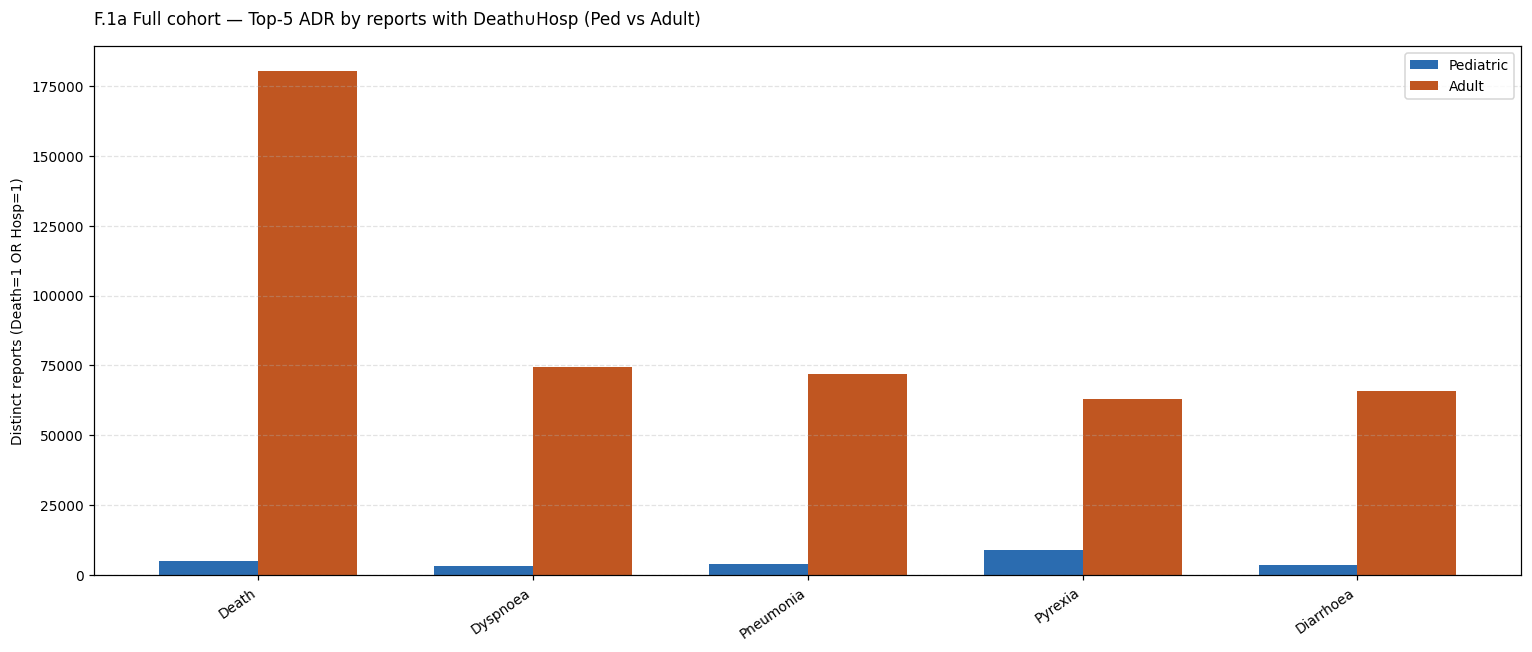


=== Aligned Top-5 Drug (rxcui) by Death∪Hosp ===


,rxcui,n_ped,n_adu,n_tot,label
0,337535,26,38291,38317,REVLIMID (lenalidomide)
1,6851,6289,26765,33054,METHOTREXATE. (methotrexate)
2,161,5237,26957,32194,ACETAMINOPHEN (acetaminophen; acetaminoph…
3,8640,2653,27217,29870,PREDNISONE. (chloramphenicol / prednisone…
4,3002,4499,21524,26023,CYCLOPHOSPHAMIDE (cyclophosphamide; cyclo…


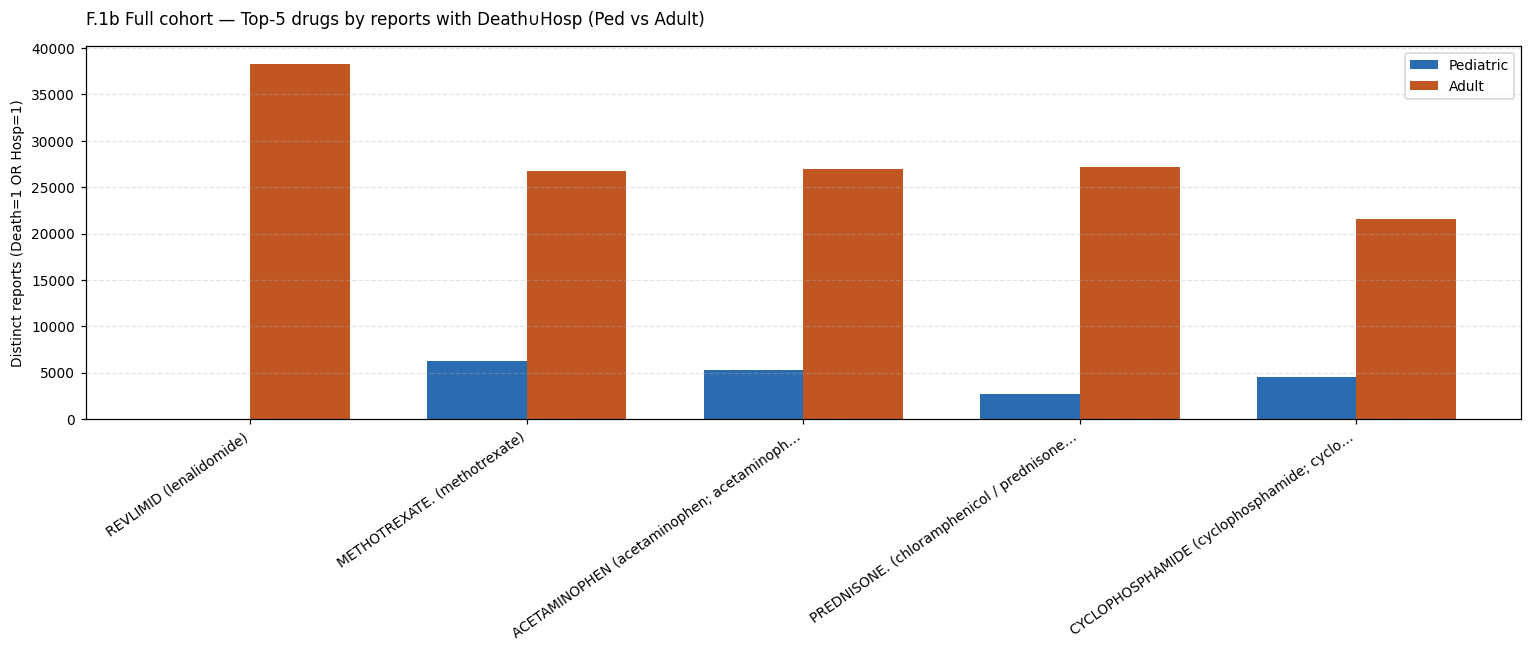


=== Aligned Top-5 Drug–ADR pairs by Death∪Hosp ===


,rxcui,reaction_meddrapt,n_ped,n_adu,n_tot,label
0,337535,Death,6,10011,10017,REVLIMID — Death
1,337045,Death,16,7979,7995,ARANESP — Death
2,337535,Pneumonia,3,6826,6829,REVLIMID — Pneumonia
3,161,Vomiting,1597,3562,5159,ACETAMINOPHEN — Vomiting
4,993453,Death,0,5134,5134,(?) — Death


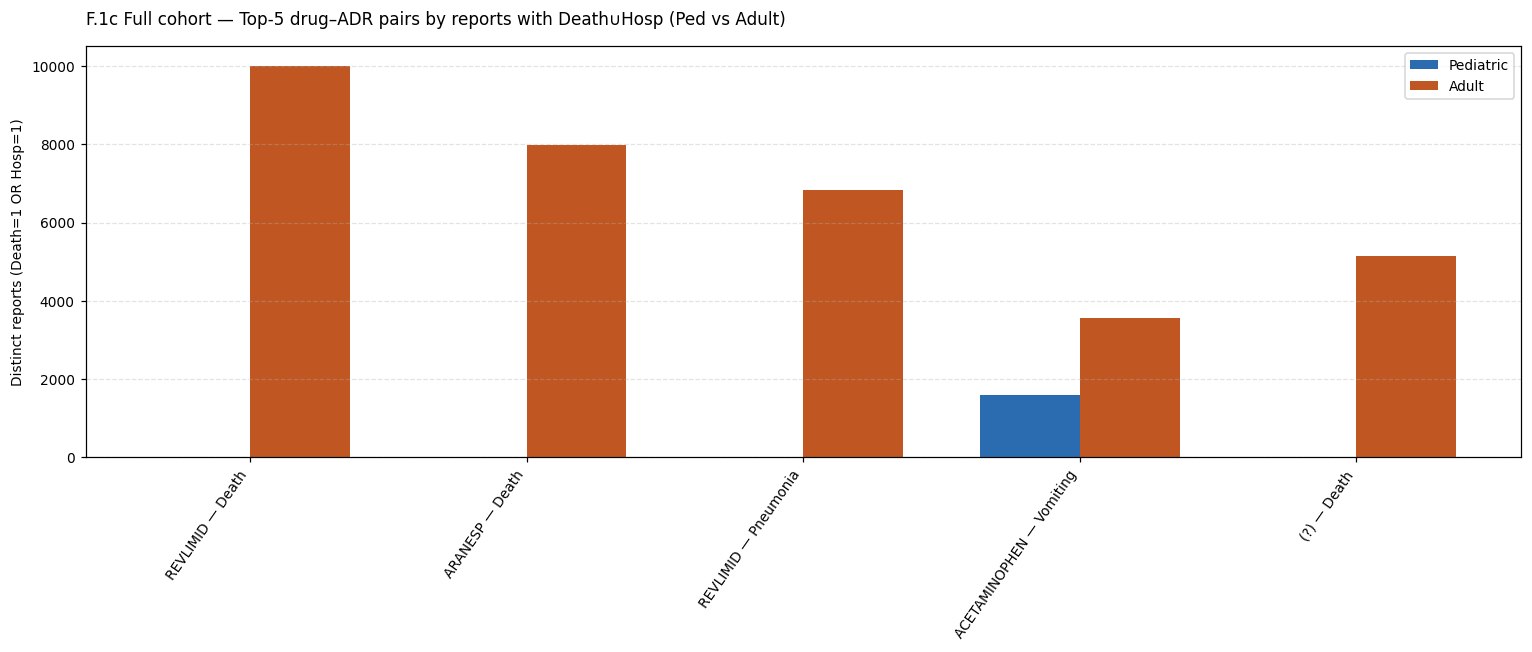

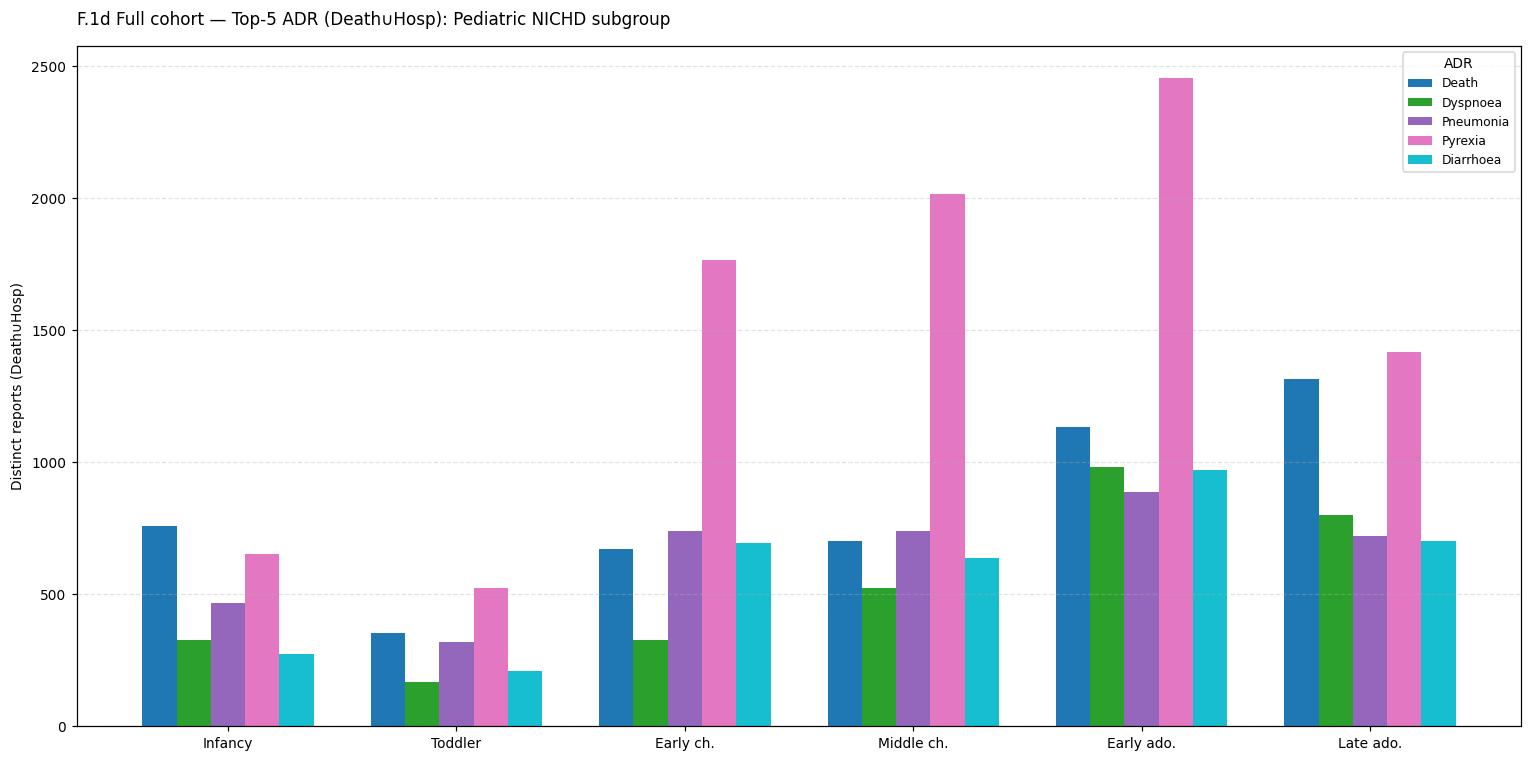

Saved figures + CSV under output/figures and output/csv (F.1 full cohort).


In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path

# ── Config ───────────────────────────────────────────────────────────────────
N_TOP = 5
NICHD_ORDER = [
    "infancy", "toddler", "early_childhood", "middle_childhood",
    "early_adolescence", "late_adolescence",
]
NICHD_X = ["Infancy", "Toddler", "Early ch.", "Middle ch.", "Early ado.", "Late ado."]

figures_dir = Path("../data/notebook/output/top_terms_adult/figures")
csv_dir = Path("../data/notebook/output/top_terms_adult/csv")
figures_dir.mkdir(parents=True, exist_ok=True)
csv_dir.mkdir(parents=True, exist_ok=True)


def _mask_death_or_hosp(df: pd.DataFrame) -> pd.Series:
    d = pd.to_numeric(df["death"], errors="coerce").fillna(0).astype(int)
    h = pd.to_numeric(df["hospitalization"], errors="coerce").fillna(0).astype(int)
    return (d == 1) | (h == 1)


def _series_top5_adr(df: pd.DataFrame) -> pd.Series:
    sub = df.loc[_mask_death_or_hosp(df), ["safetyreportid", "reaction_meddrapt"]].dropna(
        subset=["reaction_meddrapt"]
    )
    return (
        sub.drop_duplicates(["safetyreportid", "reaction_meddrapt"])
        .groupby("reaction_meddrapt", observed=True)
        .size()
        .sort_values(ascending=False)
    )


def _series_top5_drug(df: pd.DataFrame) -> pd.Series:
    sub = df.loc[_mask_death_or_hosp(df), ["safetyreportid", "rxcui"]].dropna(subset=["rxcui"])
    return (
        sub.drop_duplicates(["safetyreportid", "rxcui"])
        .groupby("rxcui", observed=True)
        .size()
        .sort_values(ascending=False)
    )


def _series_top5_pair(df: pd.DataFrame) -> pd.Series:
    sub = df.loc[_mask_death_or_hosp(df), ["safetyreportid", "rxcui", "reaction_meddrapt"]].dropna(
        subset=["rxcui", "reaction_meddrapt"]
    )
    return (
        sub.drop_duplicates(["safetyreportid", "rxcui", "reaction_meddrapt"])
        .groupby(["rxcui", "reaction_meddrapt"], observed=True)
        .size()
        .sort_values(ascending=False)
    )


def _align_top5(s_ped: pd.Series, s_adu: pd.Series) -> pd.DataFrame:
    """Pick top N keys by combined Ped+Adult count."""
    all_idx = s_ped.index.union(s_adu.index)
    m = pd.DataFrame({"n_ped": s_ped.reindex(all_idx).fillna(0).astype(int),
                      "n_adu": s_adu.reindex(all_idx).fillna(0).astype(int)})
    m["n_tot"] = m["n_ped"] + m["n_adu"]
    m = m.sort_values("n_tot", ascending=False).head(N_TOP)
    return m


def _plot_grouped_ped_adu(m: pd.DataFrame, labels: list, title: str, fname: str, x_rot: int = 35):
    setup_plot_style()
    x = np.arange(len(m))
    w = 0.36
    fig, ax = plt.subplots(figsize=(14, 6))
    ax.bar(x - w / 2, m["n_ped"], w, label="Pediatric", color="#2b6cb0")
    ax.bar(x + w / 2, m["n_adu"], w, label="Adult", color="#c05621")
    ax.set_xticks(x)
    ax.set_xticklabels(labels, rotation=x_rot, ha="right", fontsize=9)
    ax.set_ylabel("Distinct reports (Death=1 OR Hosp=1)")
    ax.set_title(title, fontsize=11, loc="left")
    ax.legend()
    ax.grid(axis="y", linestyle="--", alpha=0.35)
    plt.tight_layout()
    plt.savefig(figures_dir / fname, dpi=300, bbox_inches="tight")
    plt.show()


# ── 1) Top tables (raw per-cohort top 5 preview) ─────────────────────────────
s_ped_adr = _series_top5_adr(df_ped)
s_adu_adr = _series_top5_adr(df_adu)
s_ped_rx = _series_top5_drug(df_ped)
s_adu_rx = _series_top5_drug(df_adu)
s_ped_pr = _series_top5_pair(df_ped)
s_adu_pr = _series_top5_pair(df_adu)

print("=== Full cohort — Top 5 ADR (Death∪Hosp) per cohort ===")
display(
    pd.DataFrame(
        {
            "rank": range(1, N_TOP + 1),
            "n_reports": s_ped_adr.head(N_TOP).values,
            "ADR": s_ped_adr.head(N_TOP).index.astype(str),
        }
    ).set_index("rank")
)
display(
    pd.DataFrame(
        {
            "rank": range(1, N_TOP + 1),
            "n_reports": s_adu_adr.head(N_TOP).values,
            "ADR": s_adu_adr.head(N_TOP).index.astype(str),
        }
    ).set_index("rank")
)

m_adr = _align_top5(s_ped_adr, s_adu_adr)
print("\n=== Aligned Top-5 ADR (by Ped+Adult total) — used in plots ===")
_adr_tbl = m_adr.reset_index()
_adr_tbl.columns = ["reaction_meddrapt", "n_ped", "n_adu", "n_tot"]
display(_adr_tbl)

_plot_grouped_ped_adu(
    m_adr,
    list(m_adr.index),
    "F.1a Full cohort — Top-5 ADR by reports with Death∪Hosp (Ped vs Adult)",
    "seriousness_f1_top5_adr_full.png",
)

# Drugs — labels via _label_lookups
m_rx = _align_top5(s_ped_rx, s_adu_rx)
top_rx_df = pd.DataFrame({"rxcui": m_rx.index.astype(str)})
ded_ped_rx = df_ped.drop_duplicates(["safetyreportid", "rxcui"])
med_lkp, ing_lkp, _ = _label_lookups(ded_ped_rx, ["rxcui"], top_rx_df)
rx_labels = [
    shorten_label(f"{med_lkp.get(str(r), '(?)')} ({ing_lkp.get(str(r), '(?)')})", 42)
    for r in m_rx.index
]
print("\n=== Aligned Top-5 Drug (rxcui) by Death∪Hosp ===")
m_rx_disp = m_rx.reset_index()
m_rx_disp.columns = ["rxcui", "n_ped", "n_adu", "n_tot"]
m_rx_disp["label"] = rx_labels
display(m_rx_disp)

_plot_grouped_ped_adu(
    m_rx,
    rx_labels,
    "F.1b Full cohort — Top-5 drugs by reports with Death∪Hosp (Ped vs Adult)",
    "seriousness_f1_top5_drug_full.png",
)

# Pairs
m_pr = _align_top5(s_ped_pr, s_adu_pr)
pair_rows = [{"rxcui": a, "reaction_meddrapt": b} for a, b in m_pr.index]
pair_top = pd.DataFrame(pair_rows)
ded_pair = df_ped.drop_duplicates(["safetyreportid", "rxcui", "reaction_meddrapt"])
med_p, ing_p, _ = _label_lookups(ded_pair, ["rxcui", "reaction_meddrapt"], pair_top)


def _pair_key(row):
    return str(row["rxcui"]) + "||" + str(row["reaction_meddrapt"])


pr_labels = []
for _, row in pair_top.iterrows():
    k = _pair_key(row)
    pr_labels.append(
        shorten_label(
            f"{med_p.get(k, '(?)')} — {row['reaction_meddrapt']}",
            48,
        )
    )

print("\n=== Aligned Top-5 Drug–ADR pairs by Death∪Hosp ===")
m_pr_disp = m_pr.reset_index()
m_pr_disp.columns = ["rxcui", "reaction_meddrapt", "n_ped", "n_adu", "n_tot"]
m_pr_disp["label"] = pr_labels
display(m_pr_disp)

_plot_grouped_ped_adu(
    m_pr,
    pr_labels,
    "F.1c Full cohort — Top-5 drug–ADR pairs by reports with Death∪Hosp (Ped vs Adult)",
    "seriousness_f1_top5_pair_full.png",
    x_rot=55,
)

# ── 2) Pediatric NICHD — Top-5 ADR (same list as m_adr) ──────────────────────
adr_list = list(m_adr.index)
sub_n = df_ped.loc[
    _mask_death_or_hosp(df_ped) & df_ped["reaction_meddrapt"].isin(adr_list),
    ["safetyreportid", "reaction_meddrapt", "nichd"],
].drop_duplicates(["safetyreportid", "reaction_meddrapt"])

pivot = (
    sub_n.dropna(subset=["nichd"])
    .groupby(["nichd", "reaction_meddrapt"], observed=True)
    .size()
    .unstack(fill_value=0)
    .reindex(NICHD_ORDER)
    .fillna(0)
    .astype(int)
)

# ensure column order matches adr_list
for a in adr_list:
    if a not in pivot.columns:
        pivot[a] = 0
pivot = pivot[adr_list]

setup_plot_style()
fig, ax = plt.subplots(figsize=(14, 7))
x = np.arange(len(NICHD_ORDER))
w = 0.15
colors = plt.cm.tab10(np.linspace(0, 0.9, len(adr_list)))
for i, adr in enumerate(adr_list):
    ax.bar(x + (i - (len(adr_list) - 1) / 2) * w, pivot[adr].values, w, label=adr, color=colors[i])

ax.set_xticks(x)
ax.set_xticklabels(NICHD_X, fontsize=9)
ax.set_ylabel("Distinct reports (Death∪Hosp)")
ax.set_title(
    "F.1d Full cohort — Top-5 ADR (Death∪Hosp): Pediatric NICHD subgroup",
    fontsize=11,
    loc="left",
)
ax.legend(title="ADR", fontsize=8, loc="upper right")
ax.grid(axis="y", linestyle="--", alpha=0.35)
plt.tight_layout()
plt.savefig(figures_dir / "seriousness_f1_top5_adr_nichd_full.png", dpi=300, bbox_inches="tight")
plt.show()

# ── 3) Export CSV ────────────────────────────────────────────────────────────
_adr_tbl.to_csv(csv_dir / "seriousness_f1_top5_adr_full.csv", index=False)
_rx_tbl = m_rx.reset_index()
_rx_tbl.columns = ["rxcui", "n_ped", "n_adu", "n_tot"]
_rx_tbl.to_csv(csv_dir / "seriousness_f1_top5_drug_full.csv", index=False)
_pr_tbl = m_pr.reset_index()
_pr_tbl.columns = ["rxcui", "reaction_meddrapt", "n_ped", "n_adu", "n_tot"]
_pr_tbl.to_csv(csv_dir / "seriousness_f1_top5_pair_full.csv", index=False)
pivot.to_csv(csv_dir / "seriousness_f1_top5_adr_nichd_full.csv")
print("Saved figures + CSV under output/figures and output/csv (F.1 full cohort).")


---

# C — Intersection Analysis (Pediatric ∩ Adult)

ค้นหา term / drug / pair ที่ **ปรากฏในทั้งสองกลุ่มพร้อมกัน**  
จัดอันดับตาม **combined distinct reports** (`n_ped + n_adu`)

**กราฟ:** `plot_barh_grouped()` — แต่ละแถวมี **2 แท่งคู่**  
แท่งบน (น้ำเงิน) = Pediatric · แท่งล่าง (ส้ม) = Adult

---

# 4. Intersect ADR — Top 10 `reaction_meddrapt` ที่พบร่วมกัน

**Helper:** `intersect_adr_reports(df_ped, df_adu, n=10)`

| คอลัมน์ | ความหมาย |
|---------|---------|
| `n_ped` | distinct reports (Pediatric) ที่รายงาน PT นี้ |
| `n_adu` | distinct reports (Adult) ที่รายงาน PT นี้ |
| `n_combined` | ผลรวม — ใช้เป็นเกณฑ์จัดอันดับ |

ADR ใน intersection = ปฏิกิริยาที่ **ไม่จำเพาะกลุ่มอายุ** มีนัยสำคัญต่อ pharmacovigilance

## ก่อนวิเคราะห์ — สร้างไฟล์ `ped_adult_intersection.csv`

กรองเฉพาะแถวที่ **`(rxcui, reaction_meddrapt)` pair ปรากฏในทั้งสองกลุ่ม (Pediatric ∩ Adult)**
จากนั้นรวม Ped + Adult ไว้ใน DataFrame เดียวพร้อมคอลัมน์ `cohort`

ไฟล์นี้เป็น **single source of truth** สำหรับทุกการวิเคราะห์ใน Section C:
- Section 4 — นับ `reaction_meddrapt` จากไฟล์นี้ (intersection ADRs)
- Section 5 — นับ `rxcui` จากไฟล์นี้ (intersection drugs)
- Section 6 — นับ `(rxcui, reaction_meddrapt)` pair จากไฟล์นี้

> **Logic:** pair ใดก็ตามที่ได้จากไฟล์นี้ ยืนยันแล้วว่าพบในทั้ง Pediatric **และ** Adult


In [ ]:
import pandas as pd

# -- Build ped_adult_intersection (Section C) -----------------------------------
# Logic: keep rows where the (rxcui, reaction_meddrapt) PAIR appears in BOTH cohorts.

N_INTERSECT = 10

# (1) Find pairs that exist in BOTH cohorts
def _pair_set(df):
    sub = df.dropna(subset=["rxcui"])[["rxcui","reaction_meddrapt"]].drop_duplicates()
    return set(zip(sub["rxcui"].astype(str), sub["reaction_meddrapt"].astype(str)))

pair_isect_set  = _pair_set(df_ped) & _pair_set(df_adu)
pair_isect_keys = {rx + "||" + adr for rx, adr in pair_isect_set}
print(f"(rxcui, ADR) pair intersection: {len(pair_isect_set):,} unique pairs")

# (2) Filter each cohort — keep in memory as df_ped_i / df_adu_i
def _filter_to_pair_isect(df, cohort):
    out = df.dropna(subset=["rxcui"]).copy()
    key = out["rxcui"].astype(str) + "||" + out["reaction_meddrapt"].astype(str)
    out = out[key.isin(pair_isect_keys)].copy()
    out.insert(0, "cohort", cohort)
    return out

df_ped_i = _filter_to_pair_isect(df_ped, "Pediatric")
df_adu_i = _filter_to_pair_isect(df_adu, "Adult")

print(f"Rows  Pediatric: {len(df_ped_i):,}  |  Adult: {len(df_adu_i):,}")

# (3) Save only essential columns to CSV (not all 30+ cols — much smaller file)
_SAVE_COLS = ["cohort", "safetyreportid", "rxcui", "reaction_meddrapt",
              "medicinal_product", "ingredient"]
_save_cols = [c for c in _SAVE_COLS if c in df_ped_i.columns]

isect_csv_path = "output/csv/ped_adult_intersection.csv"
pd.concat([df_ped_i[_save_cols], df_adu_i[_save_cols]], ignore_index=True).to_csv(
    isect_csv_path, index=False
)

print(f"Saved: {isect_csv_path}  (columns: {_save_cols})")
print(f"Unique pairs: {len(pair_isect_set):,}")


(rxcui, ADR) pair intersection: 107,463 unique pairs
Rows  Pediatric: 854,714  |  Adult: 11,141,022
Saved: output/csv/ped_adult_intersection.csv  (columns: ['cohort', 'safetyreportid', 'rxcui', 'reaction_meddrapt', 'medicinal_product', 'ingredient'])
Unique pairs: 107,463


## C.0 — Intersection subset: Overview (Table 1 style)

สรุปลักษณะ **แบบเดียวกับ** `notebook/overview.ipynb` (Table 1) แต่ใช้เฉพาะข้อมูล **intersection** — แถวใน `df_ped_i` / `df_adu_i` หลังกรองคู่ `(rxcui, reaction_meddrapt)` ที่มีทั้งในเด็กและผู้ใหญ่

**ส่วนประกอบ:** จำนวน ICSR, เพศ, ประเทศผู้รายงาน, คุณวุฒิผู้รายงาน, serious outcome flags (6 ชนิด), serious vs non-serious, จำนวนยา (`rxcui`) / อาการต่อ ICSR

**บันทึกผล:** `output/figures/overview_intersection_ped_adult.png`, `output/csv/overview_intersection_summary.csv`

> ต้องรัน cell สร้าง intersection (`df_ped_i` / `df_adu_i`) ก่อน


,section,item,Pediatric,Adult
0,Number of ICRSs,,"207,368","1,982,482"
1,Gender,Female,"102,834 (49.6%)","1,148,161 (57.9%)"
2,,Male,"97,383 (47.0%)","801,398 (40.4%)"
3,,Unknown,"7,151 (3.4%)","32,923 (1.7%)"
4,Reporter country,Foreign,"109,849 (53.0%)","1,010,982 (51.0%)"
5,,United States,"97,519 (47.0%)","971,500 (49.0%)"
6,,Null/unknown,0 (0.0%),0 (0.0%)
7,Reporter qualification,Physician,"93,408 (45.0%)","821,676 (41.4%)"
8,,Pharmacist,"17,278 (8.3%)","287,162 (14.5%)"
9,,Other health professional,"96,682 (46.6%)","873,644 (44.1%)"


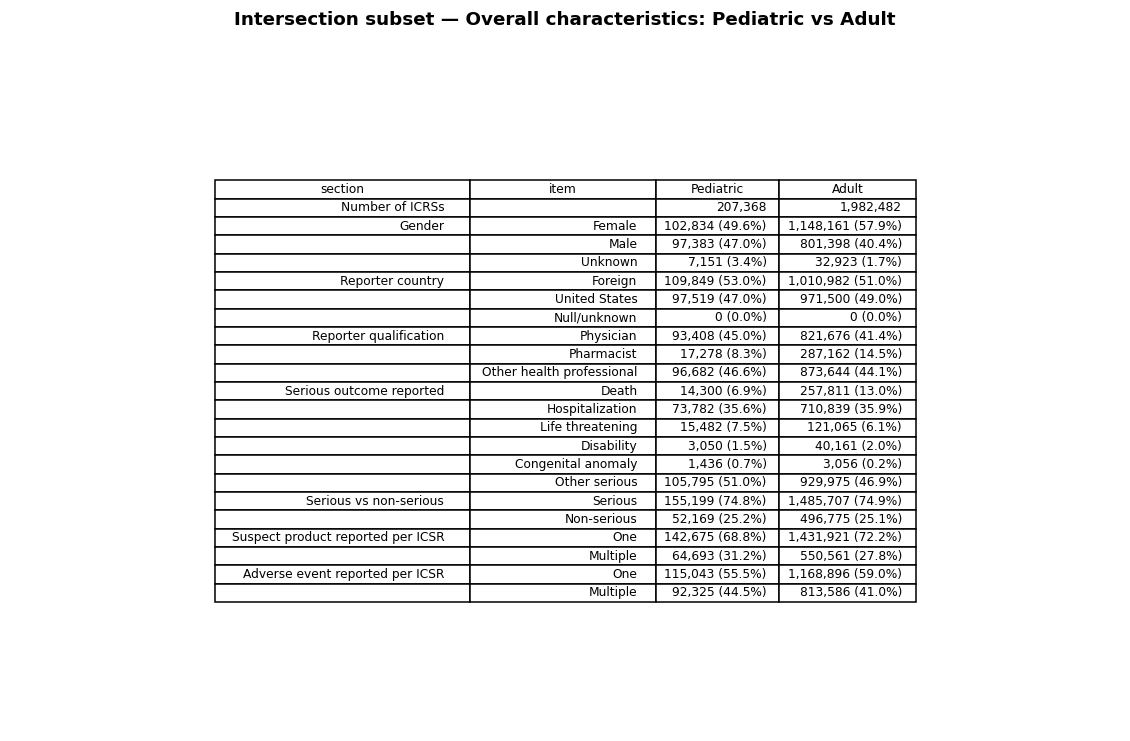

Saved: output/figures/overview_intersection_ped_adult.png
Saved: output/csv/overview_intersection_summary.csv
Intersection rows: Ped 854,714 | Adult 11,141,022  |  Reports: Ped 207,368 | Adult 1,982,482


In [ ]:
# ── Intersection overview (same logic as overview.ipynb Table 1) ─────────────
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path

assert "df_ped_i" in dir() and "df_adu_i" in dir(), "Run the intersection build cell first."

# Full row-level = intersection drug–reaction lines
ped_full_i = df_ped_i.copy()
adu_full_i = df_adu_i.copy()

# Patient-level = 1 row per safetyreportid
ped_i = ped_full_i.drop_duplicates("safetyreportid").reset_index(drop=True)
adu_i = adu_full_i.drop_duplicates("safetyreportid").reset_index(drop=True)


def _norm_sex(v):
    if pd.isna(v):
        return "Unknown"
    s = str(v).strip().lower()
    if s in ("1", "f", "female"):
        return "Female"
    if s in ("2", "m", "male"):
        return "Male"
    if s in ("0", "9", "unk", "unknown", "u"):
        return "Unknown"
    if str(v) in ("Female", "Male", "Unknown"):
        return str(v)
    return "Unknown"


_US_VARIANTS = {"US", "USA", "UNITED STATES", "UNITED STATES OF AMERICA"}


def _norm_country(v):
    if pd.isna(v):
        return "Null/unknown"
    return "United States" if str(v).strip().upper() in _US_VARIANTS else "Foreign"


ped_i = ped_i.copy()
adu_i = adu_i.copy()
ped_i["patient_sex"] = ped_i["patient_sex"].apply(_norm_sex)
adu_i["patient_sex"] = adu_i["patient_sex"].apply(_norm_sex)
ped_i["reporter_country"] = ped_i["reporter_country"].map(_norm_country)
adu_i["reporter_country"] = adu_i["reporter_country"].map(_norm_country)

# ── Helpers (mirroring overview.ipynb) ────────────────────────────────────────


def format_count_pct(count: int, total: int) -> str:
    pct = (count / total * 100) if total > 0 else 0
    return f"{int(count):,} ({pct:.1f}%)"


def _to_binary(v) -> int:
    if pd.isna(v):
        return 0
    if isinstance(v, (bool, np.bool_)):
        return int(v)
    if isinstance(v, str):
        return 1 if v.strip().lower() in {"1", "y", "yes", "true", "t"} else 0
    try:
        return 1 if float(v) == 1 else 0
    except (TypeError, ValueError):
        return 0


def make_binary_count(series: pd.Series) -> int:
    return int(series.map(_to_binary).sum())


def make_total_row(ped_dedup: pd.DataFrame, adult_dedup: pd.DataFrame) -> pd.DataFrame:
    return pd.DataFrame(
        [
            {
                "section": "Number of ICRSs",
                "item": "",
                "Pediatric": f"{ped_dedup['safetyreportid'].nunique():,}",
                "Adult": f"{adult_dedup['safetyreportid'].nunique():,}",
            }
        ]
    )


def _count_pct_series(df: pd.DataFrame, col: str, categories: list = None, fillna_label: str = "Null/unknown"):
    s = df[col].copy()
    if s.dtype == "O" or str(s.dtype).startswith("category"):
        s = s.fillna(fillna_label)
    counts = s.value_counts(dropna=False)
    if categories is not None:
        counts = counts.reindex(categories, fill_value=0)
    total = len(s)
    pct = counts / total * 100 if total > 0 else counts * 0
    out = pd.DataFrame({"item": counts.index, "count": counts.values, "percent": pct.values})
    out["formatted"] = out.apply(lambda r: format_count_pct(int(r["count"]), total), axis=1)
    return out[["item", "formatted"]]


def make_section_from_column(ped, adult, col: str, section_name: str, categories: list = None, fillna_label: str = "Null/unknown"):
    ped_tbl = _count_pct_series(ped, col, categories, fillna_label).rename(columns={"formatted": "Pediatric"})
    adult_tbl = _count_pct_series(adult, col, categories, fillna_label).rename(columns={"formatted": "Adult"})
    merged = ped_tbl.merge(adult_tbl, on="item", how="outer")
    merged.insert(0, "section", section_name)
    return merged


def make_section_from_binary_columns(ped, adult, section_name: str, item_map: list, non_serious_cols: list = None):
    ped_total = len(ped)
    adult_total = len(adult)
    rows = []
    for col, label in item_map:
        rows.append(
            {
                "section": section_name,
                "item": label,
                "Pediatric": format_count_pct(make_binary_count(ped[col]), ped_total),
                "Adult": format_count_pct(make_binary_count(adult[col]), adult_total),
            }
        )
    if non_serious_cols:
        ped_non = int((ped["serious"] == 0).sum())
        adu_non = int((adult["serious"] == 0).sum())
        rows.append(
            {
                "section": section_name,
                "item": "Non-serious",
                "Pediatric": format_count_pct(ped_non, ped_total),
                "Adult": format_count_pct(adu_non, adult_total),
            }
        )
    return pd.DataFrame(rows)


def _count_per_icsr(df: pd.DataFrame, id_col: str, value_col: str):
    per_report = (
        df[[id_col, value_col]]
        .dropna(subset=[id_col, value_col])
        .drop_duplicates()
        .groupby(id_col)[value_col]
        .nunique()
    )
    labels = pd.Series(np.where(per_report == 1, "One", "Multiple"), index=per_report.index)
    total = len(labels)
    counts = labels.value_counts().reindex(["One", "Multiple"], fill_value=0)
    out = pd.DataFrame({"item": counts.index, "count": counts.values})
    out["formatted"] = out["count"].apply(lambda x: format_count_pct(x, total))
    return out[["item", "formatted"]]


def make_section_from_icsr_counts(ped_full, adult_full, id_col: str, value_col: str, section_name: str):
    ped_tbl = _count_per_icsr(ped_full, id_col, value_col).rename(columns={"formatted": "Pediatric"})
    adult_tbl = _count_per_icsr(adult_full, id_col, value_col).rename(columns={"formatted": "Adult"})
    merged = ped_tbl.merge(adult_tbl, on="item", how="outer")
    merged.insert(0, "section", section_name)
    return merged


def prettify_summary(df: pd.DataFrame) -> pd.DataFrame:
    out = df.copy()
    out["section"] = out["section"].mask(out["section"].duplicated(), "")
    return out


# ── Build Table 1 ─────────────────────────────────────────────────────────────
summary_parts = []

summary_parts.append(make_total_row(ped_i, adu_i))

summary_parts.append(
    make_section_from_column(
        ped_i,
        adu_i,
        col="patient_sex",
        section_name="Gender",
        categories=["Female", "Male", "Unknown"],
    )
)

summary_parts.append(
    make_section_from_column(
        ped_i,
        adu_i,
        col="reporter_country",
        section_name="Reporter country",
        categories=["Foreign", "United States", "Null/unknown"],
    )
)

_QUAL_ORDER = [
    "Physician",
    "Pharmacist",
    "Other health professional",
    "Consumer or non-health professional",
    "Lawyer",
    "Null/unknown",
]
_all_quals = pd.Index(
    pd.concat([ped_i["reporter_qualification"], adu_i["reporter_qualification"]], ignore_index=True)
    .dropna()
    .unique()
)
_extra_quals = sorted(q for q in _all_quals if q not in _QUAL_ORDER)
qual_categories = [q for q in _QUAL_ORDER if q in _all_quals] + _extra_quals

summary_parts.append(
    make_section_from_column(
        ped_i,
        adu_i,
        col="reporter_qualification",
        section_name="Reporter qualification",
        categories=qual_categories,
    )
)

SERIOUS_OUTCOME_ITEMS = [
    ("death", "Death"),
    ("hospitalization", "Hospitalization"),
    ("life_threatening", "Life threatening"),
    ("disabling", "Disability"),
    ("congenital_anomali", "Congenital anomaly"),
    ("other", "Other serious"),
]
summary_parts.append(
    make_section_from_binary_columns(
        ped_i,
        adu_i,
        section_name="Serious outcome reported",
        item_map=SERIOUS_OUTCOME_ITEMS,
        non_serious_cols=None,
    )
)

summary_parts.append(
    make_section_from_binary_columns(
        ped_i,
        adu_i,
        section_name="Serious vs non-serious",
        item_map=[("serious", "Serious")],
        non_serious_cols=["serious"],
    )
)

summary_parts.append(
    make_section_from_icsr_counts(
        ped_full_i,
        adu_full_i,
        id_col="safetyreportid",
        value_col="rxcui",
        section_name="Suspect product reported per ICSR",
    )
)

summary_parts.append(
    make_section_from_icsr_counts(
        ped_full_i,
        adu_full_i,
        id_col="safetyreportid",
        value_col="reaction_meddrapt",
        section_name="Adverse event reported per ICSR",
    )
)

summary_df = pd.concat(summary_parts, ignore_index=True)
display_df = prettify_summary(summary_df)

try:
    from IPython.display import display
except ImportError:
    display = print

display(display_df)

# ── Save PNG + CSV ────────────────────────────────────────────────────────────
out_dir = Path("../data/notebook/output/top_terms_adult/figures")
csv_dir = Path("../data/notebook/output/top_terms_adult/csv")
out_dir.mkdir(parents=True, exist_ok=True)
csv_dir.mkdir(parents=True, exist_ok=True)

fig, ax = plt.subplots(figsize=(13, 8))
ax.axis("off")
tbl = ax.table(
    cellText=display_df.values,
    colLabels=display_df.columns,
    loc="center",
)
tbl.auto_set_font_size(False)
tbl.set_fontsize(8)
tbl.auto_set_column_width(col=list(range(len(display_df.columns))))
plt.title(
    "Intersection subset — Overall characteristics: Pediatric vs Adult",
    pad=18,
    fontsize=12,
    fontweight="bold",
)
png_path = out_dir / "overview_intersection_ped_adult.png"
plt.savefig(png_path, bbox_inches="tight", dpi=300)
plt.show()
print(f"Saved: {png_path}")

csv_path = csv_dir / "overview_intersection_summary.csv"
summary_df.to_csv(csv_path, index=False)
print(f"Saved: {csv_path}")

print(
    f"Intersection rows: Ped {len(ped_full_i):,} | Adult {len(adu_full_i):,}  |  "
    f"Reports: Ped {ped_i['safetyreportid'].nunique():,} | Adult {adu_i['safetyreportid'].nunique():,}"
)


,rank,reaction_meddrapt,n_ped,n_adu,n_combined
0,1,Nausea,10860,153362,164222
1,2,Death,4651,145174,149825
2,3,Diarrhoea,7188,142556,149744
3,4,Fatigue,5993,140060,146053
4,5,Dyspnoea,6498,123534,130032
5,6,Headache,9669,110401,120070
6,7,Vomiting,14544,96448,110992
7,8,Pyrexia,14114,89495,103609
8,9,Rash,10891,92019,102910
9,10,Pain,4651,89145,93796


Intersection  Ped: 207,368 | Adult: 1,982,482 distinct reports


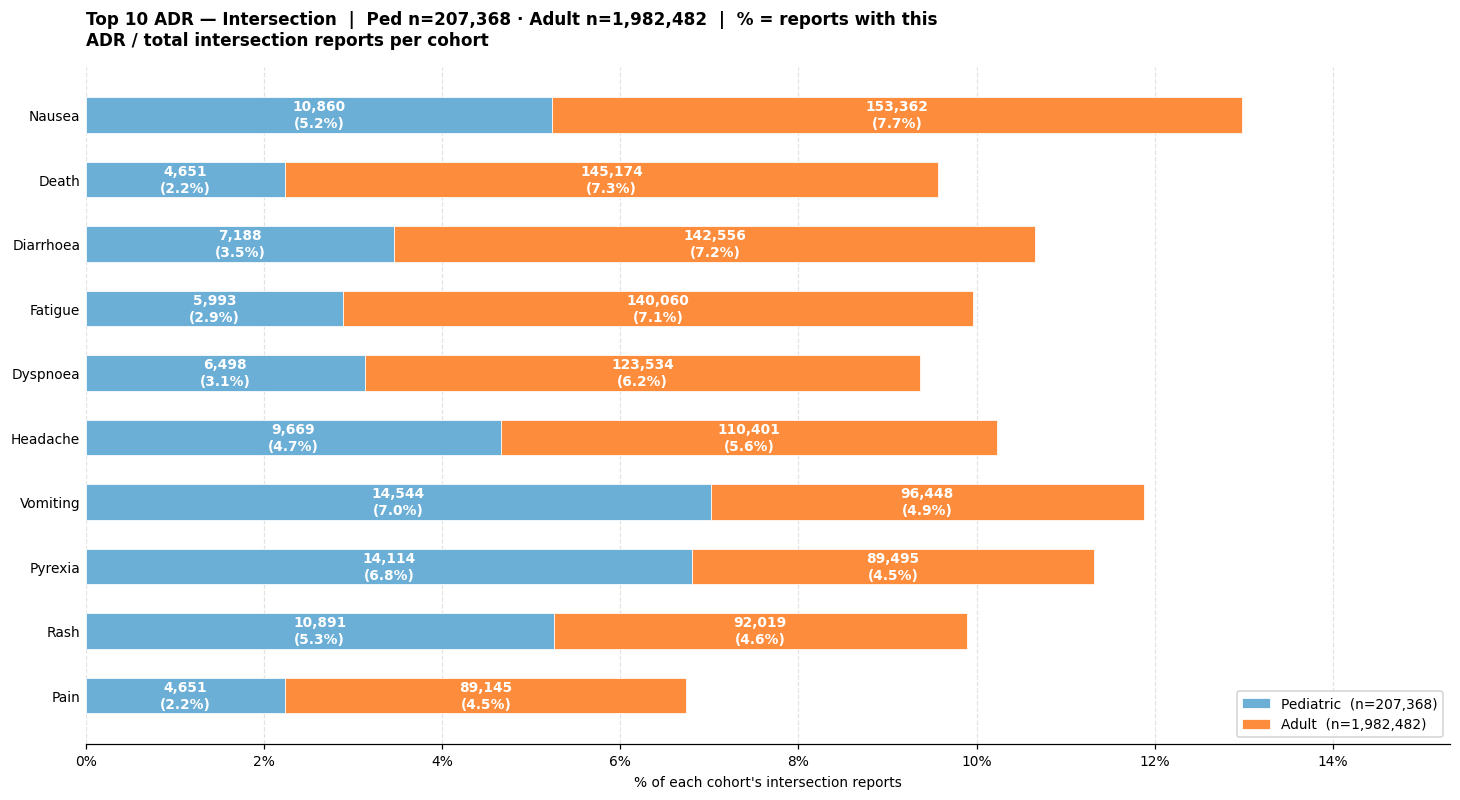

In [ ]:
# -- Section 4: Top 10 ADR from intersection dataset --------------------------
# df_ped_i / df_adu_i are already in memory from Cell 38 — no CSV re-read needed.

ped_adr = (
    df_ped_i.drop_duplicates(["safetyreportid","reaction_meddrapt"])
    .groupby("reaction_meddrapt", observed=True).size().reset_index(name="n_ped")
)
adu_adr = (
    df_adu_i.drop_duplicates(["safetyreportid","reaction_meddrapt"])
    .groupby("reaction_meddrapt", observed=True).size().reset_index(name="n_adu")
)
isect_adr = ped_adr.merge(adu_adr, on="reaction_meddrapt", how="inner")
isect_adr["n_combined"] = isect_adr["n_ped"] + isect_adr["n_adu"]
isect_adr = (
    isect_adr.sort_values("n_combined", ascending=False)
    .head(N_INTERSECT).reset_index(drop=True)
)
isect_adr.insert(0, "rank", range(1, len(isect_adr)+1))
display(isect_adr)

ped_adr_total = df_ped_i["safetyreportid"].nunique()
adu_adr_total = df_adu_i["safetyreportid"].nunique()
print(f"Intersection  Ped: {ped_adr_total:,} | Adult: {adu_adr_total:,} distinct reports")

setup_plot_style()
fig, ax = plot_barh_intersection(
    isect_adr,
    term_col="reaction_meddrapt", ped_col="n_ped", adu_col="n_adu",
    ped_denom=ped_adr_total, adu_denom=adu_adr_total,
    title=(
        f"Top {N_INTERSECT} ADR — Intersection  |  "
        f"Ped n={ped_adr_total:,} · Adult n={adu_adr_total:,}  |  "
        "% = reports with this ADR / total intersection reports per cohort"
    ),
    figsize=(16, 8),
)
plt.savefig("output/figures/top10_adr_intersection.png", dpi=300, bbox_inches="tight")
plt.show()


# 5. Intersect Drug — Top 10 `rxcui` ที่พบร่วมกัน

**Helper:** `intersect_drug_reports(df_ped, df_adu, n=10)`

| คอลัมน์ | ความหมาย |
|---------|---------|
| `n_ped` | distinct reports (Pediatric) ที่รายงานยานี้ |
| `n_adu` | distinct reports (Adult) ที่รายงานยานี้ |
| `n_combined` | ผลรวม — ใช้เป็นเกณฑ์จัดอันดับ |
| `display_label` | `FAERS_name(RxNorm_ingredient)` ดึงจาก Pediatric |

ยาใน intersection = ยาที่ถูกรายงาน ADR ใน **ทั้งเด็กและผู้ใหญ่**

,rank,rxcui,display_label,n_ped,n_adu,n_combined
0,1,1876402,DUPIXENT(dupilumab),23689,94181,117870
1,2,216891,ENBREL(etanercept),3276,99429,102705
2,3,6851,METHOTREXATE.(methotrexate),11788,66194,77982
3,4,337535,REVLIMID(lenalidomide),54,66664,66718
4,5,8640,PREDNISONE.(chloramphenicol / prednisone; piro...,4662,46340,51002
5,6,353484,HUMIRA(adalimumab),2719,46726,49445
6,7,121191,RITUXIMAB(hyaluronidase / rituximab; rituximab),2801,43221,46022
7,8,1357542,XELJANZ(tofacitinib),688,44371,45059
8,9,161,ACETAMINOPHEN(acetaminophen; acetaminophen / a...,7135,37455,44590
9,10,3002,CYCLOPHOSPHAMIDE(cyclophosphamide; cyclophosph...,7922,36222,44144


Intersection  Ped: 207,368 | Adult: 1,982,482 distinct reports


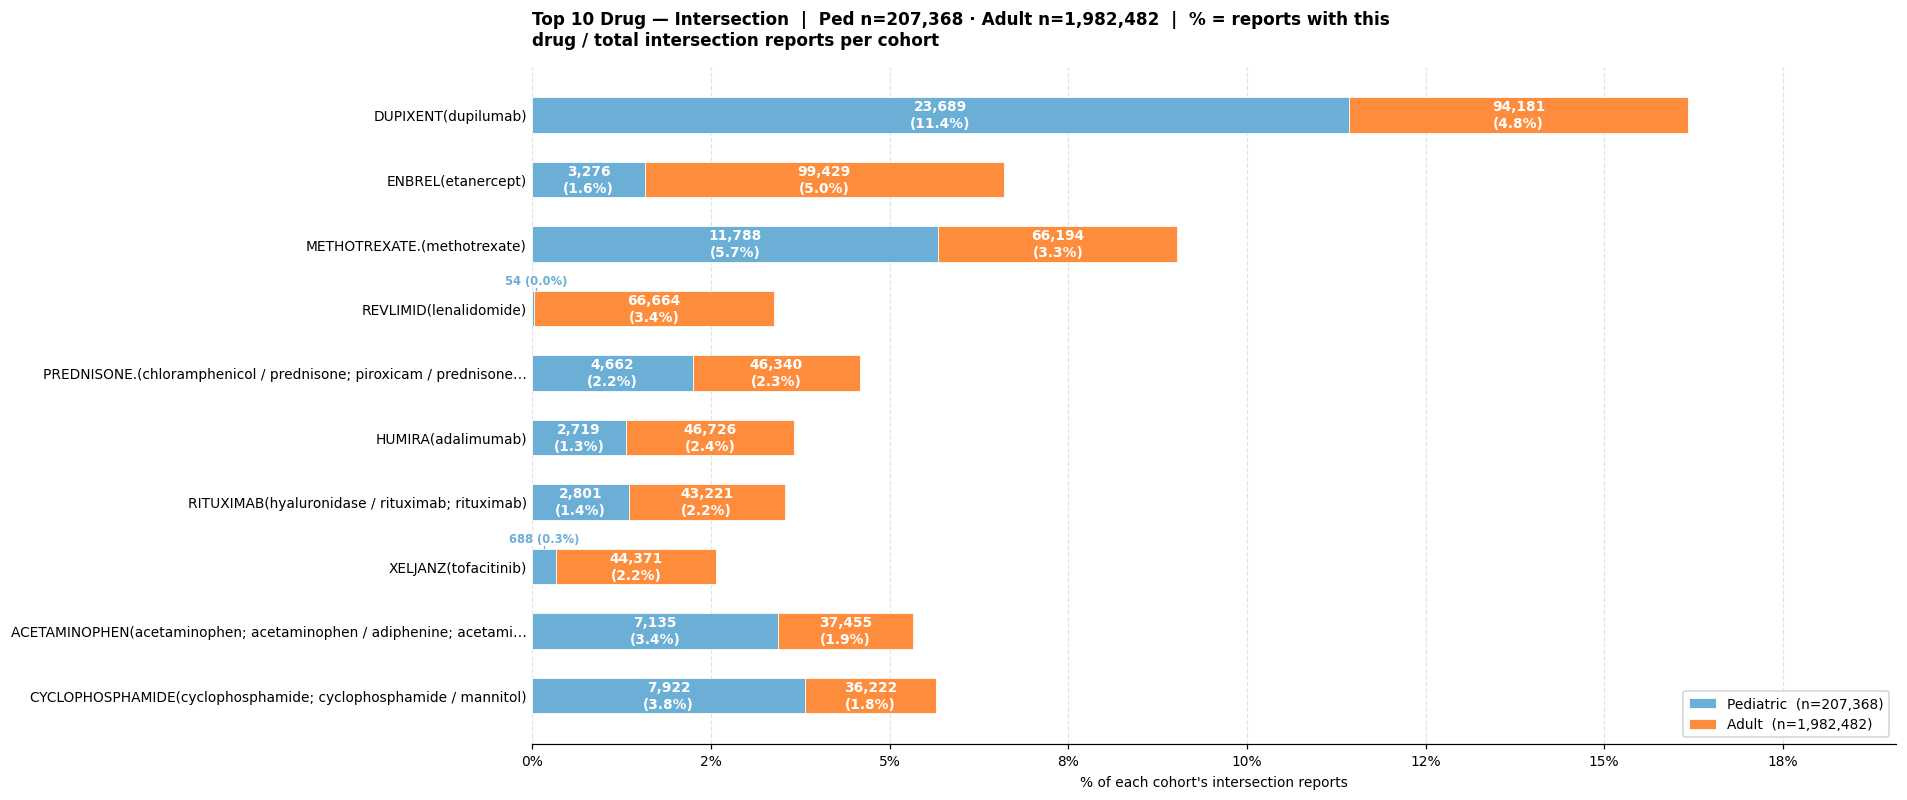

In [ ]:
# -- Section 5: Top 10 Drug from intersection dataset -------------------------
# df_ped_i / df_adu_i already in memory from Cell 38.

ped_drug = (
    df_ped_i.drop_duplicates(["safetyreportid","rxcui"])
    .groupby("rxcui", observed=True).size().reset_index(name="n_ped")
)
adu_drug = (
    df_adu_i.drop_duplicates(["safetyreportid","rxcui"])
    .groupby("rxcui", observed=True).size().reset_index(name="n_adu")
)
isect_drug = ped_drug.merge(adu_drug, on="rxcui", how="inner")
isect_drug["n_combined"] = isect_drug["n_ped"] + isect_drug["n_adu"]
isect_drug = (
    isect_drug.sort_values("n_combined", ascending=False)
    .head(N_INTERSECT).reset_index(drop=True)
)
isect_drug.insert(0, "rank", range(1, len(isect_drug)+1))

# Build display labels via fast groupby lookup
med_lkp, ing_lkp, _ = _label_lookups(df_ped_i, ["rxcui"], isect_drug)
isect_drug["display_label"] = isect_drug["rxcui"].apply(
    lambda r: f"{med_lkp.get(str(r),'(unknown)')}({ing_lkp.get(str(r),'(unknown)')})"
)
display(isect_drug[["rank","rxcui","display_label","n_ped","n_adu","n_combined"]])

ped_drug_total = df_ped_i["safetyreportid"].nunique()
adu_drug_total = df_adu_i["safetyreportid"].nunique()
print(f"Intersection  Ped: {ped_drug_total:,} | Adult: {adu_drug_total:,} distinct reports")

setup_plot_style()
_ld = isect_drug.assign(_lbl=isect_drug["display_label"].apply(lambda s: shorten_label(s, 65)))
fig, ax = plot_barh_intersection(
    _ld, term_col="_lbl", ped_col="n_ped", adu_col="n_adu",
    ped_denom=ped_drug_total, adu_denom=adu_drug_total,
    title=(
        f"Top {N_INTERSECT} Drug — Intersection  |  "
        f"Ped n={ped_drug_total:,} · Adult n={adu_drug_total:,}  |  "
        "% = reports with this drug / total intersection reports per cohort"
    ),
    figsize=(16, 8),
)
plt.savefig("output/figures/top10_drug_intersection.png", dpi=300, bbox_inches="tight")
plt.show()


# 6. Intersect Drug–ADR Pairs — Top 10 ที่พบร่วมกัน

**Helper:** `intersect_drug_adr_reports(df_ped, df_adu, n=10)`  
dedup ต่อ `(safetyreportid, rxcui, reaction_meddrapt)` ก่อนนับ

| คอลัมน์ | ความหมาย |
|---------|---------|
| `n_ped` | distinct reports (Pediatric) ที่รายงาน pair นี้ |
| `n_adu` | distinct reports (Adult) ที่รายงาน pair นี้ |
| `n_combined` | ผลรวม — ใช้เป็นเกณฑ์จัดอันดับ |
| `display_label` | `FAERS_name(RxNorm) — reaction_meddrapt` |

Pair ใน intersection = **สัญญาณ drug–ADR** ที่พบทั้งในเด็กและผู้ใหญ่  
→ มีนัยสำคัญสำหรับการออกคำเตือนและ label update

,rank,rxcui,reaction_meddrapt,display_label,n_ped,n_adu,n_combined
0,1,1876402,Pruritus,DUPIXENT(dupilumab) -- Pruritus,7205,24341,31546
1,2,1876402,Rash,DUPIXENT(dupilumab) -- Rash,4499,13420,17919
2,3,216891,Arthralgia,ENBREL(etanercept) -- Arthralgia,320,16284,16604
3,4,216891,Pain,ENBREL(etanercept) -- Pain,340,16158,16498
4,5,1876402,Eczema,DUPIXENT(dupilumab) -- Eczema,5150,9731,14881
5,6,2626,Neutropenia,CLOZAPINE(clozapine) -- Neutropenia,916,12910,13826
6,7,1492733,Diarrhoea,OTEZLA(apremilast) -- Diarrhoea,135,11840,11975
7,8,616011,Arthralgia,ORENCIA(abatacept) -- Arthralgia,141,10866,11007
8,9,6851,Pain,METHOTREXATE.(methotrexate) -- Pain,333,10455,10788
9,10,216891,Fatigue,ENBREL(etanercept) -- Fatigue,188,10561,10749


Intersection  Ped: 207,368 | Adult: 1,982,482 distinct reports


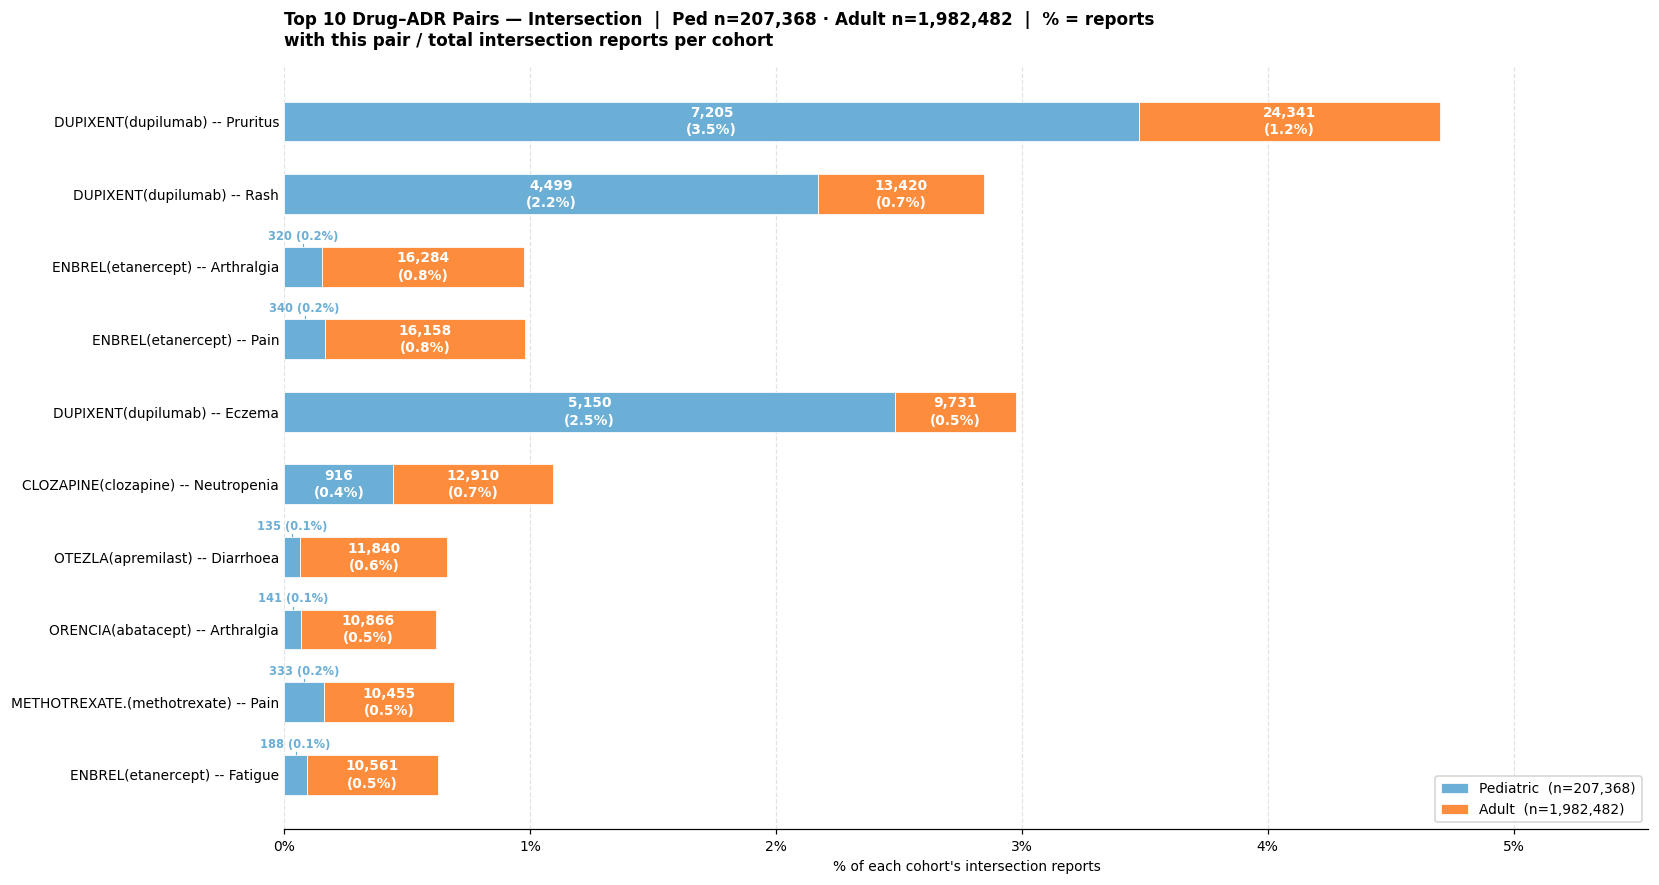

In [61]:
# -- Section 6: Top 10 Drug-ADR Pairs from intersection dataset ---------------
# df_ped_i / df_adu_i already in memory from Cell 38.

ped_pairs = (
    df_ped_i.drop_duplicates(["safetyreportid","rxcui","reaction_meddrapt"])
    .groupby(["rxcui","reaction_meddrapt"], observed=True).size().reset_index(name="n_ped")
)
adu_pairs = (
    df_adu_i.drop_duplicates(["safetyreportid","rxcui","reaction_meddrapt"])
    .groupby(["rxcui","reaction_meddrapt"], observed=True).size().reset_index(name="n_adu")
)
isect_pairs = ped_pairs.merge(adu_pairs, on=["rxcui","reaction_meddrapt"], how="inner")
isect_pairs["n_combined"] = isect_pairs["n_ped"] + isect_pairs["n_adu"]
isect_pairs = (
    isect_pairs.sort_values("n_combined", ascending=False)
    .head(N_INTERSECT).reset_index(drop=True)
)
isect_pairs.insert(0, "rank", range(1, len(isect_pairs)+1))

# Build display labels via fast groupby lookup
dedup_p = df_ped_i.drop_duplicates(["safetyreportid","rxcui","reaction_meddrapt"])
med_lkp, ing_lkp, _ = _label_lookups(dedup_p, ["rxcui","reaction_meddrapt"], isect_pairs)
def _key(row): return str(row["rxcui"]) + "||" + str(row["reaction_meddrapt"])
isect_pairs["display_label"] = isect_pairs.apply(
    lambda r: f"{med_lkp.get(_key(r),'(unknown)')}({ing_lkp.get(_key(r),'(unknown)')}) -- {r['reaction_meddrapt']}",
    axis=1
)
display(isect_pairs[["rank","rxcui","reaction_meddrapt","display_label","n_ped","n_adu","n_combined"]])

ped_pairs_total = df_ped_i["safetyreportid"].nunique()
adu_pairs_total = df_adu_i["safetyreportid"].nunique()
print(f"Intersection  Ped: {ped_pairs_total:,} | Adult: {adu_pairs_total:,} distinct reports")

setup_plot_style()
_lp = isect_pairs.assign(_lbl=isect_pairs["display_label"].apply(lambda s: shorten_label(s, 65)))
fig, ax = plot_barh_intersection(
    _lp, term_col="_lbl", ped_col="n_ped", adu_col="n_adu",
    ped_denom=ped_pairs_total, adu_denom=adu_pairs_total,
    title=(
        f"Top {N_INTERSECT} Drug–ADR Pairs — Intersection  |  "
        f"Ped n={ped_pairs_total:,} · Adult n={adu_pairs_total:,}  |  "
        "% = reports with this pair / total intersection reports per cohort"
    ),
    figsize=(16, 9),
)
plt.savefig("output/figures/top10_pairs_intersection.png", dpi=300, bbox_inches="tight")
plt.show()


---
## F.2 — Seriousness overview (intersection subset)

เหมือน **F.1** แต่ใช้เฉพาะแถวที่อยู่ใน **`df_ped_i` / `df_adu_i`** (คู่ `(rxcui, reaction_meddrapt)` ที่พบทั้งเด็กและผู้ใหญ่) — ต้องรัน cell สร้าง intersection ก่อน

- Top-5 ADR / Drug / Pair โดยนับรายงานที่มี **Death∪Hosp** แบบเดียวกับ F.1
- พล็อต Ped vs Adult + **NICHD** สำหรับ Top-5 ADR (Pediatric เท่านั้น)


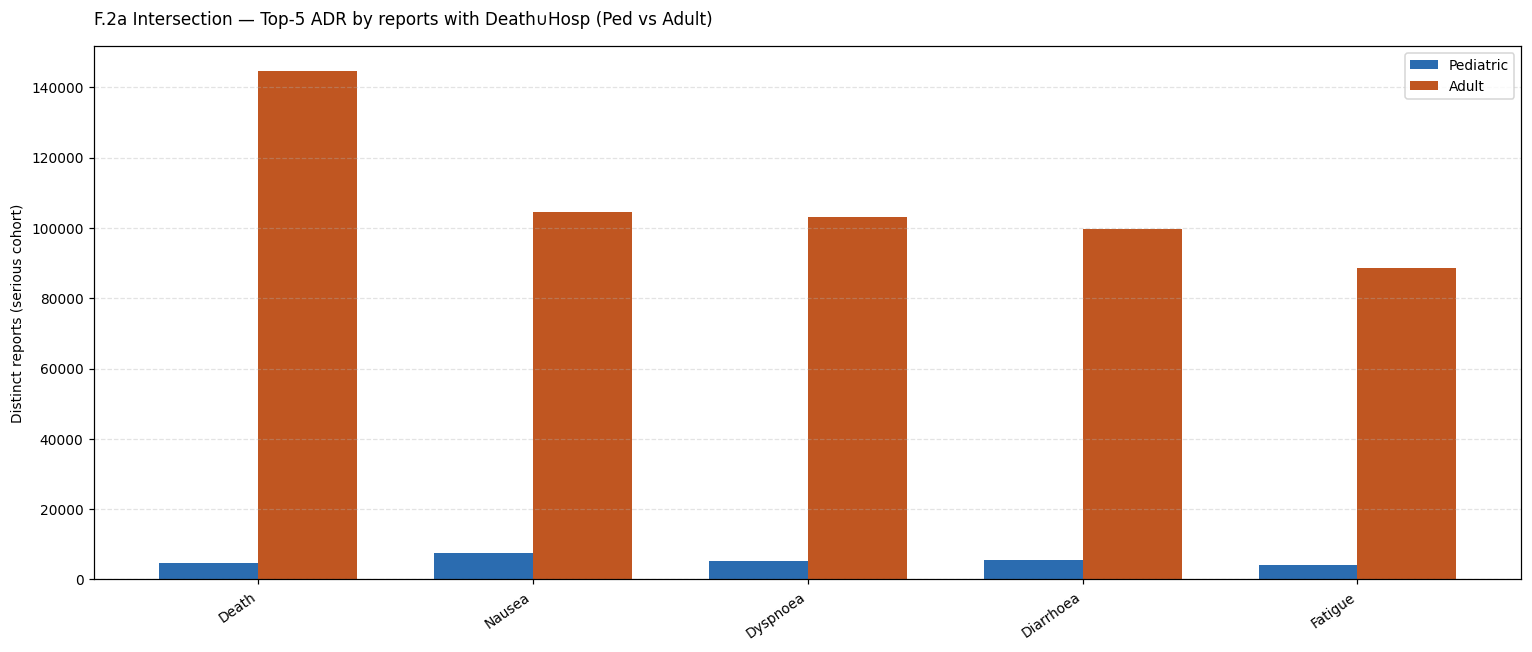

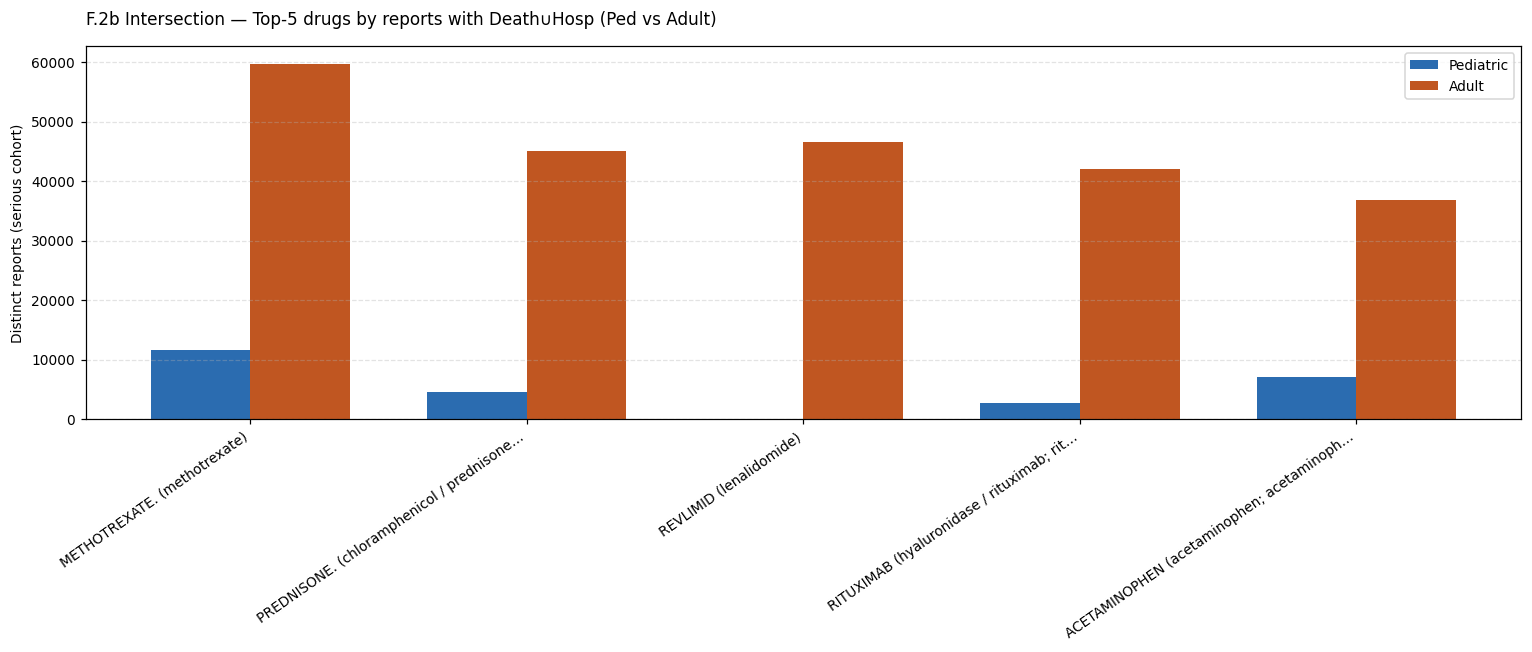

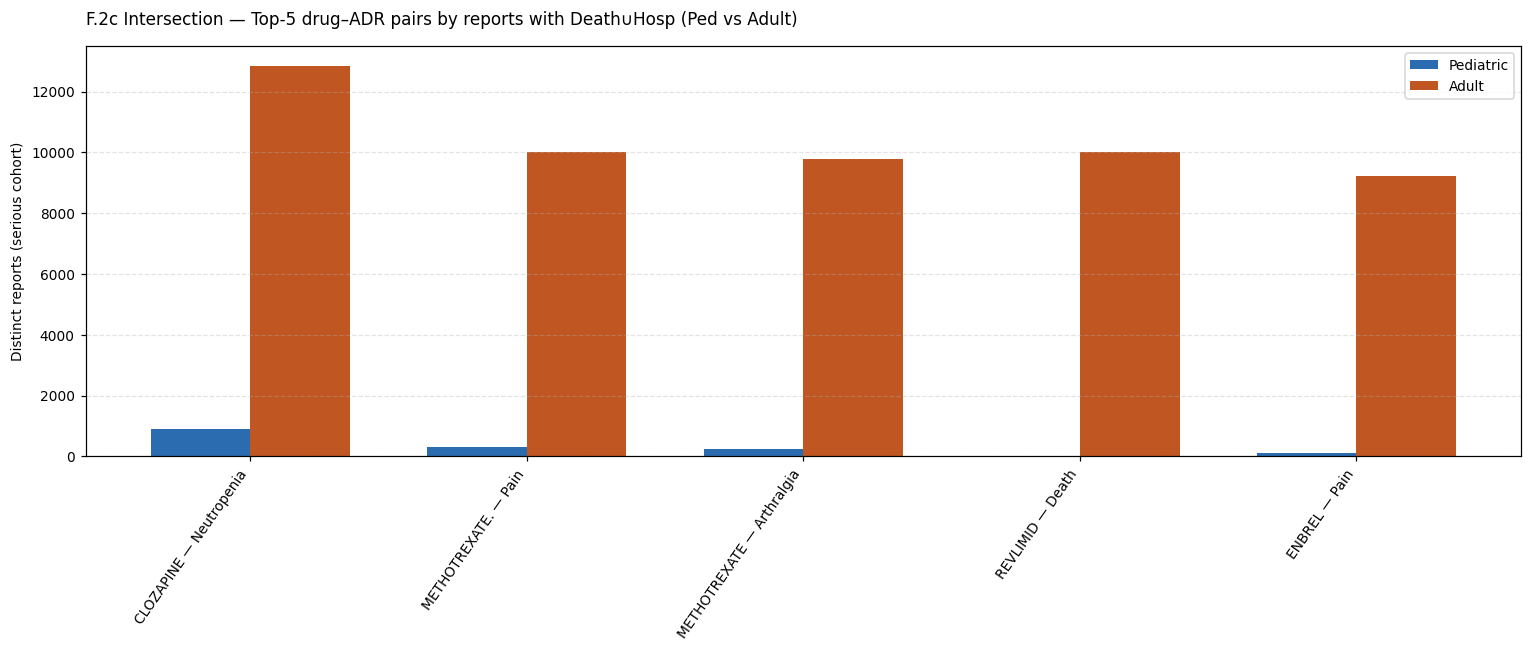

NameError: name '_mask_death_or_hosp' is not defined

In [109]:
# Requires df_ped_i, df_adu_i from intersection build cell
assert "df_ped_i" in dir() and "df_adu_i" in dir(), "Run intersection build cell first."

s_pi_adr = _series_top5_adr(df_ped_i)
s_ai_adr = _series_top5_adr(df_adu_i)
s_pi_rx = _series_top5_drug(df_ped_i)
s_ai_rx = _series_top5_drug(df_adu_i)
s_pi_pr = _series_top5_pair(df_ped_i)
s_ai_pr = _series_top5_pair(df_adu_i)

m_i_adr = _align_top5(s_pi_adr, s_ai_adr)
m_i_rx = _align_top5(s_pi_rx, s_ai_rx)
m_i_pr = _align_top5(s_pi_pr, s_ai_pr)

_plot_grouped_ped_adu(
    m_i_adr,
    list(m_i_adr.index),
    "F.2a Intersection — Top-5 ADR by reports with Death∪Hosp (Ped vs Adult)",
    "seriousness_f2_top5_adr_intersection.png",
)

top_rx_i = pd.DataFrame({"rxcui": m_i_rx.index.astype(str)})
ded_pi = df_ped_i.drop_duplicates(["safetyreportid", "rxcui"])
med_li, ing_li, _ = _label_lookups(ded_pi, ["rxcui"], top_rx_i)
rx_lab_i = [
    shorten_label(f"{med_li.get(str(r), '(?)')} ({ing_li.get(str(r), '(?)')})", 42)
    for r in m_i_rx.index
]
_plot_grouped_ped_adu(
    m_i_rx,
    rx_lab_i,
    "F.2b Intersection — Top-5 drugs by reports with Death∪Hosp (Ped vs Adult)",
    "seriousness_f2_top5_drug_intersection.png",
)

pair_i_rows = [{"rxcui": a, "reaction_meddrapt": b} for a, b in m_i_pr.index]
pair_i_top = pd.DataFrame(pair_i_rows)
ded_pi_pr = df_ped_i.drop_duplicates(["safetyreportid", "rxcui", "reaction_meddrapt"])
med_pi, ing_pi, _ = _label_lookups(ded_pi_pr, ["rxcui", "reaction_meddrapt"], pair_i_top)
pr_lab_i = []
for _, row in pair_i_top.iterrows():
    k = str(row["rxcui"]) + "||" + str(row["reaction_meddrapt"])
    pr_lab_i.append(shorten_label(f"{med_pi.get(k, '(?)')} — {row['reaction_meddrapt']}", 48))

_plot_grouped_ped_adu(
    m_i_pr,
    pr_lab_i,
    "F.2c Intersection — Top-5 drug–ADR pairs by reports with Death∪Hosp (Ped vs Adult)",
    "seriousness_f2_top5_pair_intersection.png",
    x_rot=55,
)

# NICHD (intersection pediatric)
adr_i_list = list(m_i_adr.index)
sub_ni = df_ped_i.loc[
    _mask_death_or_hosp(df_ped_i) & df_ped_i["reaction_meddrapt"].isin(adr_i_list),
    ["safetyreportid", "reaction_meddrapt", "nichd"],
].drop_duplicates(["safetyreportid", "reaction_meddrapt"])

pivot_i = (
    sub_ni.dropna(subset=["nichd"])
    .groupby(["nichd", "reaction_meddrapt"], observed=True)
    .size()
    .unstack(fill_value=0)
    .reindex(NICHD_ORDER)
    .fillna(0)
    .astype(int)
)
for a in adr_i_list:
    if a not in pivot_i.columns:
        pivot_i[a] = 0
pivot_i = pivot_i[adr_i_list]

setup_plot_style()
fig, ax = plt.subplots(figsize=(14, 7))
x = np.arange(len(NICHD_ORDER))
w = 0.15
colors = plt.cm.tab10(np.linspace(0, 0.9, len(adr_i_list)))
for i, adr in enumerate(adr_i_list):
    ax.bar(x + (i - (len(adr_i_list) - 1) / 2) * w, pivot_i[adr].values, w, label=adr, color=colors[i])
ax.set_xticks(x)
ax.set_xticklabels(NICHD_X, fontsize=9)
ax.set_ylabel("Distinct reports (Death∪Hosp)")
ax.set_title(
    "F.2d Intersection — Top-5 ADR (Death∪Hosp): Pediatric NICHD subgroup",
    fontsize=11,
    loc="left",
)
ax.legend(title="ADR", fontsize=8, loc="upper right")
ax.grid(axis="y", linestyle="--", alpha=0.35)
plt.tight_layout()
plt.savefig(figures_dir / "seriousness_f2_top5_adr_nichd_intersection.png", dpi=300, bbox_inches="tight")
plt.show()

_i_adr_tbl = m_i_adr.reset_index()
_i_adr_tbl.columns = ["reaction_meddrapt", "n_ped", "n_adu", "n_tot"]
_i_adr_tbl.to_csv(csv_dir / "seriousness_f2_top5_adr_intersection.csv", index=False)
_i_rx_tbl = m_i_rx.reset_index()
_i_rx_tbl.columns = ["rxcui", "n_ped", "n_adu", "n_tot"]
_i_rx_tbl.to_csv(csv_dir / "seriousness_f2_top5_drug_intersection.csv", index=False)
_i_pr_tbl = m_i_pr.reset_index()
_i_pr_tbl.columns = ["rxcui", "reaction_meddrapt", "n_ped", "n_adu", "n_tot"]
_i_pr_tbl.to_csv(csv_dir / "seriousness_f2_top5_pair_intersection.csv", index=False)
pivot_i.to_csv(csv_dir / "seriousness_f2_top5_adr_nichd_intersection.csv")
print("Saved F.2 intersection figures + CSV.")


## F.3 — High–severe-rate ADRs (intersection): Severity Ped vs Adult & NICHD

เลือก **5 PT** จาก subset **intersection** (`df_ped_i` / `df_adu_i`) เพื่อให้เปรียบเทียบ **เด็ก vs ผู้ใหญ่** ได้บน **ชุดข้อมูลเดียวกัน** (คู่ `(rxcui, reaction_meddrapt)` ที่มีทั้งสอง cohort)

**เกณฑ์คัด PT**
- มีใน **ทั้ง** Pediatric และ Adult (ใน intersection) อย่างน้อย `MIN_REPORTS` รายงานต่อ cohort หลัง dedup `(safetyreportid, reaction_meddrapt)`
- เรียงตาม **min(% รุนแรง)** ระหว่างสอง cohort (ให้ทั้งคู่รุนแรงสูงใกล้เคียงกัน) แล้วตาม **ค่าเฉลี่ย %** และ **จำนวนรายงานรวม**
- **ระดับรุนแรง** = hierarchy เดียวกับกราฟ **1.3**: `death` → `life_threatening` → `hospitalization` → … → `other` → ไม่มี flag = **Non-serious**

**กราฟ**
1. **Ped vs Adult** — แต่ละ ADR หนึ่งรูป สองแผง (แท่งสีตาม severity 7 ระดับ)
2. **NICHD** — เฉพาะ Pediatric intersection; stacked severity ต่อ subgroup (เหมือน 1.3b)

**บันทึก:** `output/figures/seriousness_f3_*.png`, `output/csv/seriousness_f3_top5_hisev_adr_intersection.csv`

> ต้องรัน cell สร้าง intersection และ cell ที่นิยาม `setup_plot_style` (เช่น F.1) ก่อน


F.3 — Top-5 ADR (intersection), min n=100 per cohort, sort=min(%severe) then mean then n_sum:


,reaction_meddrapt,n_ped,n_severe_ped,pct_severe_ped,n_adu,n_severe_adu,pct_severe_adu,score_min_pct,score_mean_pct,n_sum
488,Hyperpyrexia,210,210,1.0,924,924,1.000000,1.000000,1.000000,1134
554,Hypoventilation,187,187,1.0,535,535,1.000000,1.000000,1.000000,722
110,Bezoar,120,120,1.0,429,429,1.000000,1.000000,1.000000,549
697,Myelopathy,116,116,1.0,362,362,1.000000,1.000000,1.000000,478
299,Encephalitis,356,356,1.0,1573,1572,0.999364,0.999364,0.999682,1929


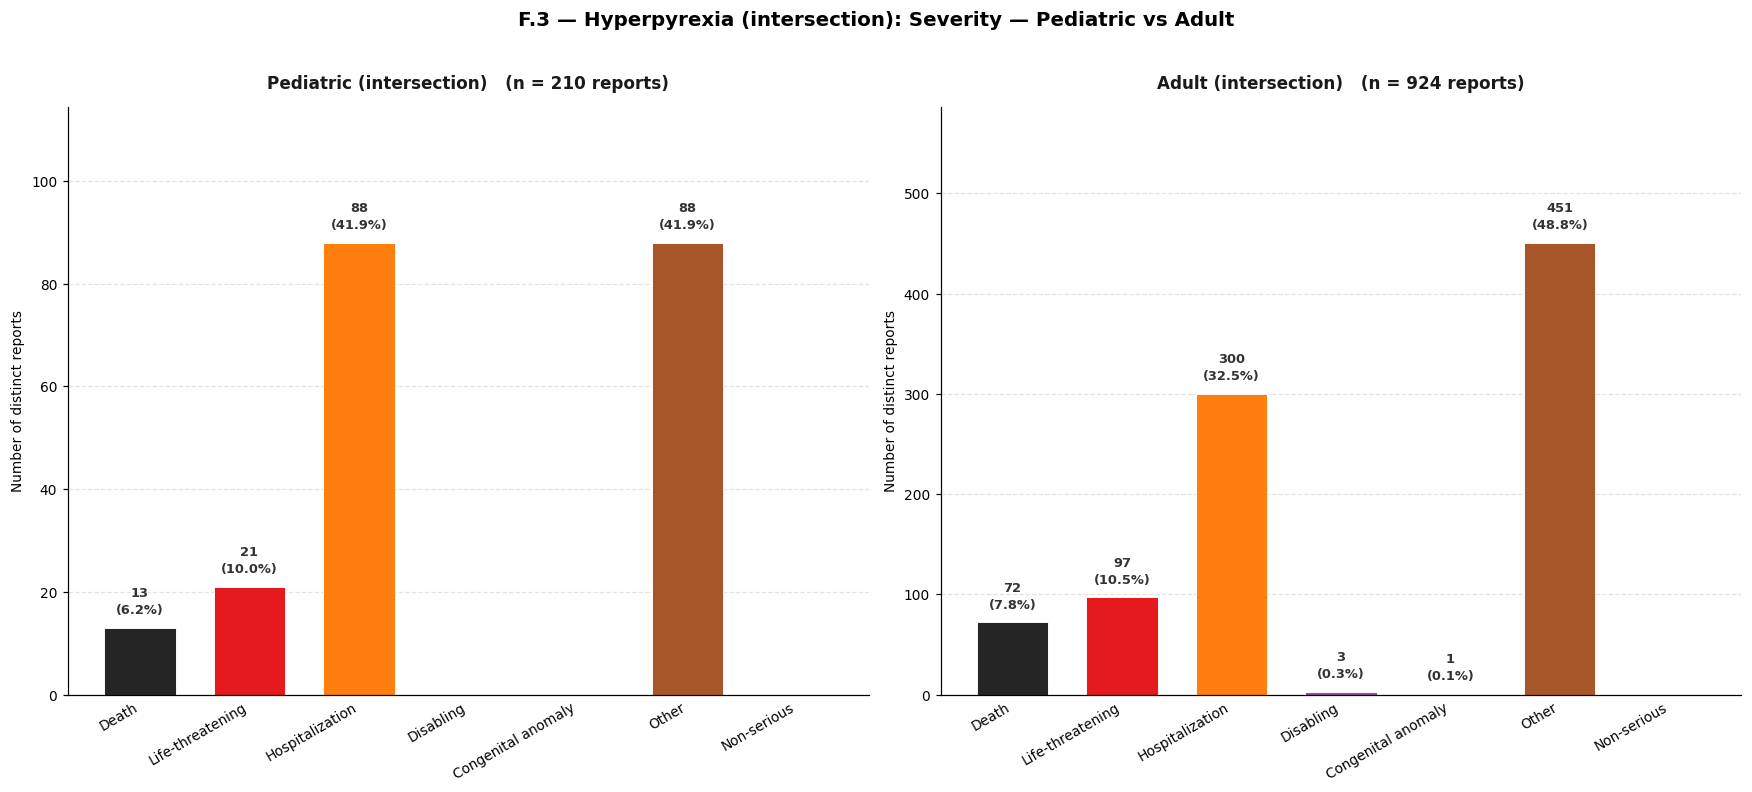

Saved: output/figures/seriousness_f3_severity_ped_vs_adult_hyperpyrexia.png


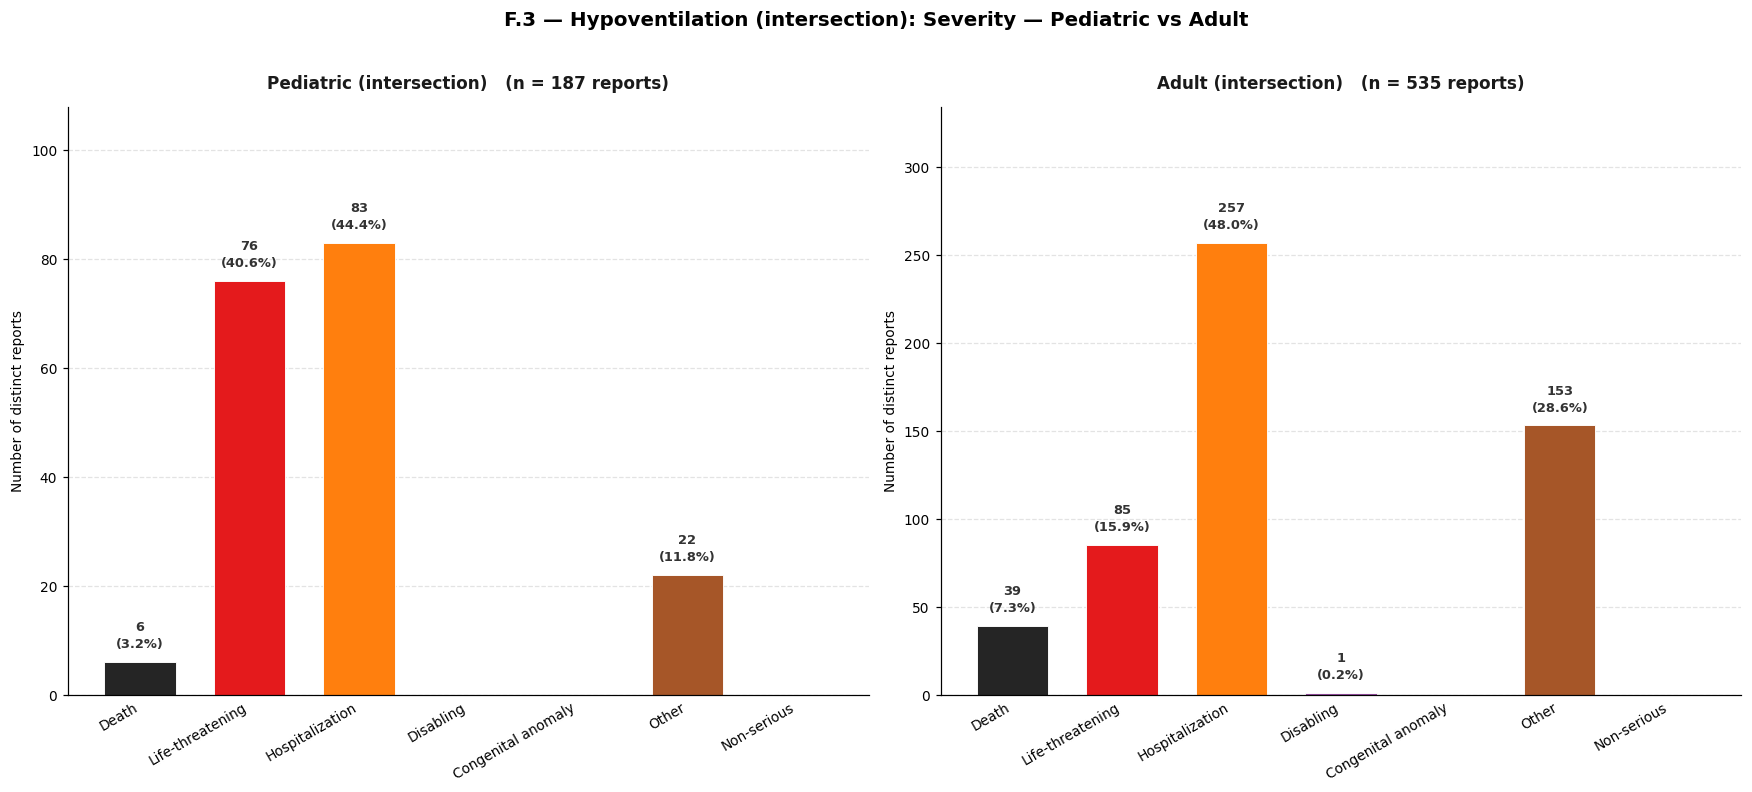

Saved: output/figures/seriousness_f3_severity_ped_vs_adult_hypoventilation.png


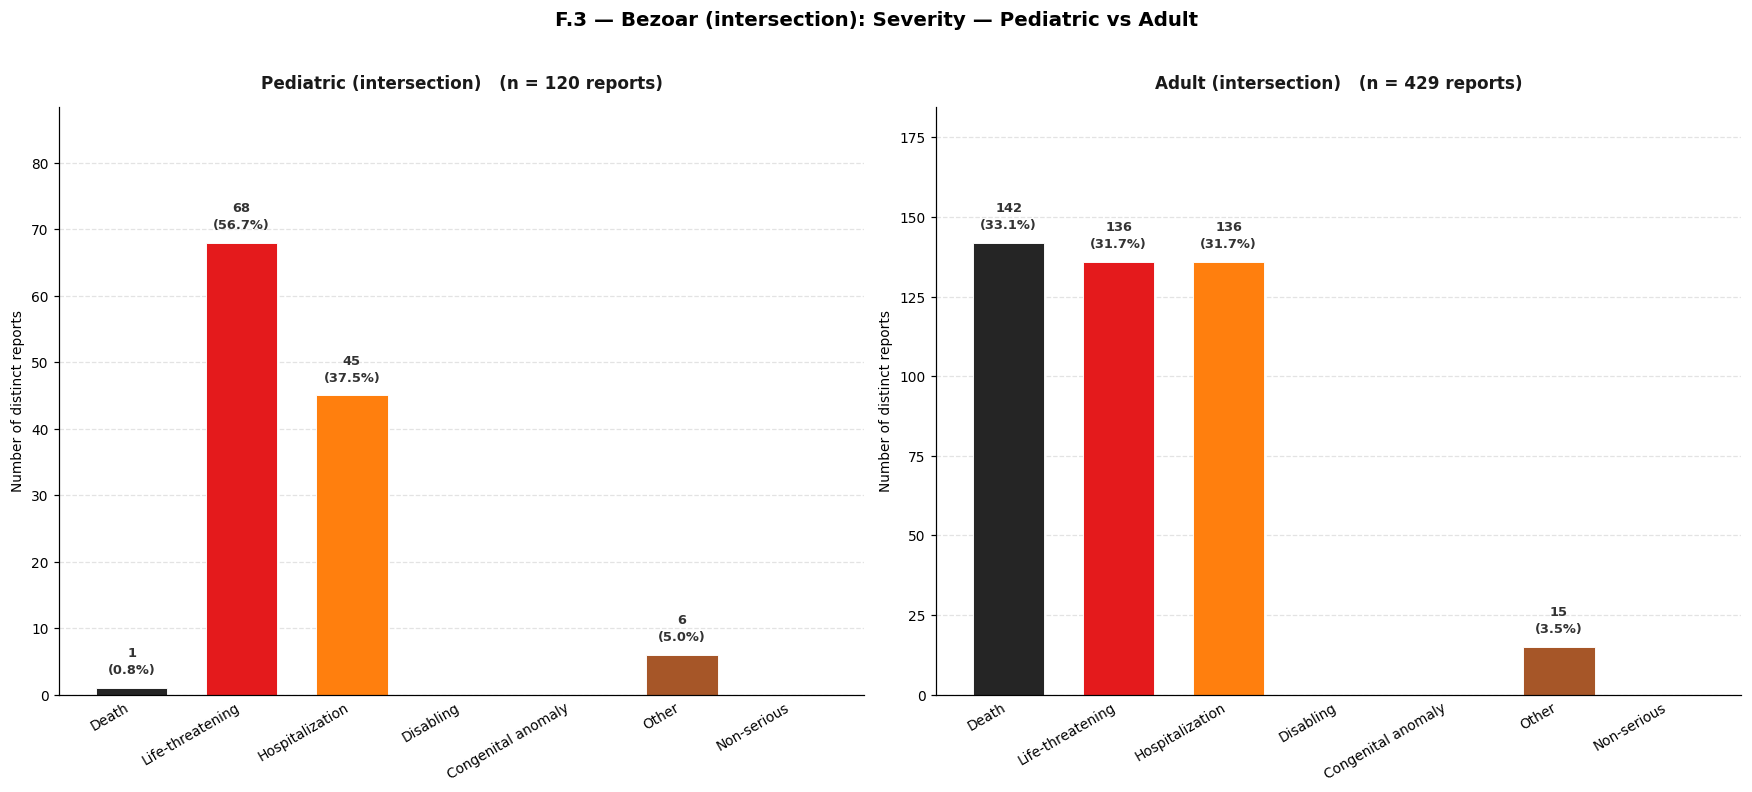

Saved: output/figures/seriousness_f3_severity_ped_vs_adult_bezoar.png


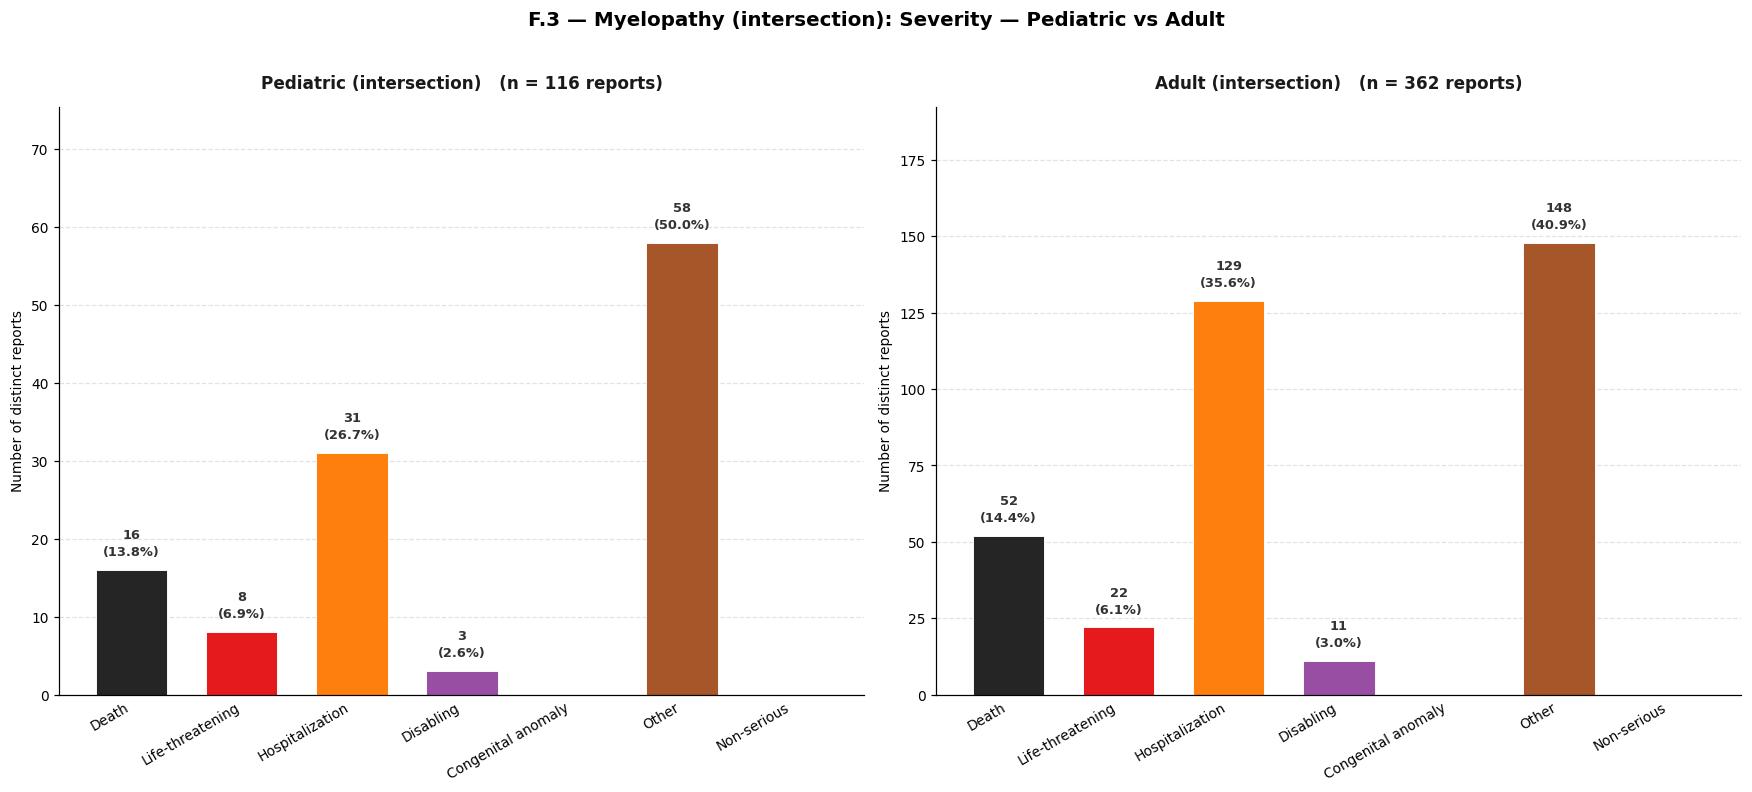

Saved: output/figures/seriousness_f3_severity_ped_vs_adult_myelopathy.png


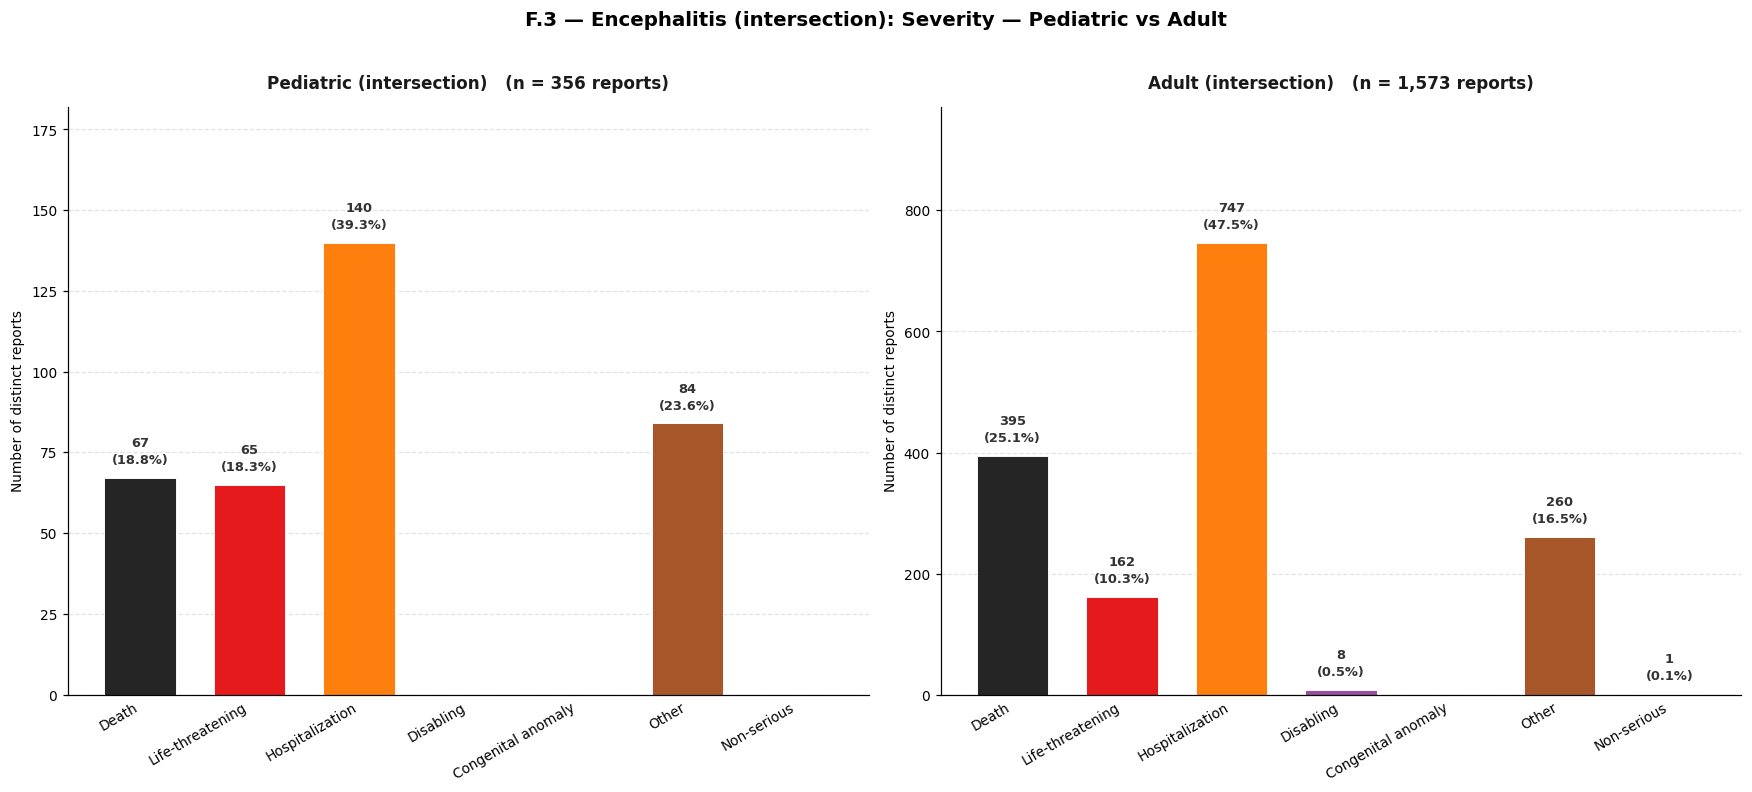

Saved: output/figures/seriousness_f3_severity_ped_vs_adult_encephalitis.png


/tmp/ipykernel_1115303/1252116093.py:302: UserWarning: Setting the 'color' property will override the edgecolor or facecolor properties.
  plt.Rectangle((0, 0), 1, 1, color=c, edgecolor="none")


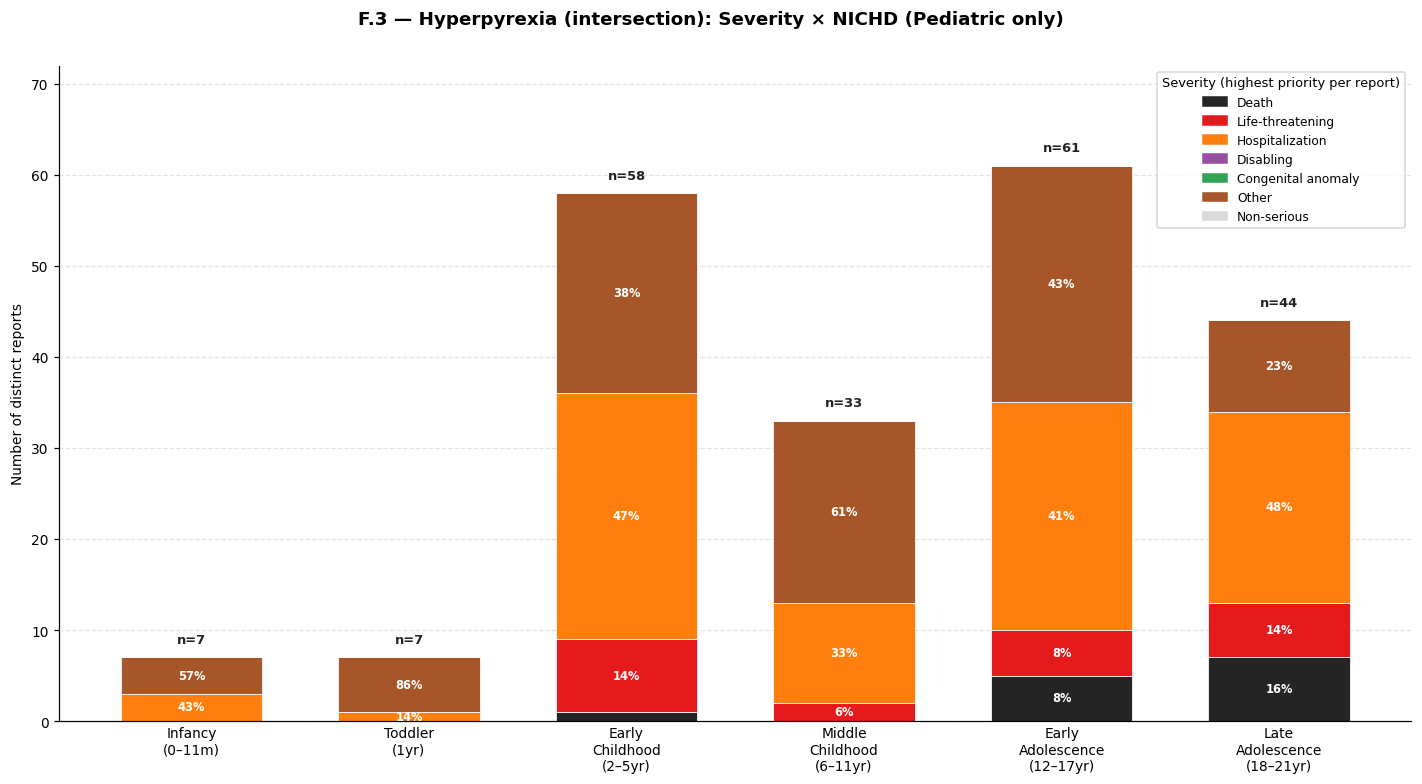

Saved: output/figures/seriousness_f3_severity_nichd_hyperpyrexia.png


/tmp/ipykernel_1115303/1252116093.py:302: UserWarning: Setting the 'color' property will override the edgecolor or facecolor properties.
  plt.Rectangle((0, 0), 1, 1, color=c, edgecolor="none")


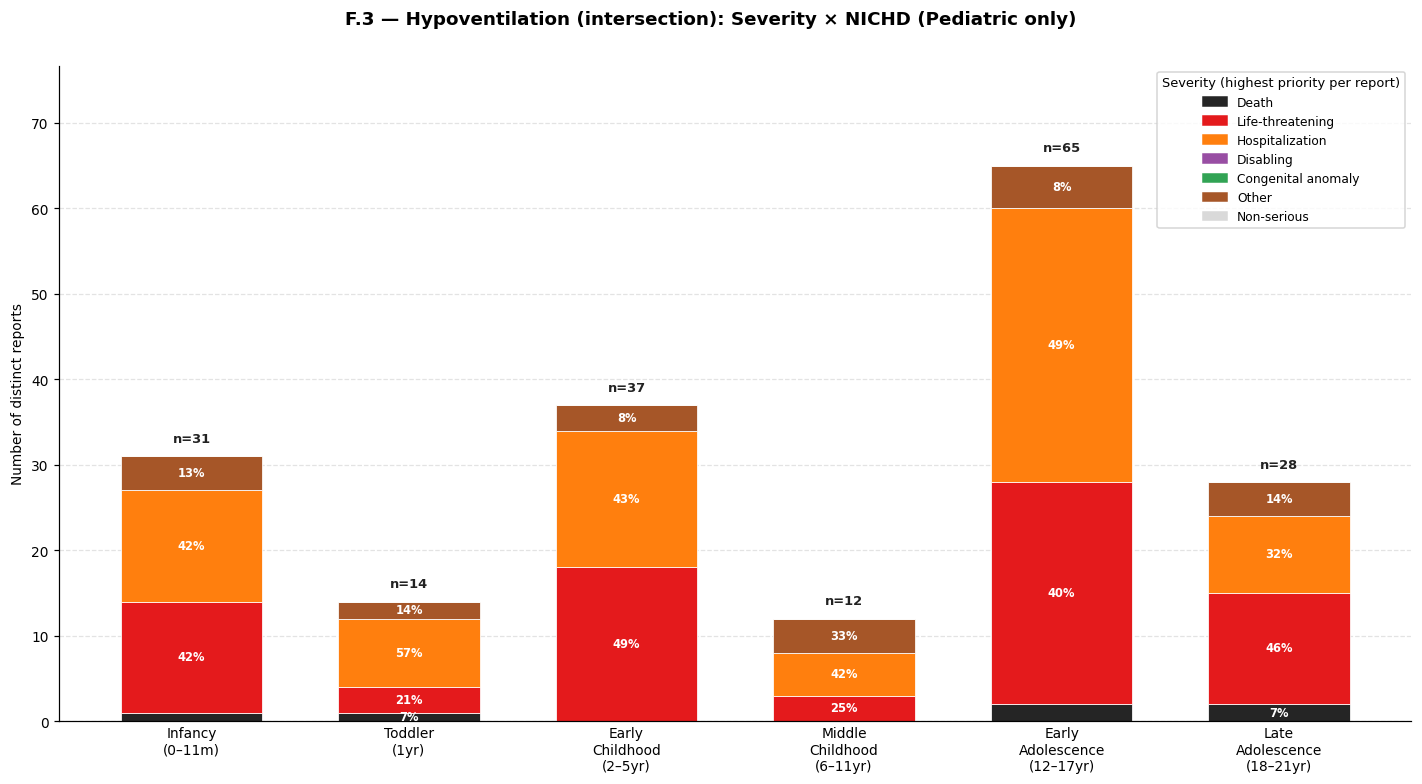

Saved: output/figures/seriousness_f3_severity_nichd_hypoventilation.png


/tmp/ipykernel_1115303/1252116093.py:302: UserWarning: Setting the 'color' property will override the edgecolor or facecolor properties.
  plt.Rectangle((0, 0), 1, 1, color=c, edgecolor="none")


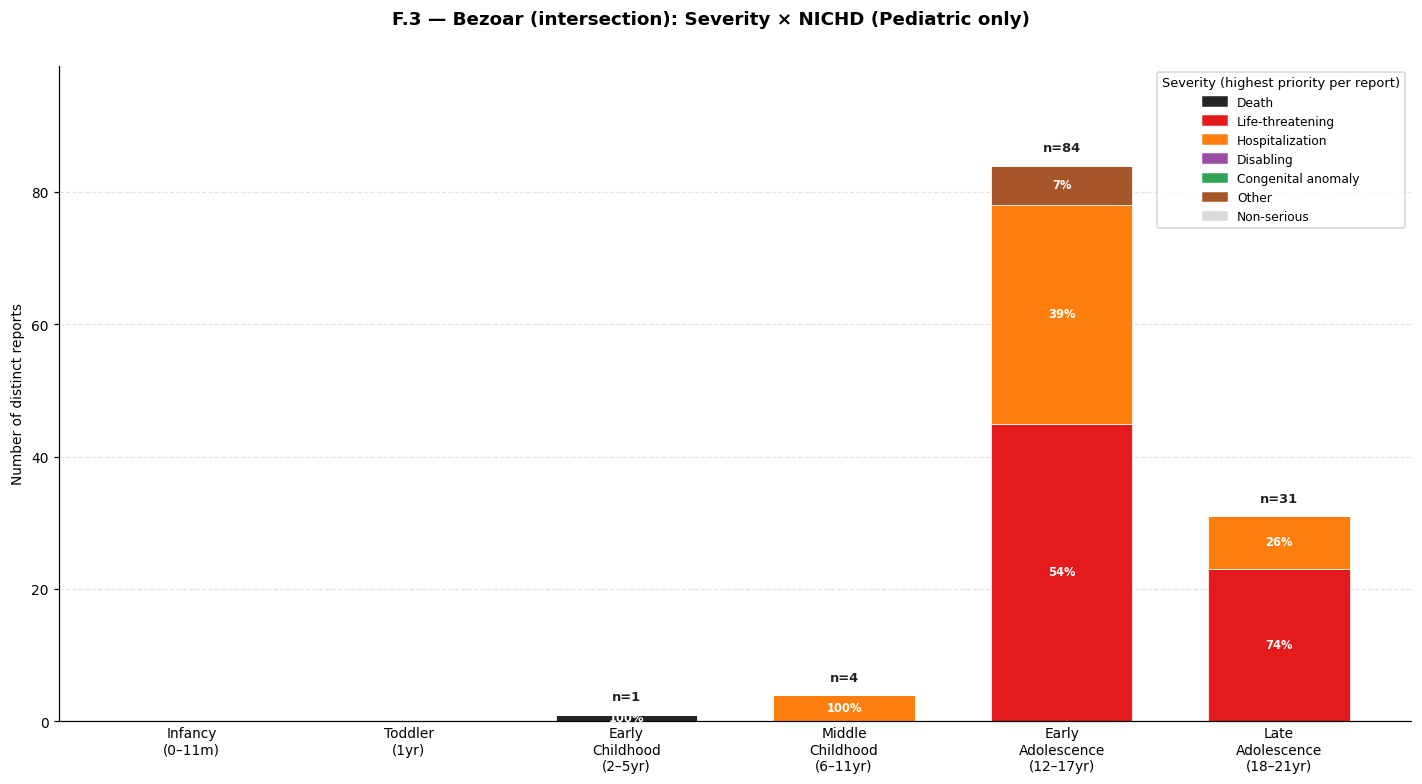

Saved: output/figures/seriousness_f3_severity_nichd_bezoar.png


/tmp/ipykernel_1115303/1252116093.py:302: UserWarning: Setting the 'color' property will override the edgecolor or facecolor properties.
  plt.Rectangle((0, 0), 1, 1, color=c, edgecolor="none")


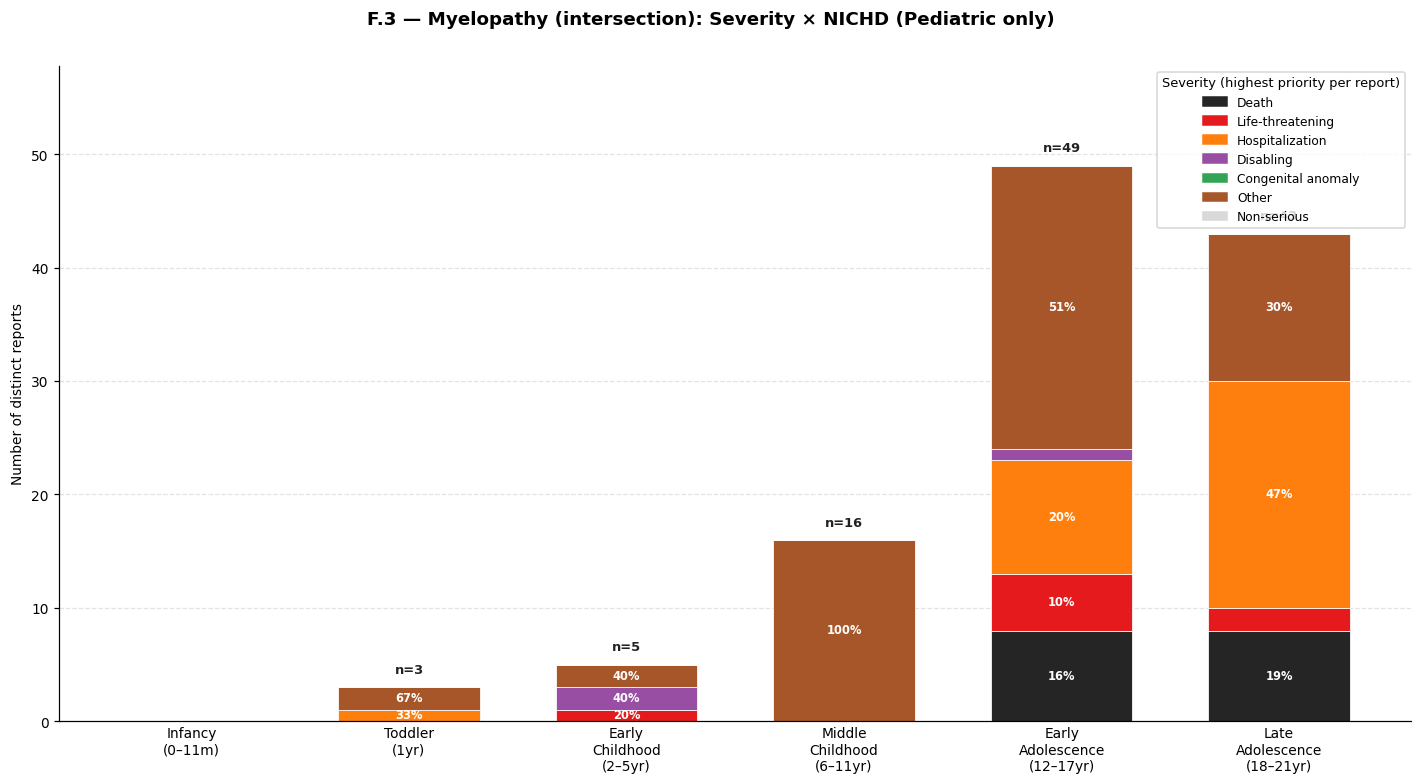

Saved: output/figures/seriousness_f3_severity_nichd_myelopathy.png


/tmp/ipykernel_1115303/1252116093.py:302: UserWarning: Setting the 'color' property will override the edgecolor or facecolor properties.
  plt.Rectangle((0, 0), 1, 1, color=c, edgecolor="none")


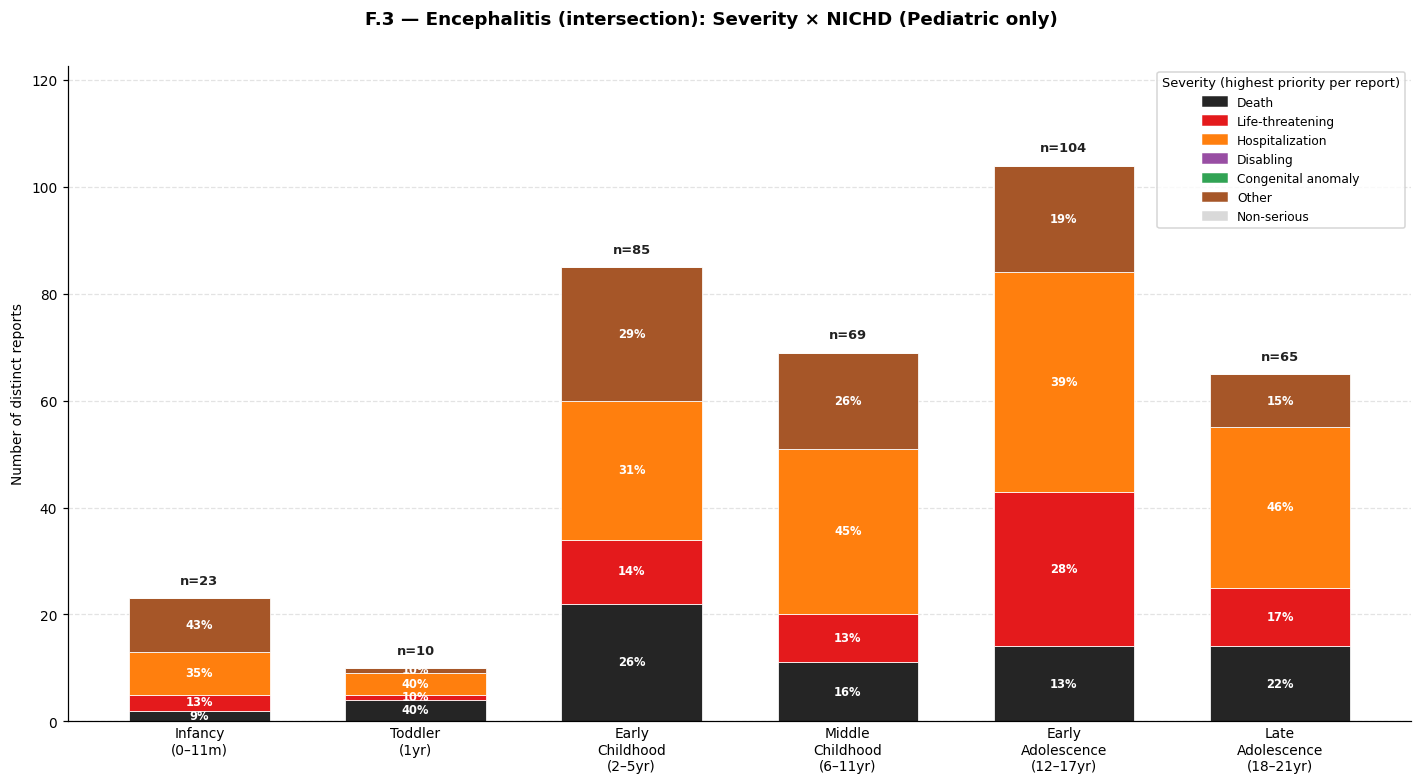

Saved: output/figures/seriousness_f3_severity_nichd_encephalitis.png
Saved CSV: output/csv/seriousness_f3_top5_hisev_adr_intersection.csv


In [116]:

# ── F.3 — Severity profiles for top “high severe %” ADRs (intersection) ─────
import re
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path

assert "df_ped_i" in dir() and "df_adu_i" in dir(), "Run intersection build cell first."
assert "setup_plot_style" in dir(), "Run a cell that defines setup_plot_style (e.g. F.1)."

MIN_REPORTS_F3 = 100
N_TOP_F3 = 5

SEV_COLS_F3 = [
    "death",
    "life_threatening",
    "hospitalization",
    "disabling",
    "congenital_anomali",
    "other",
]
SEV_LABELS_F3 = [
    "Death",
    "Life-threatening",
    "Hospitalization",
    "Disabling",
    "Congenital anomaly",
    "Other",
    "Non-serious",
]
SEV_COLORS_F3 = [
    "#252525",
    "#e41a1c",
    "#ff7f0e",
    "#984ea3",
    "#31a354",
    "#a65628",
    "#d9d9d9",
]

NICHD_ORDER_F3 = [
    "infancy",
    "toddler",
    "early_childhood",
    "middle_childhood",
    "early_adolescence",
    "late_adolescence",
]
NICHD_LABELS_F3 = [
    "Infancy\n(0–11m)",
    "Toddler\n(1yr)",
    "Early\nChildhood\n(2–5yr)",
    "Middle\nChildhood\n(6–11yr)",
    "Early\nAdolescence\n(12–17yr)",
    "Late\nAdolescence\n(18–21yr)",
]


def _safe_fname_part(s: str, max_len: int = 48) -> str:
    s = re.sub(r"[^a-zA-Z0-9]+", "_", str(s).strip().lower())
    s = s.strip("_")[:max_len] or "adr"
    return s


def _cohort_adr_severity_stats(df: pd.DataFrame) -> pd.DataFrame:
    rows = []
    for pt, g in df.groupby("reaction_meddrapt", observed=True):
        u = g.drop_duplicates(["safetyreportid", "reaction_meddrapt"]).copy()
        if u.empty:
            continue
        conds = [u[c].fillna(0).astype(int) == 1 for c in SEV_COLS_F3]
        sev = np.select(conds, SEV_LABELS_F3[:-1], default="Non-serious")
        n = len(u)
        severe = int((sev != "Non-serious").sum())
        rows.append(
            {
                "reaction_meddrapt": pt,
                "n": n,
                "n_severe": severe,
                "pct_severe": severe / n if n else 0.0,
            }
        )
    return pd.DataFrame(rows)


ped_st = _cohort_adr_severity_stats(df_ped_i)
adu_st = _cohort_adr_severity_stats(df_adu_i)
rank_tbl = ped_st.merge(adu_st, on="reaction_meddrapt", suffixes=("_ped", "_adu"))
rank_tbl = rank_tbl[
    (rank_tbl["n_ped"] >= MIN_REPORTS_F3) & (rank_tbl["n_adu"] >= MIN_REPORTS_F3)
].copy()
rank_tbl["score_min_pct"] = rank_tbl[["pct_severe_ped", "pct_severe_adu"]].min(axis=1)
rank_tbl["score_mean_pct"] = (
    rank_tbl["pct_severe_ped"] + rank_tbl["pct_severe_adu"]
) / 2
rank_tbl["n_sum"] = rank_tbl["n_ped"] + rank_tbl["n_adu"]
rank_tbl = rank_tbl.sort_values(
    ["score_min_pct", "score_mean_pct", "n_sum"],
    ascending=[False, False, False],
).head(N_TOP_F3)

if rank_tbl.empty:
    raise RuntimeError(
        "F.3: no PT with ≥ MIN_REPORTS_F3 reports in both Ped and Adult intersection. "
        "Lower MIN_REPORTS_F3 if needed."
    )

ADR_FOCUS_INTERSECT_HISEV = list(rank_tbl["reaction_meddrapt"])
print(
    "F.3 — Top-%d ADR (intersection), min n=%d per cohort, sort=min(%%severe) then mean then n_sum:"
    % (N_TOP_F3, MIN_REPORTS_F3)
)
display(rank_tbl)


def _sev_profile_f3(df: pd.DataFrame, adrs: list) -> pd.DataFrame:
    sub = (
        df[df["reaction_meddrapt"].isin(adrs)]
        .drop_duplicates(["safetyreportid", "reaction_meddrapt"])
        .copy()
    )
    conds = [sub[c].fillna(0).astype(int) == 1 for c in SEV_COLS_F3]
    sub["_sev"] = np.select(conds, SEV_LABELS_F3[:-1], default="Non-serious")
    return (
        sub.groupby(["reaction_meddrapt", "_sev"], observed=True)
        .size()
        .reset_index(name="n_reports")
    )


sev_ped_f3 = _sev_profile_f3(df_ped_i, ADR_FOCUS_INTERSECT_HISEV)
sev_adu_f3 = _sev_profile_f3(df_adu_i, ADR_FOCUS_INTERSECT_HISEV)

figures_dir = Path("../data/notebook/output/top_terms_adult/figures")
csv_dir = Path("../data/notebook/output/top_terms_adult/csv")
figures_dir.mkdir(parents=True, exist_ok=True)
csv_dir.mkdir(parents=True, exist_ok=True)

setup_plot_style()

# ── 1) Pediatric vs Adult (same layout as graph 1.3) ──────────────────────────
for adr in ADR_FOCUS_INTERSECT_HISEV:
    ped_s = sev_ped_f3[sev_ped_f3["reaction_meddrapt"] == adr].set_index("_sev")["n_reports"]
    adu_s = sev_adu_f3[sev_adu_f3["reaction_meddrapt"] == adr].set_index("_sev")["n_reports"]
    pv = pd.Series({s: int(ped_s.get(s, 0)) for s in SEV_LABELS_F3})
    av = pd.Series({s: int(adu_s.get(s, 0)) for s in SEV_LABELS_F3})
    pt, at = int(pv.sum()), int(av.sum())

    fig, axes = plt.subplots(1, 2, figsize=(16, 7), sharey=False)
    fig.suptitle(
        f"F.3 — {adr} (intersection): Severity — Pediatric vs Adult",
        fontsize=13,
        fontweight="bold",
        y=1.02,
    )

    cohorts = [
        (axes[0], pv, pt, "Pediatric (intersection)", "#4292C6"),
        (axes[1], av, at, "Adult (intersection)", "#E6550D"),
    ]

    for ax, vals, total, cohort_name, _bar_color in cohorts:
        x = np.arange(len(SEV_LABELS_F3))
        bars = ax.bar(
            x,
            vals.values,
            color=SEV_COLORS_F3,
            edgecolor="white",
            linewidth=0.6,
            width=0.65,
        )
        y_max = float(vals.max()) if vals.max() > 0 else 1.0
        for bar, v in zip(bars, vals.values):
            pct = 100.0 * v / total if total > 0 else 0.0
            if v > 0:
                ax.text(
                    bar.get_x() + bar.get_width() / 2,
                    bar.get_height() + y_max * 0.025,
                    f"{v:,}\n({pct:.1f}%)",
                    ha="center",
                    va="bottom",
                    fontsize=8.5,
                    fontweight="bold",
                    color="#333333",
                    linespacing=1.4,
                )
        ax.set_title(
            f"{cohort_name}   (n = {total:,} reports)",
            fontsize=11,
            fontweight="bold",
            pad=12,
            color="#1a1a1a",
        )
        ax.set_xticks(x)
        ax.set_xticklabels(SEV_LABELS_F3, rotation=30, ha="right", fontsize=9)
        ax.set_ylabel("Number of distinct reports", fontsize=9)
        ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda v, _: f"{int(v):,}"))
        ax.set_ylim(0, y_max * 1.30)
        ax.spines["top"].set_visible(False)
        ax.spines["right"].set_visible(False)
        ax.tick_params(axis="x", length=0)
        ax.grid(axis="y", linestyle="--", alpha=0.35, zorder=0)
        ax.set_axisbelow(True)

    plt.tight_layout()
    fn = figures_dir / (
        "seriousness_f3_severity_ped_vs_adult_" + _safe_fname_part(adr) + ".png"
    )
    plt.savefig(fn, dpi=150, bbox_inches="tight")
    plt.show()
    print("Saved:", fn)


# ── 2) NICHD stacked (Pediatric intersection only; same as 1.3b) ─────────────
def _nichd_sev_pivot_f3(df: pd.DataFrame, adr: str) -> pd.DataFrame:
    sub = (
        df[df["reaction_meddrapt"] == adr]
        .drop_duplicates(subset=["safetyreportid"])
        .copy()
    )
    conds = [sub[c].fillna(0).astype(int) == 1 for c in SEV_COLS_F3]
    sub["_sev"] = np.select(conds, SEV_LABELS_F3[:-1], default="Non-serious")
    pivot = (
        sub.groupby(["nichd", "_sev"], observed=True)
        .size()
        .unstack(fill_value=0)
        .reindex(index=NICHD_ORDER_F3, columns=SEV_LABELS_F3, fill_value=0)
    )
    return pivot


for adr in ADR_FOCUS_INTERSECT_HISEV:
    pivot = _nichd_sev_pivot_f3(df_ped_i, adr)
    totals = pivot.sum(axis=1).values

    fig, ax = plt.subplots(figsize=(13, 7))
    fig.suptitle(
        f"F.3 — {adr} (intersection): Severity × NICHD (Pediatric only)",
        fontsize=12,
        fontweight="bold",
        y=1.01,
    )

    x = np.arange(len(NICHD_ORDER_F3))
    bot = np.zeros(len(NICHD_ORDER_F3))

    ymax = 1.0
    for sev, color in zip(SEV_LABELS_F3, SEV_COLORS_F3):
        vals = pivot[sev].values.astype(float)
        ax.bar(
            x,
            vals,
            bottom=bot,
            color=color,
            edgecolor="white",
            linewidth=0.5,
            width=0.65,
            label=sev,
        )
        for xi, (v, b, tot) in enumerate(zip(vals, bot, totals)):
            pct = 100.0 * v / tot if tot > 0 else 0.0
            if pct >= 5 and v > 0:
                ax.text(
                    xi,
                    b + v / 2,
                    f"{pct:.0f}%",
                    ha="center",
                    va="center",
                    fontsize=7.5,
                    fontweight="bold",
                    color="white",
                )
        bot += vals

    bar_top = bot
    ymax = float(bar_top.max()) if bar_top.max() > 0 else 1.0
    for xi, (total, top) in enumerate(zip(totals, bar_top)):
        if total > 0:
            ax.text(
                xi,
                top + ymax * 0.02,
                f"n={int(total):,}",
                ha="center",
                va="bottom",
                fontsize=8.5,
                fontweight="bold",
                color="#222222",
            )

    ax.set_xticks(x)
    ax.set_xticklabels(NICHD_LABELS_F3, fontsize=9)
    ax.set_ylabel("Number of distinct reports", fontsize=9)
    ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda v, _: f"{int(v):,}"))
    ax.set_ylim(0, ymax * 1.18)
    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)
    ax.tick_params(axis="x", length=0)
    ax.grid(axis="y", linestyle="--", alpha=0.35, zorder=0)
    ax.set_axisbelow(True)

    handles = [
        plt.Rectangle((0, 0), 1, 1, color=c, edgecolor="none")
        for c in SEV_COLORS_F3
    ]
    ax.legend(
        handles,
        SEV_LABELS_F3,
        title="Severity (highest priority per report)",
        loc="upper right",
        ncol=1,
        fontsize=8,
        title_fontsize=8.5,
        frameon=True,
        edgecolor="#cccccc",
    )

    plt.tight_layout()
    fn = figures_dir / (
        "seriousness_f3_severity_nichd_" + _safe_fname_part(adr) + ".png"
    )
    plt.savefig(fn, dpi=150, bbox_inches="tight")
    plt.show()
    print("Saved:", fn)

rank_tbl.to_csv(csv_dir / "seriousness_f3_top5_hisev_adr_intersection.csv", index=False)
print("Saved CSV:", csv_dir / "seriousness_f3_top5_hisev_adr_intersection.csv")


---

## C.1 — Severity Distribution: Vomiting & Rash (Intersection dataset)

ทำซ้ำ **กราฟ 1.3** แต่ใช้ **intersection dataset** (`df_ped_i` / `df_adu_i`)  
เฉพาะ reports ที่มี (drug, ADR) pair ปรากฏในทั้ง Pediatric และ Adult

> **ประโยชน์:** เปรียบเทียบ severity ของ ADR เดียวกันในชุดข้อมูลที่ควบคุม drug exposure ให้ตรงกันระหว่าง cohort  
> ถ้า severity ยัง different อยู่ → แสดงว่าความแตกต่างเกิดจาก patient factor ไม่ใช่ drug selection

> **ต้องรัน cell สร้าง intersection (Section C build) ก่อน** เพื่อให้ `df_ped_i` / `df_adu_i` พร้อมใช้

Intersection subset:  Pediatric 207,368 reports | Adult 1,982,482 reports


/tmp/ipykernel_1115303/955451631.py:94: UserWarning: Setting the 'color' property will override the edgecolor or facecolor properties.
  handles = [plt.Rectangle((0, 0), 1, 1, color=c, edgecolor="none") for c in _CI_SEV_COLORS]


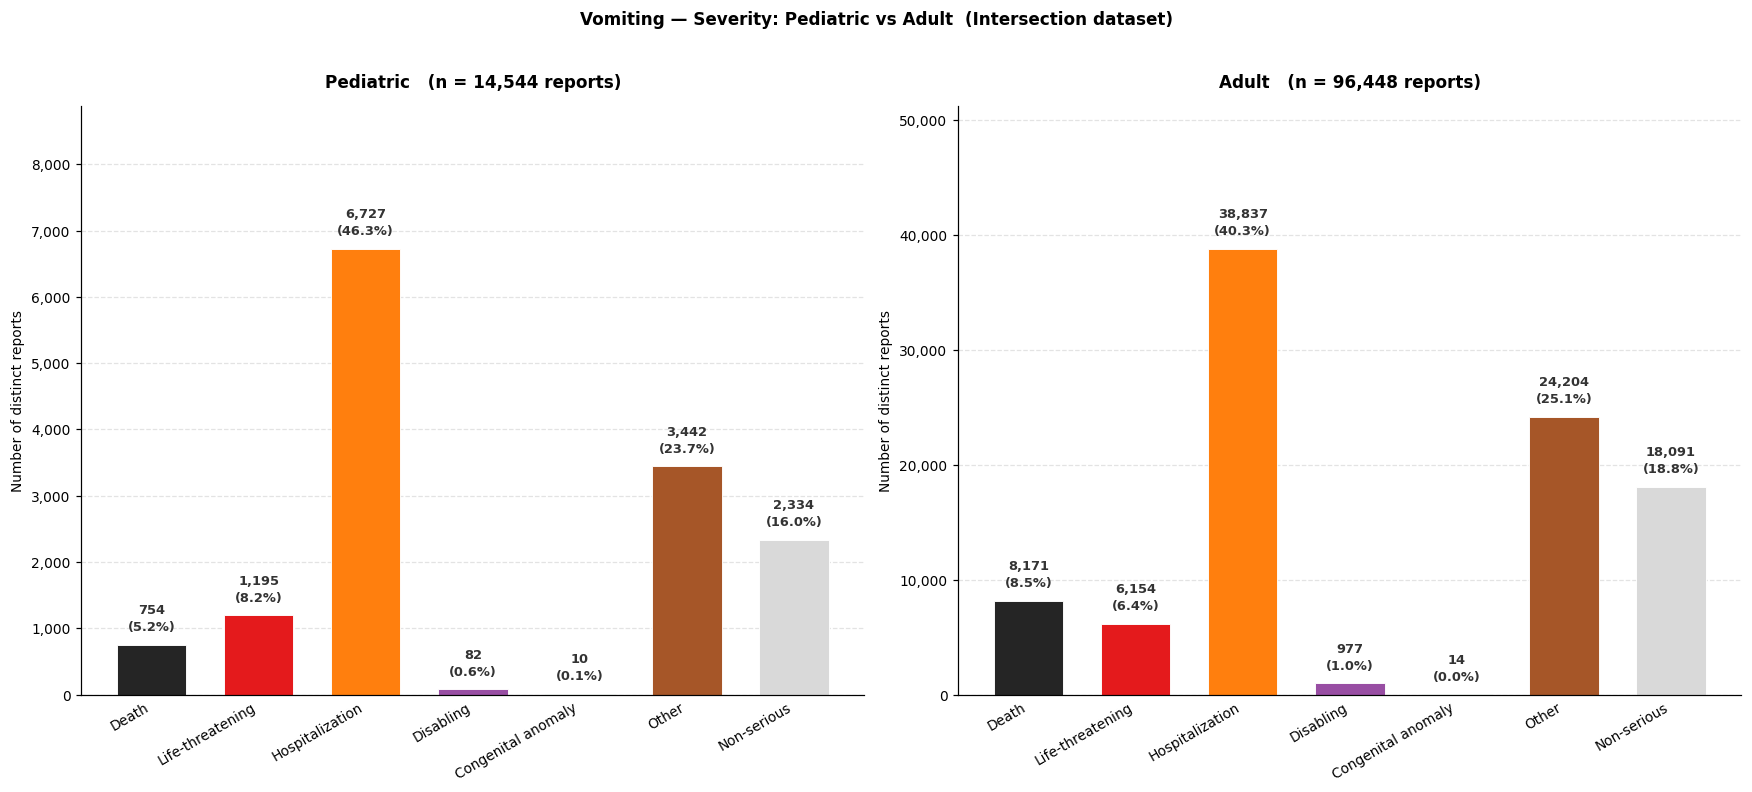

Saved → output/figures/severity_isect_vomiting.png


/tmp/ipykernel_1115303/955451631.py:94: UserWarning: Setting the 'color' property will override the edgecolor or facecolor properties.
  handles = [plt.Rectangle((0, 0), 1, 1, color=c, edgecolor="none") for c in _CI_SEV_COLORS]


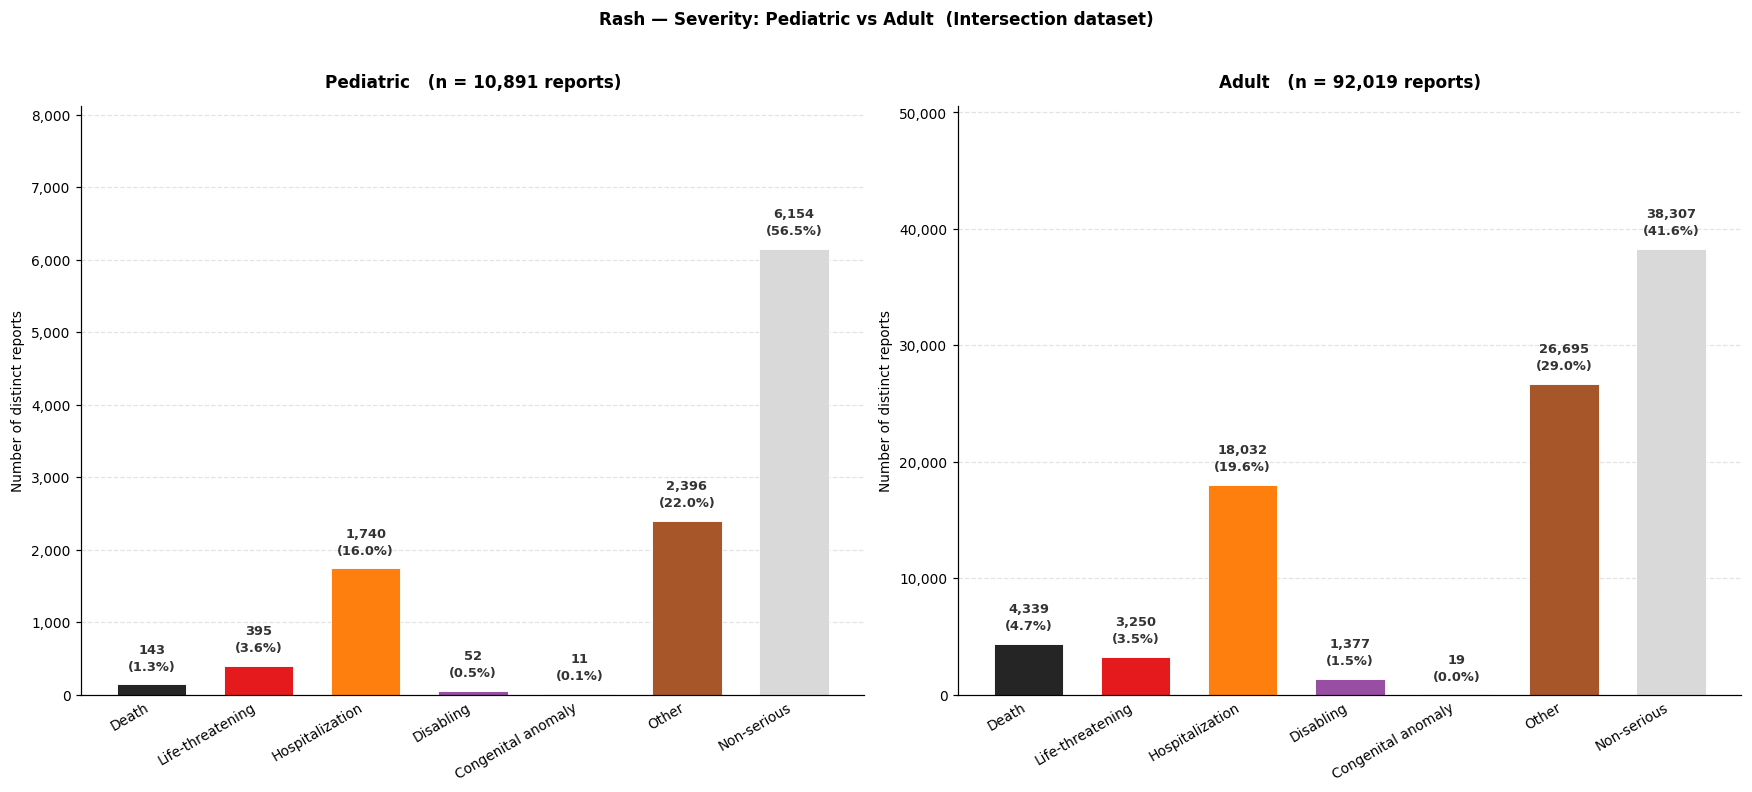

Saved → output/figures/severity_isect_rash.png


In [95]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path

# ── Severity constants (shared across C.1 / C.2) ─────────────────────────────
_CI_SEV_COLS   = ["death", "life_threatening", "hospitalization",
                  "disabling", "congenital_anomali", "other"]
_CI_SEV_LABELS = ["Death", "Life-threatening", "Hospitalization",
                  "Disabling", "Congenital anomaly", "Other", "Non-serious"]
_CI_SEV_COLORS = ["#252525", "#e41a1c", "#ff7f0e", "#984ea3",
                  "#31a354", "#a65628", "#d9d9d9"]

# ADR focus — reuse from section 1.3 (must have run cell 23)
_CI_ADR_FOCUS = ["Vomiting", "Rash"]


def _ci_sev_profile(df: pd.DataFrame, adrs: list) -> pd.DataFrame:
    """Filter to ADRs, dedup per (report, ADR), assign severity hierarchy."""
    sub = (
        df[df["reaction_meddrapt"].isin(adrs)]
        .drop_duplicates(subset=["safetyreportid", "reaction_meddrapt"])
        .copy()
    )
    conds = [sub[c].fillna(0).astype(int) == 1 for c in _CI_SEV_COLS]
    sub["_sev"] = np.select(conds, _CI_SEV_LABELS[:-1], default="Non-serious")
    return (
        sub.groupby(["reaction_meddrapt", "_sev"], observed=True)
        .size()
        .reset_index(name="n_reports")
    )


# ── Compute (requires df_ped_i / df_adu_i from Section C build cell) ─────────
ped_total_i = df_ped_i["safetyreportid"].nunique()
adu_total_i = df_adu_i["safetyreportid"].nunique()
sev_ped_ci  = _ci_sev_profile(df_ped_i, _CI_ADR_FOCUS)
sev_adu_ci  = _ci_sev_profile(df_adu_i, _CI_ADR_FOCUS)

print(f"Intersection subset:  Pediatric {ped_total_i:,} reports | Adult {adu_total_i:,} reports")


# ── Plot: same style as section 1.3 ──────────────────────────────────────────
setup_plot_style()
figures_dir = Path("../data/notebook/output/top_terms_adult/figures")
figures_dir.mkdir(parents=True, exist_ok=True)

for adr in _CI_ADR_FOCUS:
    ped_s = sev_ped_ci[sev_ped_ci["reaction_meddrapt"] == adr].set_index("_sev")["n_reports"]
    adu_s = sev_adu_ci[sev_adu_ci["reaction_meddrapt"] == adr].set_index("_sev")["n_reports"]

    pv = pd.Series({s: int(ped_s.get(s, 0)) for s in _CI_SEV_LABELS})
    av = pd.Series({s: int(adu_s.get(s, 0)) for s in _CI_SEV_LABELS})
    pt, at = pv.sum(), av.sum()

    fig, axes = plt.subplots(1, 2, figsize=(16, 7), sharey=False)
    fig.suptitle(
        f"{adr} — Severity: Pediatric vs Adult  (Intersection dataset)",
        fontsize=11, fontweight="bold", y=1.02,
    )

    for ax, vals, total, cohort_name in [
        (axes[0], pv, pt, "Pediatric"),
        (axes[1], av, at, "Adult"),
    ]:
        x    = np.arange(len(_CI_SEV_LABELS))
        ymax = int(vals.max()) if vals.max() > 0 else 1
        bars = ax.bar(x, vals.values, color=_CI_SEV_COLORS,
                      edgecolor="white", linewidth=0.6, width=0.65)

        for bar, v in zip(bars, vals.values):
            pct = 100.0 * v / total if total > 0 else 0.0
            if v > 0:
                ax.text(
                    bar.get_x() + bar.get_width() / 2,
                    bar.get_height() + ymax * 0.025,
                    f"{int(v):,}\n({pct:.1f}%)",
                    ha="center", va="bottom",
                    fontsize=8.5, fontweight="bold", color="#333333", linespacing=1.4,
                )

        ax.set_title(f"{cohort_name}   (n = {total:,} reports)", fontsize=11, fontweight="bold", pad=12)
        ax.set_xticks(x)
        ax.set_xticklabels(_CI_SEV_LABELS, rotation=30, ha="right", fontsize=9)
        ax.set_ylabel("Number of distinct reports", fontsize=9)
        ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda v, _: f"{int(v):,}"))
        ax.set_ylim(0, ymax * 1.32)
        ax.spines["top"].set_visible(False)
        ax.spines["right"].set_visible(False)
        ax.tick_params(axis="x", length=0)
        ax.grid(axis="y", linestyle="--", alpha=0.35, zorder=0)
        ax.set_axisbelow(True)

    handles = [plt.Rectangle((0, 0), 1, 1, color=c, edgecolor="none") for c in _CI_SEV_COLORS]
    # fig.legend(handles, _CI_SEV_LABELS, title="Severity",
    #            loc="lower center", ncol=4, fontsize=8.5, title_fontsize=9,
    #            bbox_to_anchor=(0.5, -0.07), frameon=True, edgecolor="#cccccc")

    plt.tight_layout()
    fname = f"severity_isect_{adr.lower()}.png"
    plt.savefig(figures_dir / fname, dpi=150, bbox_inches="tight")
    plt.show()
    print(f"Saved → {figures_dir / fname}")

## C.2 — Severity Distribution: Top Drug–ADR Pairs (Intersection dataset)

ทำซ้ำ **กราฟ 3.3** แต่ใช้ **intersection dataset** (`df_ped_i` / `df_adu_i`)  
เลือก top 5 Drug–ADR pairs จาก intersection → เปรียบเทียบ severity Ped vs Adult

> **ความต่างจาก 3.3:** ที่นี่ใช้ข้อมูลจาก intersection subset เท่านั้น  
> → ทุก pair ที่วิเคราะห์รับประกันว่ามีทั้งใน Ped และ Adult  
> → ลด selection bias จาก drug exposure ที่ไม่ตรงกันระหว่างสอง cohort

Top 5 intersection Drug–ADR pairs (ranked by combined intersection count):


,rank,display_label,rxcui,reaction_meddrapt,n_ped,n_adu,n_combined
0,1,DUPIXENT(dupilumab) -- Pruritus,1876402,Pruritus,7205,24341,31546
1,2,DUPIXENT(dupilumab) -- Rash,1876402,Rash,4499,13420,17919
2,3,ENBREL(etanercept) -- Arthralgia,216891,Arthralgia,320,16284,16604
3,4,ENBREL(etanercept) -- Pain,216891,Pain,340,16158,16498
4,5,DUPIXENT(dupilumab) -- Eczema,1876402,Eczema,5150,9731,14881


/tmp/ipykernel_1115303/48105069.py:90: UserWarning: Setting the 'color' property will override the edgecolor or facecolor properties.
  handles = [plt.Rectangle((0, 0), 1, 1, color=c, edgecolor="none") for c in _CI_SEV_COLORS]


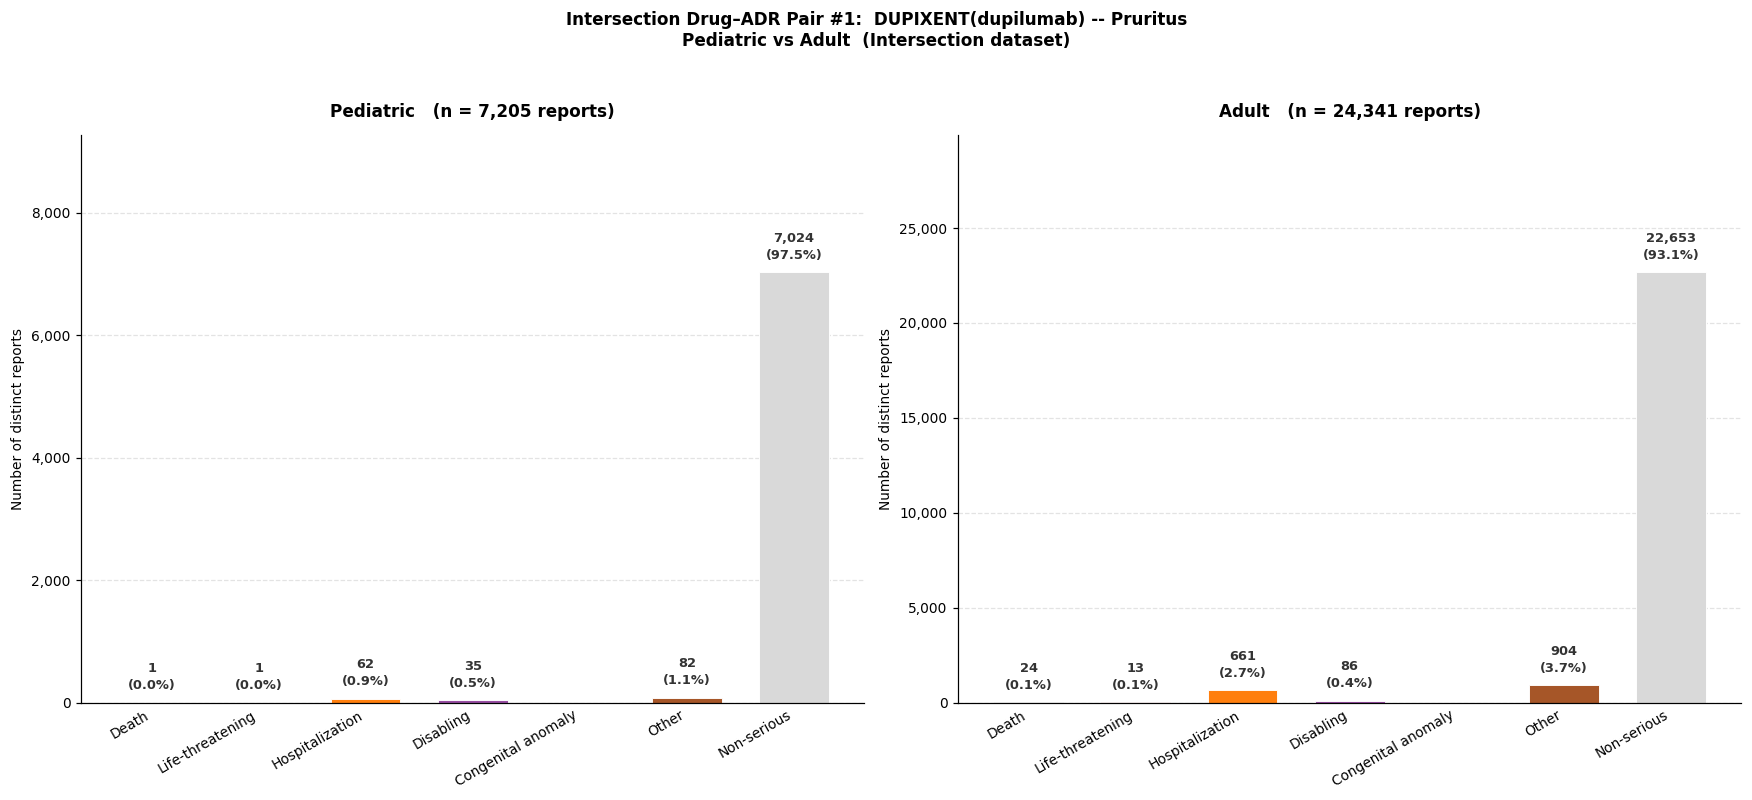

Saved → output/figures/severity_isect_pair_01_DUPIXENT_dupilumab_____Pruritus.png


/tmp/ipykernel_1115303/48105069.py:90: UserWarning: Setting the 'color' property will override the edgecolor or facecolor properties.
  handles = [plt.Rectangle((0, 0), 1, 1, color=c, edgecolor="none") for c in _CI_SEV_COLORS]


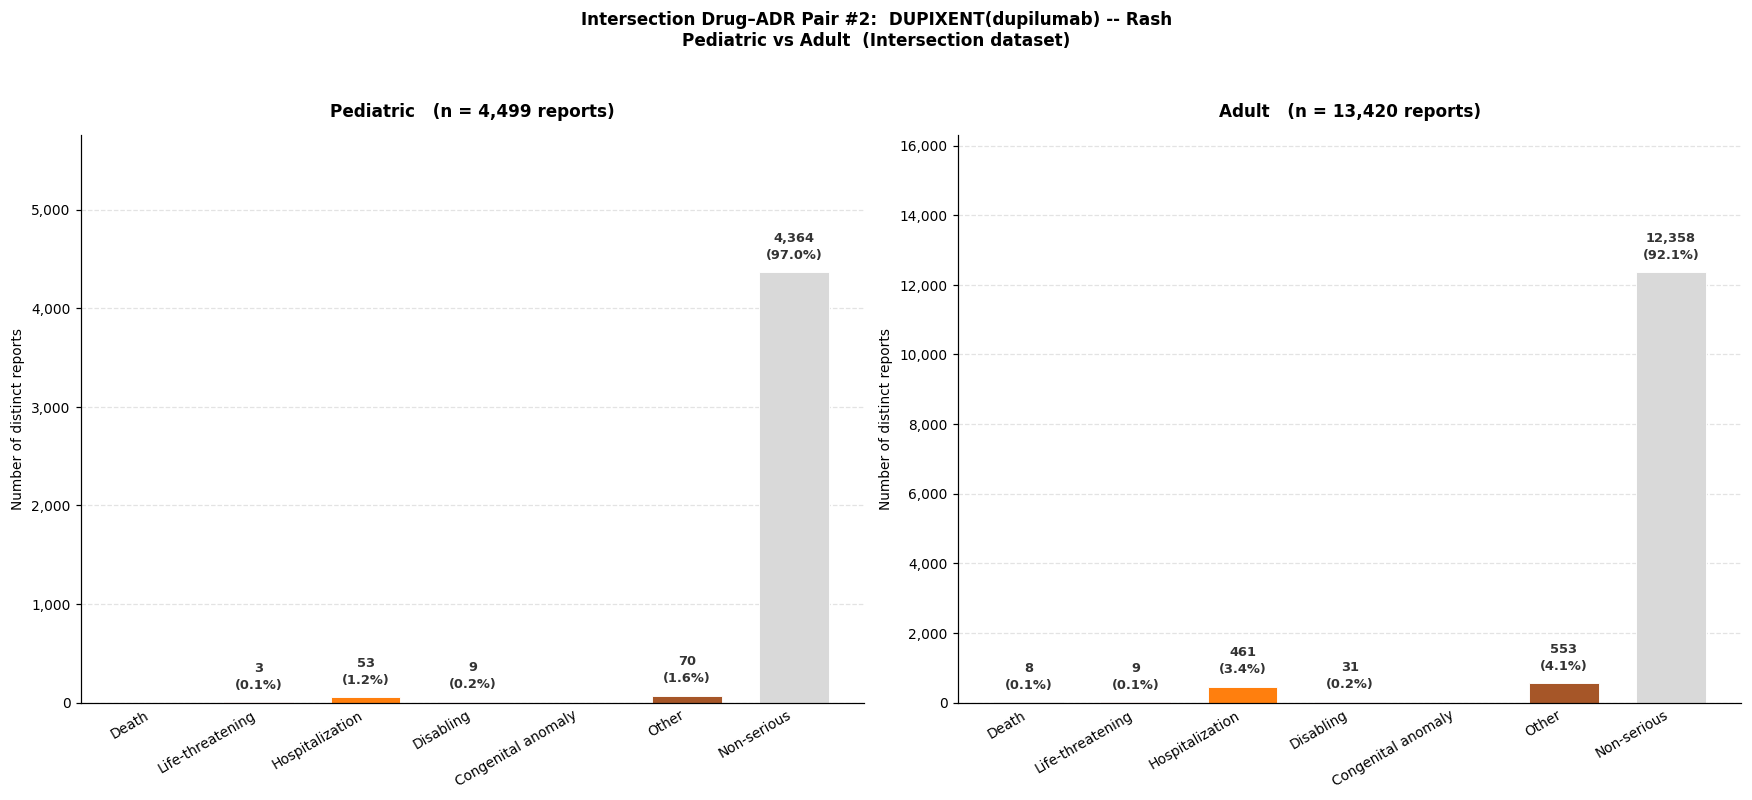

Saved → output/figures/severity_isect_pair_02_DUPIXENT_dupilumab_____Rash.png


/tmp/ipykernel_1115303/48105069.py:90: UserWarning: Setting the 'color' property will override the edgecolor or facecolor properties.
  handles = [plt.Rectangle((0, 0), 1, 1, color=c, edgecolor="none") for c in _CI_SEV_COLORS]


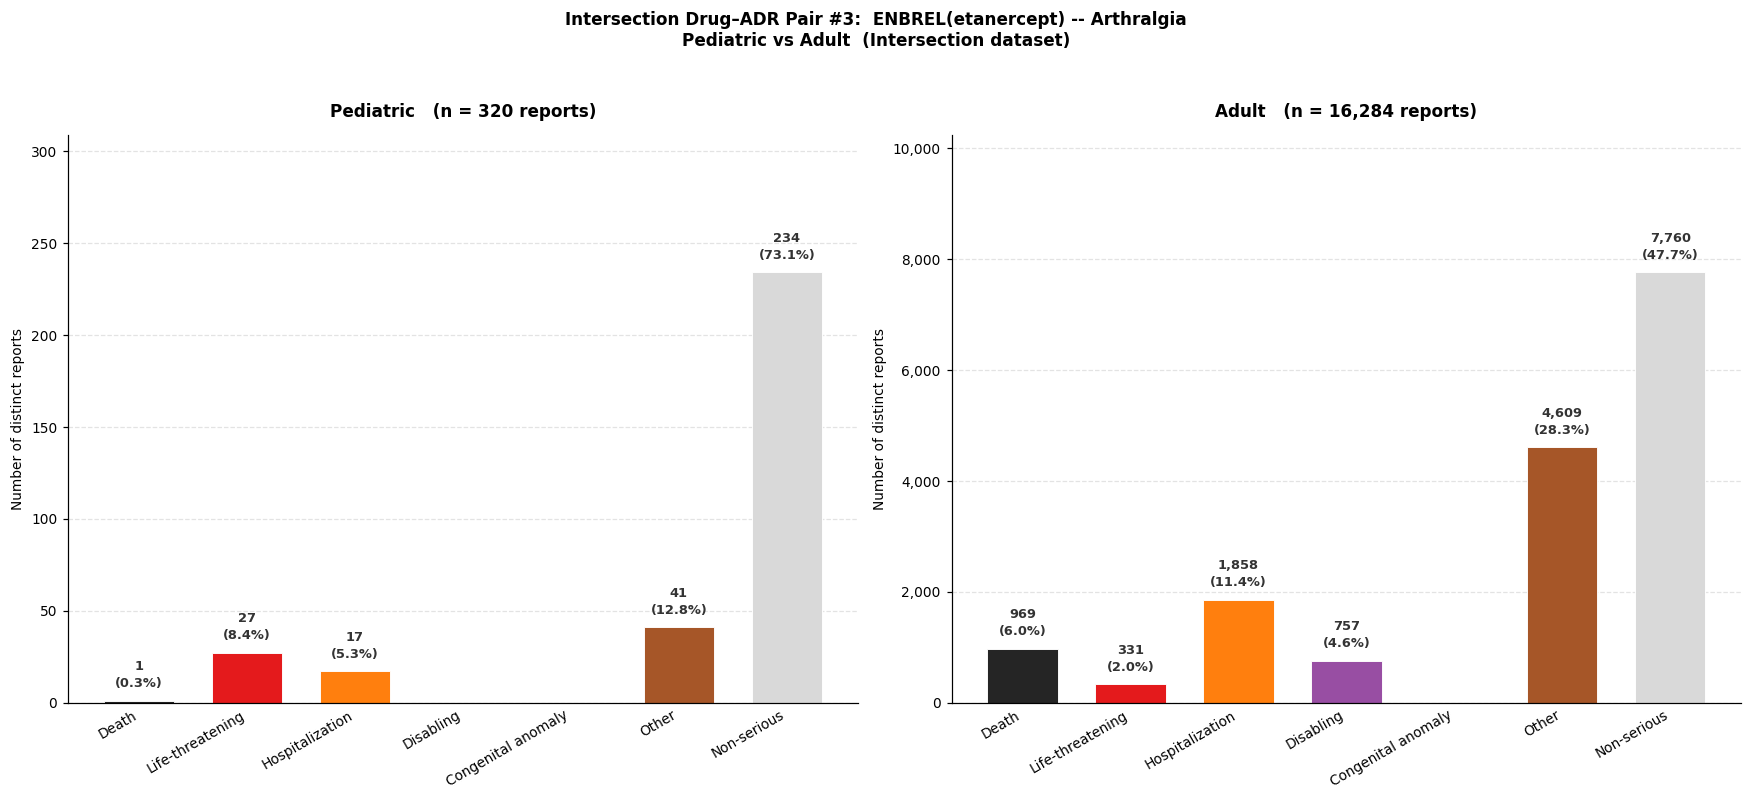

Saved → output/figures/severity_isect_pair_03_ENBREL_etanercept_____Arthralgia.png


/tmp/ipykernel_1115303/48105069.py:90: UserWarning: Setting the 'color' property will override the edgecolor or facecolor properties.
  handles = [plt.Rectangle((0, 0), 1, 1, color=c, edgecolor="none") for c in _CI_SEV_COLORS]


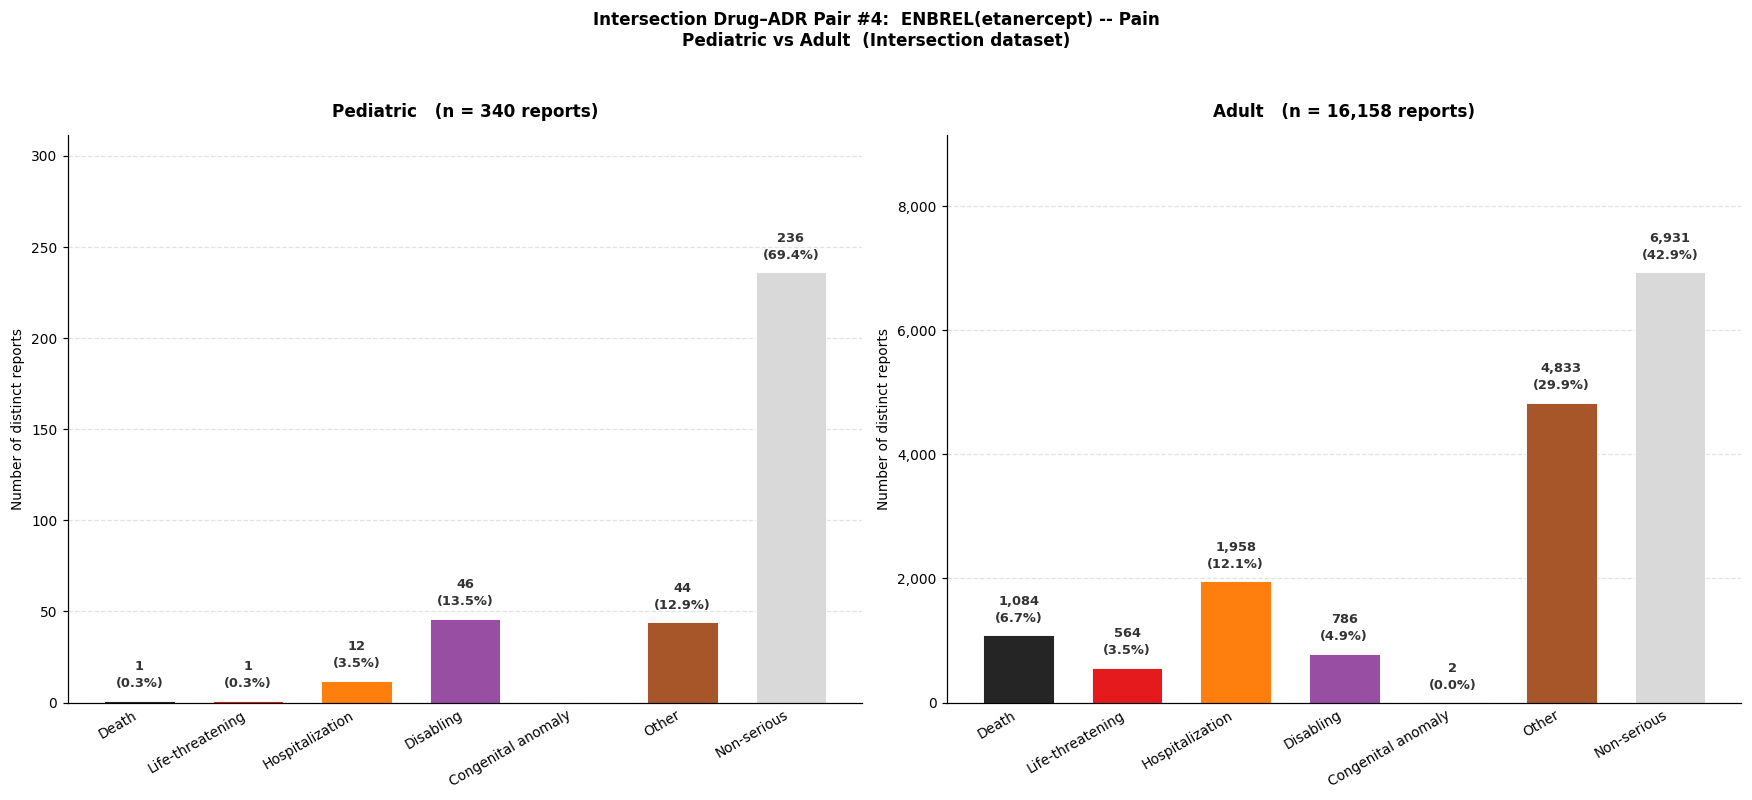

Saved → output/figures/severity_isect_pair_04_ENBREL_etanercept_____Pain.png


/tmp/ipykernel_1115303/48105069.py:90: UserWarning: Setting the 'color' property will override the edgecolor or facecolor properties.
  handles = [plt.Rectangle((0, 0), 1, 1, color=c, edgecolor="none") for c in _CI_SEV_COLORS]


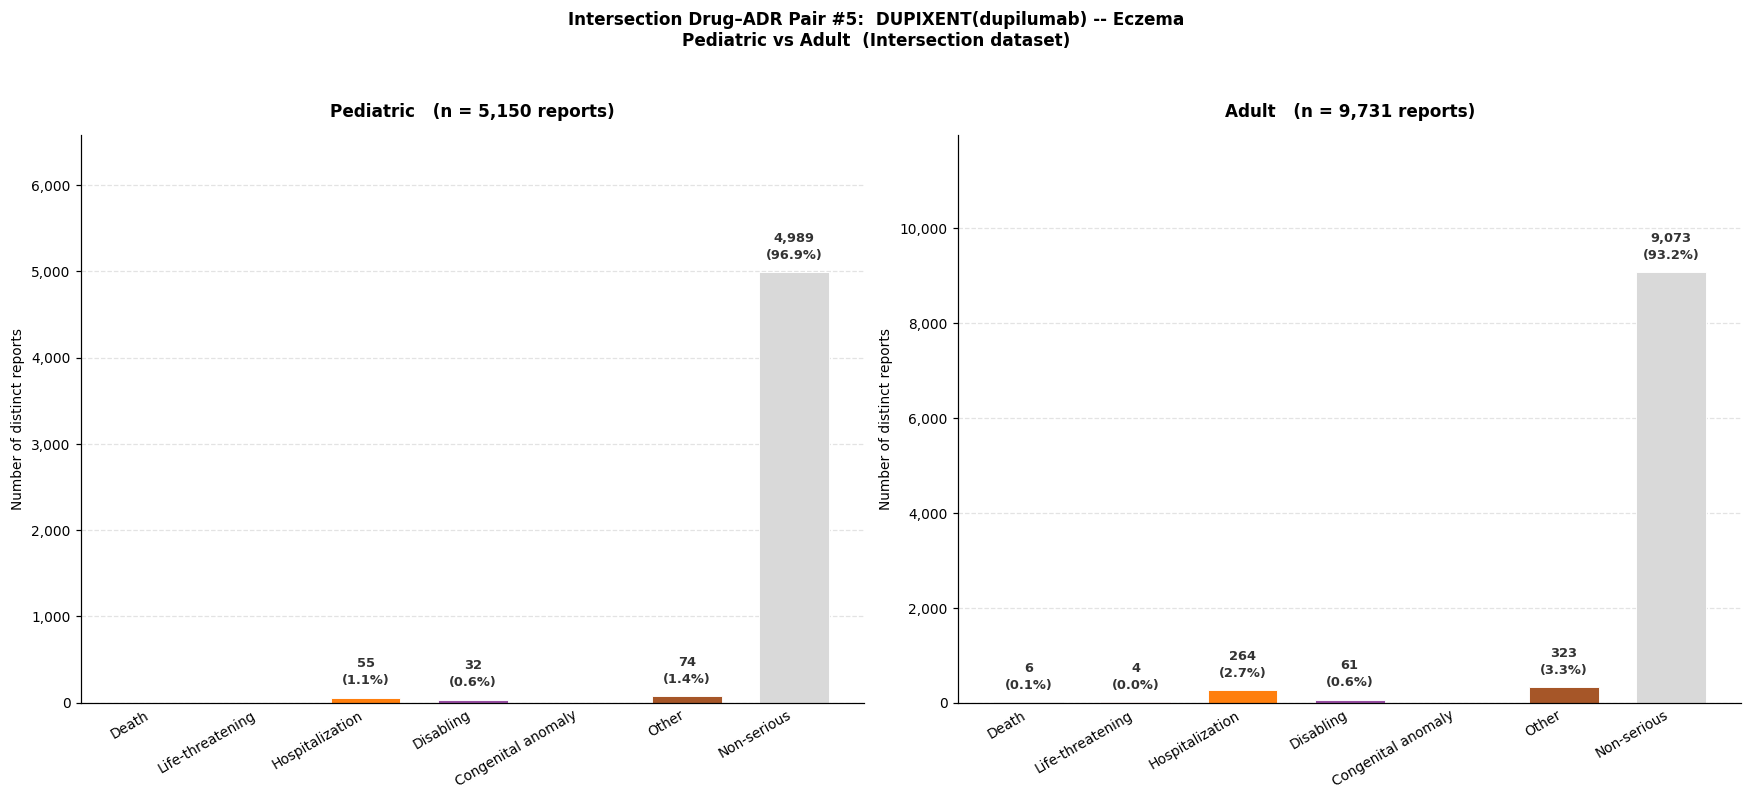

Saved → output/figures/severity_isect_pair_05_DUPIXENT_dupilumab_____Eczema.png


In [96]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path

# ── Config ────────────────────────────────────────────────────────────────────
N_ISECT_PAIRS = 5   # top N Drug-ADR pairs from intersection to plot

# _CI_SEV_COLS / _CI_SEV_LABELS / _CI_SEV_COLORS defined in C.1 cell above


# ── Get top Drug-ADR pairs from intersection (uses full df_ped / df_adu for
#    label lookup, but counts are based on intersection rows) ─────────────────
top_pairs_ci = intersect_drug_adr_reports(df_ped, df_adu, n=N_ISECT_PAIRS)
print(f"Top {N_ISECT_PAIRS} intersection Drug–ADR pairs (ranked by combined intersection count):")
display(top_pairs_ci[["rank", "display_label", "rxcui", "reaction_meddrapt",
                       "n_ped", "n_adu", "n_combined"]])


# ── Helper: severity counts from intersection data for one pair ───────────────
def _ci_pair_sev(df_i: pd.DataFrame, rxcui_val, pt_val) -> pd.Series:
    """Filter intersection df to one drug-ADR pair, dedup, assign severity."""
    sub = (
        df_i[(df_i["rxcui"] == rxcui_val) & (df_i["reaction_meddrapt"] == pt_val)]
        .drop_duplicates(subset=["safetyreportid"])
        .copy()
    )
    if sub.empty:
        return pd.Series(0, index=_CI_SEV_LABELS)
    conds = [sub[c].fillna(0).astype(int) == 1 for c in _CI_SEV_COLS]
    sub["_sev"] = np.select(conds, _CI_SEV_LABELS[:-1], default="Non-serious")
    return sub["_sev"].value_counts().reindex(_CI_SEV_LABELS, fill_value=0)


# ── Plot: one figure per pair (same style as section 3.3) ────────────────────
setup_plot_style()
figures_dir = Path("../data/notebook/output/top_terms_adult/figures")
figures_dir.mkdir(parents=True, exist_ok=True)

for _, row in top_pairs_ci.iterrows():
    rxcui_val = row["rxcui"]
    pt_val    = row["reaction_meddrapt"]
    pair_lbl  = row["display_label"]
    rank      = int(row["rank"])

    pv_ci = _ci_pair_sev(df_ped_i, rxcui_val, pt_val)
    av_ci = _ci_pair_sev(df_adu_i, rxcui_val, pt_val)
    pt_cnt = int(pv_ci.sum())
    at_cnt = int(av_ci.sum())

    fig, axes = plt.subplots(1, 2, figsize=(16, 7), sharey=False)
    fig.suptitle(
        f"Intersection Drug–ADR Pair #{rank}:  {pair_lbl}\n"
        "Pediatric vs Adult  (Intersection dataset)",
        fontsize=11, fontweight="bold", y=1.03,
    )

    for ax, vals, total, cohort_name in [
        (axes[0], pv_ci, pt_cnt, "Pediatric"),
        (axes[1], av_ci, at_cnt, "Adult"),
    ]:
        x    = np.arange(len(_CI_SEV_LABELS))
        ymax = int(vals.max()) if vals.max() > 0 else 1
        bars = ax.bar(x, vals.values, color=_CI_SEV_COLORS,
                      edgecolor="white", linewidth=0.6, width=0.65)

        for bar, v in zip(bars, vals.values):
            pct = 100.0 * v / total if total > 0 else 0.0
            if v > 0:
                ax.text(
                    bar.get_x() + bar.get_width() / 2,
                    bar.get_height() + ymax * 0.025,
                    f"{int(v):,}\n({pct:.1f}%)",
                    ha="center", va="bottom",
                    fontsize=8.5, fontweight="bold", color="#333333", linespacing=1.4,
                )

        ax.set_title(f"{cohort_name}   (n = {total:,} reports)", fontsize=11, fontweight="bold", pad=12)
        ax.set_xticks(x)
        ax.set_xticklabels(_CI_SEV_LABELS, rotation=30, ha="right", fontsize=9)
        ax.set_ylabel("Number of distinct reports", fontsize=9)
        ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda v, _: f"{int(v):,}"))
        ax.set_ylim(0, ymax * 1.32)
        ax.spines["top"].set_visible(False)
        ax.spines["right"].set_visible(False)
        ax.tick_params(axis="x", length=0)
        ax.grid(axis="y", linestyle="--", alpha=0.35, zorder=0)
        ax.set_axisbelow(True)

    handles = [plt.Rectangle((0, 0), 1, 1, color=c, edgecolor="none") for c in _CI_SEV_COLORS]
    # fig.legend(handles, _CI_SEV_LABELS, title="Severity",
    #            loc="lower center", ncol=4, fontsize=8.5, title_fontsize=9,
    #            bbox_to_anchor=(0.5, -0.07), frameon=True, edgecolor="#cccccc")

    plt.tight_layout()
    safe_lbl = "".join(c if c.isalnum() else "_" for c in pair_lbl)[:40]
    fname = f"severity_isect_pair_{rank:02d}_{safe_lbl}.png"
    plt.savefig(figures_dir / fname, dpi=150, bbox_inches="tight")
    plt.show()
    print(f"Saved → {figures_dir / fname}")

---

# D — ผลลัพธ์เพิ่มเติม

---

# 7. Export CSV (optional)

บันทึกผลลัพธ์ top-10 ทุก section เป็น CSV

In [ ]:
from pathlib import Path

export_dir = Path("../data/notebook/output/top_terms_adult/csv")
export_dir.mkdir(parents=True, exist_ok=True)

rxn_rep_ped.to_csv(export_dir / "top5_reaction_by_report_pediatric.csv",  index=False)
rxn_rep_adu.to_csv(export_dir / "top5_reaction_by_report_adult.csv",      index=False)
mp_rep_ped.to_csv( export_dir / "top10_rxcui_pt_by_report_pediatric.csv", index=False)
mp_rep_adu.to_csv( export_dir / "top10_rxcui_pt_by_report_adult.csv",     index=False)
drug_rep_ped.to_csv(export_dir / "top10_rxcui_drug_only_by_report_pediatric.csv", index=False)
drug_rep_adu.to_csv(export_dir / "top10_rxcui_drug_only_by_report_adult.csv",     index=False)
print("Written:", sorted(p.name for p in export_dir.glob("top*.csv")))


Written: ['top10_rxcui_drug_only_by_report_adult.csv', 'top10_rxcui_drug_only_by_report_pediatric.csv', 'top10_rxcui_pt_by_report_adult.csv', 'top10_rxcui_pt_by_report_pediatric.csv', 'top5_product_by_report_adult.csv', 'top5_product_by_report_pediatric.csv', 'top5_reaction_by_report_adult.csv', 'top5_reaction_by_report_pediatric.csv']


# 8. System Organ Class (SOC), PT & Ingredient–PT Combinations

วิเคราะห์ข้อมูลเพิ่มเติมด้วย **Polars** lazy scan สำหรับชุดข้อมูลขนาดใหญ่

## คอลัมน์ที่ใช้

| ความต้องการ | ฟิลด์ | หมายเหตุ |
|-------------|-------|---------|
| **SOC** | `meddra_soc_names` (List) | PT 1 รายการอาจมีหลาย SOC → ต้อง explode ก่อนนับ |
| **PT** | `reaction_meddrapt` | MedDRA PT หลัง map S06 |
| **Active ingredient** | `ingredient` (List) | จาก RxNorm ต่อ `rxcui` |
| **Ingredient–PT combo** | `ingredient — PT` | ตาราง frequency คู่ที่พบบ่อย |

## วิธีนับ SOC (สำคัญ)

```
meddra_soc_names = ["Cardiac disorders", "Infections and infestations"]
```
→ 1 report นับใน 2 SOC → **ต้อง explode แล้ว deduplicate (safetyreportid, SOC)**  
→ denominator = unique reports ทั้งหมดของ cohort นั้น

## 3 ชุดข้อมูล

| ชุด | คำอธิบาย |
|-----|---------|
| **Full Ped** | Pediatric cohort ทั้งหมด |
| **Full Adult** | Adult cohort ทั้งหมด |
| **Intersection** | เฉพาะรายงานที่มี reaction_meddrapt ที่พบในทั้งสองกลุ่ม (Ped ∩ Adult) |


In [ ]:
import polars as pl
import pandas as pd

# Lazy scan — ไม่โหลด DataFrame ทั้งหมดเข้า RAM
lf_ped_pl = pl.scan_parquet(str(PATHS["Pediatric"]))
lf_adu_pl = pl.scan_parquet(str(PATHS["Adult"]))

N_SOC       = 10   # top SOC ที่แสดง
N_FETCH     = 20   # fetch เผื่อไว้ก่อน merge เพื่อความครบถ้วน
N_TOP_COMBO = 20   # top ingredient–PT pairs


# ── Helper: Top SOC by distinct reports (explode list column) ────────────────

def _top_soc_n(lf: pl.LazyFrame, n: int = N_FETCH) -> tuple:
    """Explode meddra_soc_names → deduplicate (report, SOC) → count per SOC.

    Key logic:
      - 1 report อาจมีหลาย SOC → explode ก่อน
      - .unique() deduplicate (safetyreportid, SOC) เพื่อไม่นับซ้ำ
      - นับ distinct safetyreportid ต่อ SOC
    Returns (DataFrame, total_unique_reports).
    """
    total = lf.select(pl.col("safetyreportid").n_unique()).collect().item()
    df = (
        lf.explode("meddra_soc_names")
        .filter(
            pl.col("meddra_soc_names").is_not_null()
            & (pl.col("meddra_soc_names").str.len_chars() > 0)
        )
        .select(["safetyreportid", "meddra_soc_names"])
        .unique()                                          # (report, SOC) pair counted once
        .group_by("meddra_soc_names")
        .agg(pl.col("safetyreportid").n_unique().alias("n_reports"))
        .sort("n_reports", descending=True)
        .head(n)
        .collect(engine="streaming")
        .to_pandas()
    )
    return df, int(total)


def _merge_soc(ped_df, ped_total, adu_df, adu_total, n=N_SOC):
    """Outer-join Ped + Adult SOC tables; sort by n_combined; take top-n."""
    m = (
        ped_df[["meddra_soc_names", "n_reports"]]
        .rename(columns={"n_reports": "n_ped"})
        .merge(
            adu_df[["meddra_soc_names", "n_reports"]].rename(columns={"n_reports": "n_adu"}),
            on="meddra_soc_names",
            how="outer",
        )
        .fillna(0)
        .assign(n_combined=lambda d: d["n_ped"] + d["n_adu"])
        .sort_values("n_combined", ascending=False)
        .head(n)
        .reset_index(drop=True)
    )
    m.insert(0, "rank", range(1, len(m) + 1))
    m["pct_ped"] = (100.0 * m["n_ped"] / ped_total).round(2)
    m["pct_adu"] = (100.0 * m["n_adu"] / adu_total).round(2)
    return m


def _top_soc_intersection_n(lf: pl.LazyFrame, pair_isect_keys: set, n: int = N_FETCH) -> tuple:
    """Same as _top_soc_n but filtered to intersection (rxcui, reaction_meddrapt) pairs.

    Must use PAIR keys (not just reaction_meddrapt alone) so the filter matches
    exactly the same rows as df_ped_i / df_adu_i from Cell 38.
    Key format: rxcui + "||" + reaction_meddrapt  (same as pair_isect_keys).
    """
    lf_filtered = (
        lf.with_columns(
            (pl.col("rxcui").cast(pl.Utf8) + pl.lit("||") + pl.col("reaction_meddrapt"))
            .alias("_pair_key")
        )
        .filter(pl.col("_pair_key").is_in(list(pair_isect_keys)))
    )
    return _top_soc_n(lf_filtered, n)


# ── Helper: Ingredient–PT combinations (report-level count) ─────────────────

def top_ingredient_pt_combinations(lf: pl.LazyFrame, n: int = N_TOP_COMBO) -> pd.DataFrame:
    """Most frequent (active ingredient × PT) pairs — report-level count.

    Deduplicates per (safetyreportid, ingredient, PT) before counting,
    so 1 report contributes at most 1 count per combination.
    """
    return (
        lf.with_columns(
            pl.when(pl.col("ingredient").list.len().fill_null(0) > 0)
            .then(pl.col("ingredient").list.join("; "))
            .otherwise(pl.lit("(empty)"))
            .alias("product_active_ingredient"),
            pl.col("reaction_meddrapt").alias("preferred_term"),
        )
        .select(["safetyreportid", "product_active_ingredient", "preferred_term"])
        .unique()                                    # deduplicate per (report, ingredient, PT)
        .group_by(["product_active_ingredient", "preferred_term"])
        .agg(pl.col("safetyreportid").n_unique().alias("n_reports"))
        .sort("n_reports", descending=True)
        .head(n)
        .with_columns(
            (pl.col("product_active_ingredient") + pl.lit(" — ") + pl.col("preferred_term").fill_null(""))
            .alias("ingredient_pt_combination")
        )
        .select(["ingredient_pt_combination", "product_active_ingredient", "preferred_term", "n_reports"])
        .collect(engine="streaming")
        .to_pandas()
    )


# ── Compute: Full-cohort SOC ─────────────────────────────────────────────────
print("Computing SOC — full cohort (explode + deduplicate)...")
_soc_ped_raw, ped_total   = _top_soc_n(lf_ped_pl)
_soc_adu_raw, adu_total   = _top_soc_n(lf_adu_pl)
soc_full = _merge_soc(_soc_ped_raw, ped_total, _soc_adu_raw, adu_total)
print(f"  Ped: {ped_total:,} reports  |  Adult: {adu_total:,} reports")
display(soc_full[["rank", "meddra_soc_names", "n_ped", "pct_ped", "n_adu", "pct_adu", "n_combined"]])

# ── Compute: Intersection SOC ────────────────────────────────────────────────
# pair_isect_set is available from Cell 38 (must run that cell first)
# pair_isect_keys from Cell 38: "rxcui||reaction_meddrapt" strings
print(f"\nComputing SOC — intersection ({len(pair_isect_keys):,} unique pairs from Cell 38)...")
_soc_ped_isect_raw, ped_isect_total = _top_soc_intersection_n(lf_ped_pl, pair_isect_keys)
_soc_adu_isect_raw, adu_isect_total = _top_soc_intersection_n(lf_adu_pl, pair_isect_keys)
soc_isect = _merge_soc(_soc_ped_isect_raw, ped_isect_total, _soc_adu_isect_raw, adu_isect_total)
print(f"  Ped: {ped_isect_total:,} reports  |  Adult: {adu_isect_total:,} reports")
display(soc_isect[["rank", "meddra_soc_names", "n_ped", "pct_ped", "n_adu", "pct_adu", "n_combined"]])

# ── Compute: Ingredient–PT combinations ─────────────────────────────────────
print(f"\nComputing top {N_TOP_COMBO} ingredient–PT combinations (report-level)...")
combo_ped = top_ingredient_pt_combinations(lf_ped_pl)
combo_adu = top_ingredient_pt_combinations(lf_adu_pl)
print("  Pediatric:")
display(combo_ped)
print("  Adult:")
display(combo_adu)


Computing SOC — full cohort (explode + deduplicate)...
  Ped: 221,182 reports  |  Adult: 2,506,379 reports


,rank,meddra_soc_names,n_ped,pct_ped,n_adu,pct_adu,n_combined
0,1,General disorders and administration site cond...,50068,22.64,751780,29.99,801848
1,2,Nervous system disorders,61033,27.59,579581,23.12,640614
2,3,Gastrointestinal disorders,39867,18.02,508991,20.31,548858
3,4,Skin and subcutaneous tissue disorders,49079,22.19,481596,19.21,530675
4,5,"Respiratory, thoracic and mediastinal disorders",36757,16.62,466758,18.62,503515
5,6,Vascular disorders,34385,15.55,410091,16.36,444476
6,7,Cardiac disorders,26048,11.78,351389,14.02,377437
7,8,Psychiatric disorders,34865,15.76,338677,13.51,373542
8,9,Infections and infestations,25594,11.57,345054,13.77,370648
9,10,Blood and lymphatic system disorders,22492,10.17,273311,10.90,295803



Computing SOC — intersection (107,463 unique pairs from Cell 38)...
  Ped: 207,368 reports  |  Adult: 1,982,482 reports


,rank,meddra_soc_names,n_ped,pct_ped,n_adu,pct_adu,n_combined
0,1,General disorders and administration site cond...,46258,22.31,596000,30.06,642258
1,2,Nervous system disorders,57145,27.56,420026,21.19,477171
2,3,Gastrointestinal disorders,37344,18.01,400772,20.22,438116
3,4,Skin and subcutaneous tissue disorders,46347,22.35,359954,18.16,406301
4,5,"Respiratory, thoracic and mediastinal disorders",33074,15.95,362179,18.27,395253
5,6,Vascular disorders,32080,15.47,295759,14.92,327839
6,7,Cardiac disorders,24594,11.86,270472,13.64,295066
7,8,Infections and infestations,22738,10.97,245954,12.41,268692
8,9,Psychiatric disorders,32382,15.62,235610,11.88,267992
9,10,Blood and lymphatic system disorders,21235,10.24,221040,11.15,242275



Computing top 20 ingredient–PT combinations (report-level)...
  Pediatric:


,ingredient_pt_combination,product_active_ingredient,preferred_term,n_reports
0,dupilumab — Pruritus,dupilumab,Pruritus,7286
1,dupilumab — Eczema,dupilumab,Eczema,5200
2,dupilumab — Rash,dupilumab,Rash,4574
3,dupilumab — Erythema,dupilumab,Erythema,2231
4,acetaminophen; acetaminophen / adiphenine; ace...,acetaminophen; acetaminophen / adiphenine; ace...,Vomiting,1994
5,methotrexate — Pyrexia,methotrexate,Pyrexia,1319
6,dupilumab — Asthma,dupilumab,Asthma,1228
7,levetiracetam — Seizure,levetiracetam,Seizure,1226
8,ammonium chloride / diphenhydramine / sodium c...,ammonium chloride / diphenhydramine / sodium c...,Paraesthesia,1144
9,vincristine — Neutropenia,vincristine,Neutropenia,1049


  Adult:


,ingredient_pt_combination,product_active_ingredient,preferred_term,n_reports
0,dupilumab — Pruritus,dupilumab,Pruritus,24898
1,etanercept — Arthralgia,etanercept,Arthralgia,17176
2,etanercept — Pain,etanercept,Pain,17090
3,clozapine — Neutropenia,clozapine,Neutropenia,14054
4,dupilumab — Rash,dupilumab,Rash,13841
5,apremilast — Diarrhoea,apremilast,Diarrhoea,12151
6,lenalidomide — Diarrhoea,lenalidomide,Diarrhoea,11540
7,abatacept — Arthralgia,abatacept,Arthralgia,11391
8,etanercept — Fatigue,etanercept,Fatigue,11262
9,lenalidomide — Death,lenalidomide,Death,11102


## กราฟ 8.1 — Top 10 SOC (Full Cohort + Intersection)

| กราฟ | เนื้อหา |
|------|--------|
| **Plot 1** | Top 10 SOC — Pediatric vs Adult (full cohort); grouped bars, label = N (%) |
| **Plot 2** | Top 10 SOC — Pediatric vs Adult (intersection only); เปรียบเทียบว่า SOC เปลี่ยนไหมเมื่อ filter |
| **Plot 3** | Top 20 ingredient–PT pairs แยก Ped / Adult (report count) |

> **% คำนวณจาก:** n_reports ต่อ SOC ÷ unique reports ทั้งหมดของ cohort นั้น  
> เนื่องจาก 1 report อาจนับใน **หลาย SOC** พร้อมกัน ผลรวม % จะ **> 100%** — นี่คือ design ที่ถูกต้อง


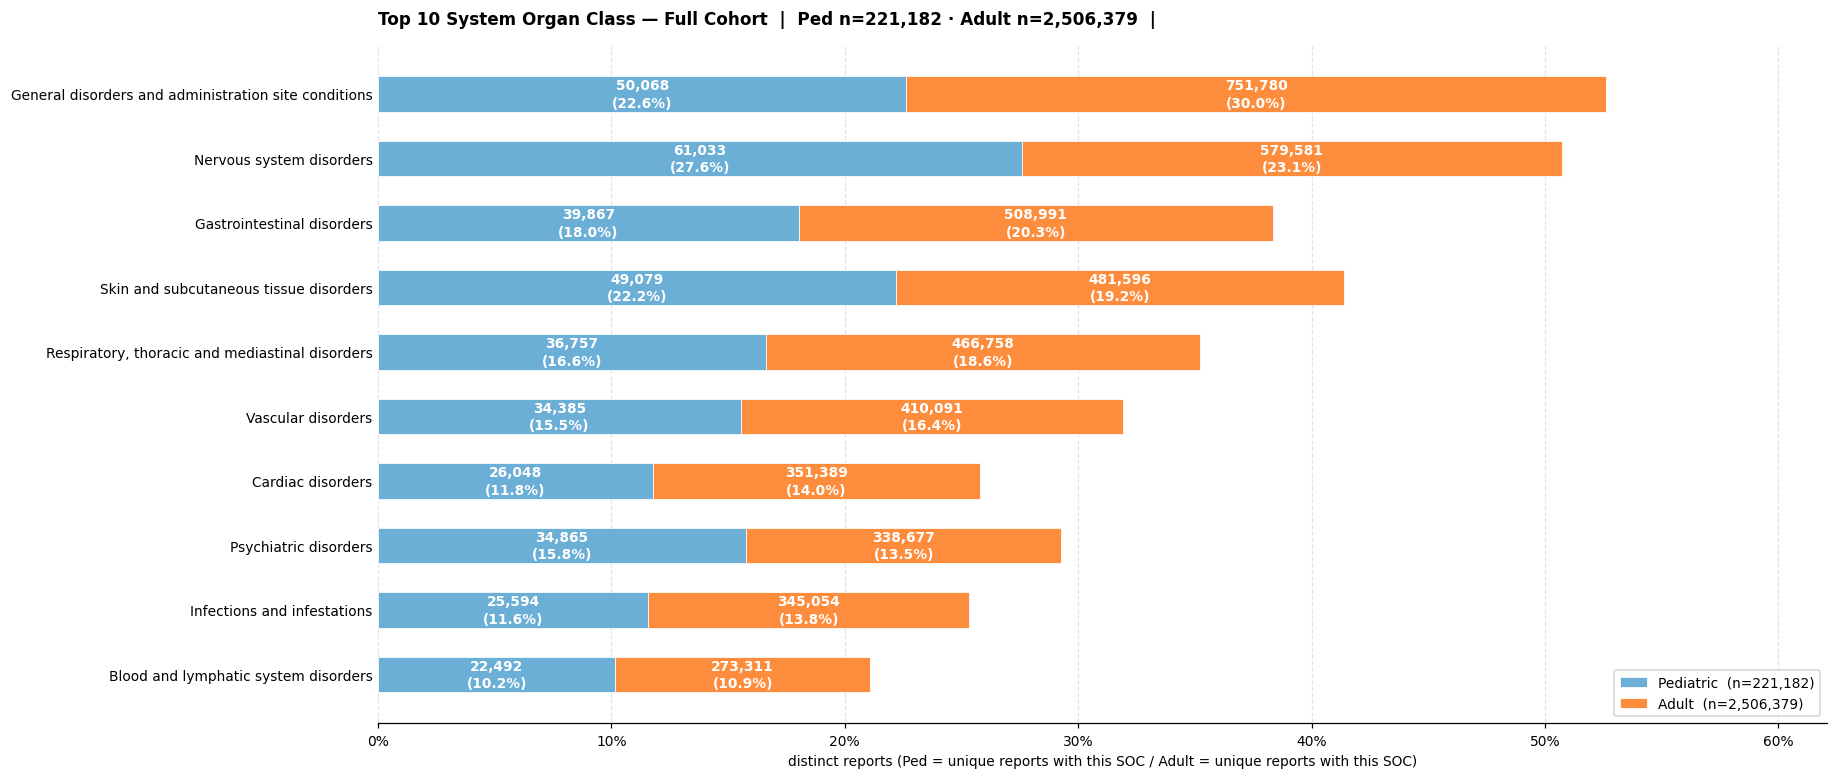

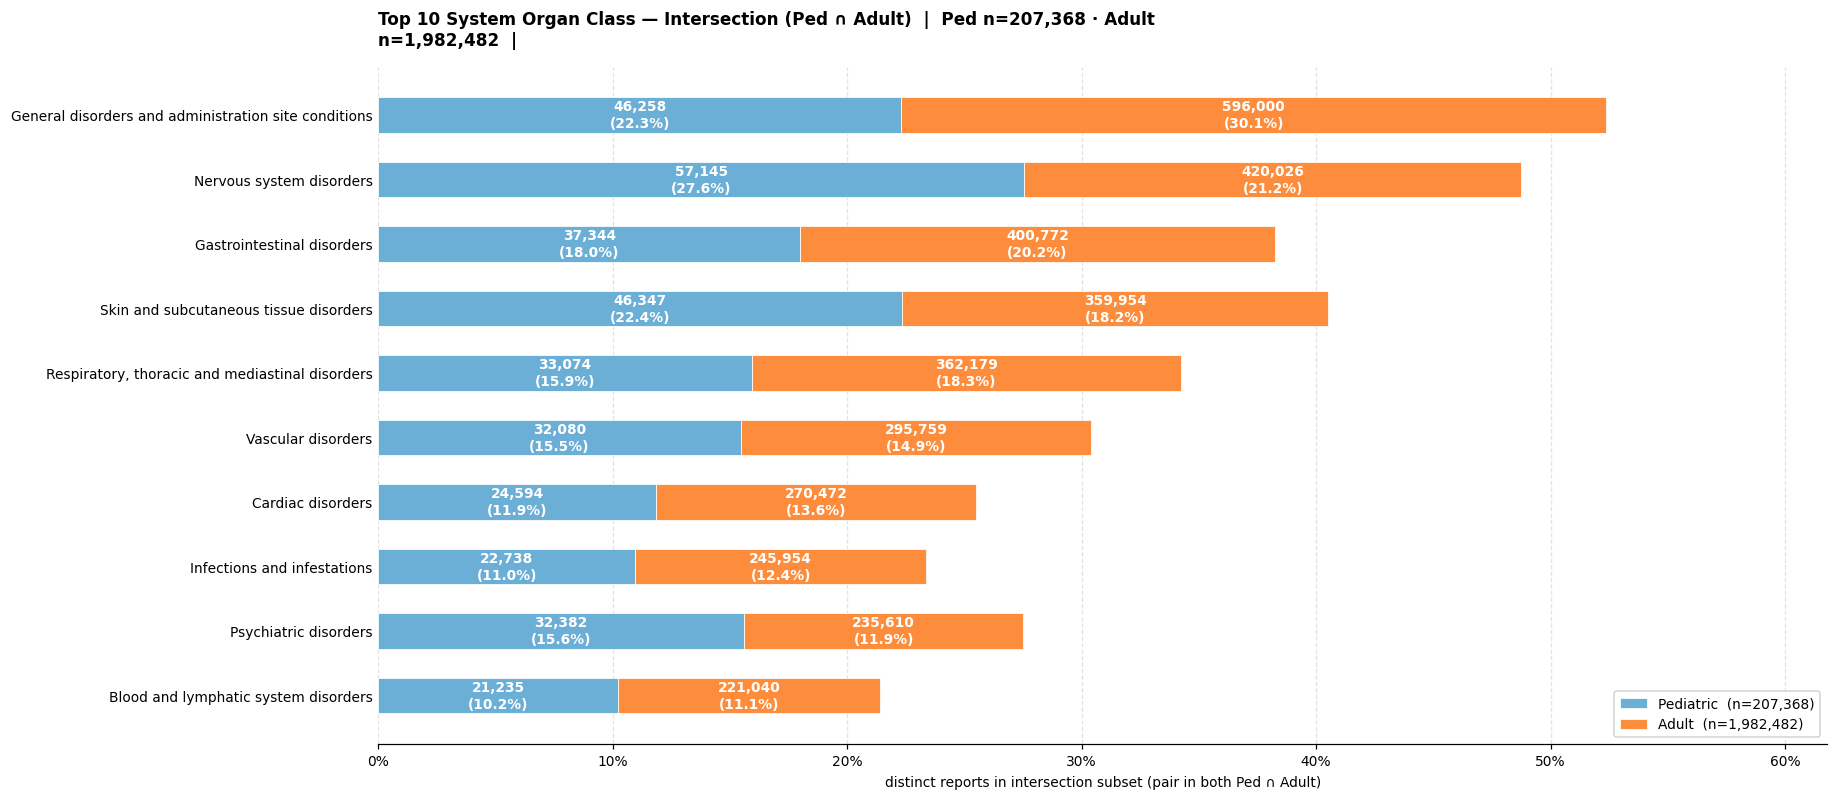

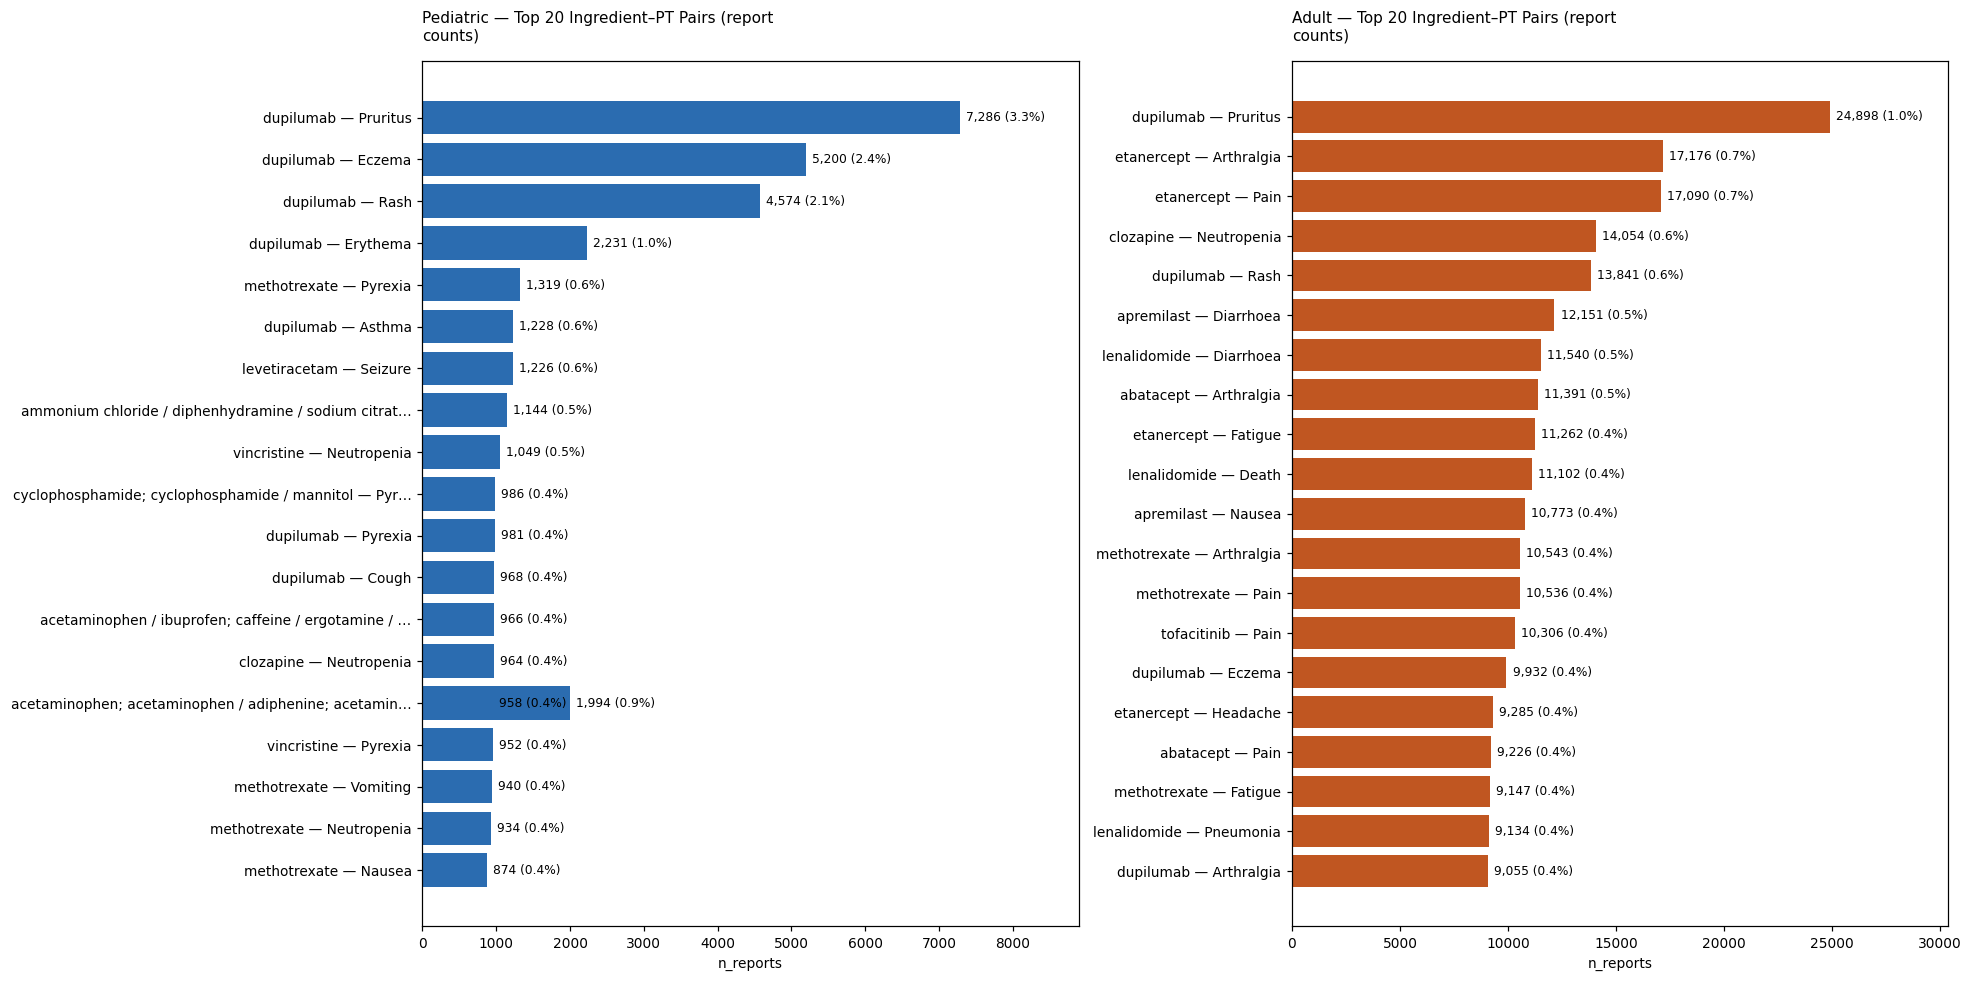

In [97]:
setup_plot_style()

# ── Plot 1: SOC — Full cohort (Ped vs Adult) ─────────────────────────────────
fig, ax = plot_barh_intersection(
    soc_full.rename(columns={"meddra_soc_names": "_soc"}),
    term_col="_soc", ped_col="n_ped", adu_col="n_adu",
    ped_denom=ped_total, adu_denom=adu_total,
    xlabel="distinct reports (Ped = unique reports with this SOC / Adult = unique reports with this SOC)",
    title=(
        f"Top {N_SOC} System Organ Class — Full Cohort  |  "
        f"Ped n={ped_total:,} · Adult n={adu_total:,}  |  "
    ),
    figsize=(17, 8),
)
plt.savefig("output/figures/top10_soc_full_cohort.png", dpi=300, bbox_inches="tight")
plt.show()

# ── Plot 2: SOC — Intersection ────────────────────────────────────────────────
fig, ax = plot_barh_intersection(
    soc_isect.rename(columns={"meddra_soc_names": "_soc"}),
    term_col="_soc", ped_col="n_ped", adu_col="n_adu",
    ped_denom=ped_isect_total, adu_denom=adu_isect_total,
    xlabel="distinct reports in intersection subset (pair in both Ped ∩ Adult)",
    title=(
        f"Top {N_SOC} System Organ Class — Intersection (Ped ∩ Adult)  |  "
        f"Ped n={ped_isect_total:,} · Adult n={adu_isect_total:,}  |  "
    ),
    figsize=(17, 8),
)
plt.savefig("output/figures/top10_soc_intersection.png", dpi=300, bbox_inches="tight")
plt.show()

# ── Plot 3: Ingredient–PT combinations ──────────────────────────────────────
combo_ped_plot = combo_ped.assign(_lbl=combo_ped["ingredient_pt_combination"].map(shorten_label))
combo_adu_plot = combo_adu.assign(_lbl=combo_adu["ingredient_pt_combination"].map(shorten_label))

fig, axes = plt.subplots(1, 2, figsize=(18, 9))
plot_barh_topn(
    combo_ped_plot, "_lbl", "n_reports",
    f"Pediatric — Top {N_TOP_COMBO} Ingredient–PT Pairs (report counts)",
    ax=axes[0],
    pct_denominator=ped_total,
)
plot_barh_topn(
    combo_adu_plot, "_lbl", "n_reports",
    f"Adult — Top {N_TOP_COMBO} Ingredient–PT Pairs (report counts)",
    ax=axes[1],
    color="#c05621",
    pct_denominator=adu_total,
)
plt.tight_layout()
plt.savefig("output/figures/top_ingredient_pt_pairs.png", dpi=300, bbox_inches="tight")
plt.show()


## Export ตาราง SOC / PT / Ingredient (optional)

บันทึก sample table และ top ingredient–PT combinations เป็น CSV

In [ ]:
from pathlib import Path

export_dir = Path("../data/notebook/output/top_terms_adult/csv")
export_dir.mkdir(parents=True, exist_ok=True)

# SOC tables
soc_full.to_csv(  export_dir / "top10_soc_full_cohort.csv",    index=False)
soc_isect.to_csv( export_dir / "top10_soc_intersection.csv",   index=False)

# Ingredient–PT combinations
combo_ped.to_csv( export_dir / "top_ingredient_pt_combinations_pediatric.csv", index=False)
combo_adu.to_csv( export_dir / "top_ingredient_pt_combinations_adult.csv",     index=False)

print("Exported to", export_dir)
print("  top10_soc_full_cohort.csv")
print("  top10_soc_intersection.csv")
print("  top_ingredient_pt_combinations_pediatric.csv")
print("  top_ingredient_pt_combinations_adult.csv")


Exported to output/csv
  top10_soc_full_cohort.csv
  top10_soc_intersection.csv
  top_ingredient_pt_combinations_pediatric.csv
  top_ingredient_pt_combinations_adult.csv


---

# E — Distribution Profile

# 9. Distribution Profile — Pediatric vs Adult

เปรียบเทียบ **distribution** ของ top categories ระหว่าง Pediatric กับ Adult cohort
ถ้า distribution ต่างกันมาก → แสดงว่า population คนละแบบ ซึ่งสนับสนุนการวิเคราะห์แยก cohort

## หัวข้อที่วิเคราะห์

| # | Category | ฟิลด์ | วิธีนับ |
|---|----------|-------|---------|
| 9.1 | **Top 20 SOC** | `meddra_soc_names` (explode list) | distinct reports per SOC ÷ total reports |
| 9.2 | **Top 20 PT** | `reaction_meddrapt` | distinct reports per PT ÷ total reports |
| 9.3 | **Top 20 Suspect Drug Products** | `medicinal_product` (char=`1`) | distinct reports per product ÷ total reports |
| 9.4 | **Top 20 Active Ingredients** | `ingredient` (explode, char=`1`) | distinct reports per substance ÷ total reports |

> **หมายเหตุ:** ไม่มีคอลัมน์ ATC drug class ใน dataset — ใช้ **active ingredient** เป็น proxy สำหรับ drug class  
> (10 brand products ของยาตัวเดียวกัน = 10 แถวใน products แต่ = 1 แถวใน ingredients)

## วิธีอ่านกราฟ

กราฟแสดง **% ของ cohort** ที่มี term นั้นอยู่ใน report  
- แถบน้ำเงิน = **Pediatric**, แถบส้ม = **Adult** (stacked ต่อกัน)
- เรียงลำดับตาม **Pediatric %** (มากสุดบนสุด)
- ถ้า Adult % น้อยกว่า Ped % มาก → term นั้นเด่นเฉพาะ Pediatric
- ดู **Jaccard overlap score** ท้าย section เพื่อวัดว่า top-20 term sets ซ้อนทับกันแค่ไหน  
  (J = 0 → ไม่มี overlap เลย · J = 1 → top-20 ตรงกันทุก term)

In [111]:
import polars as pl
import pandas as pd
import numpy as np

N_DIST = 20  # top N per category for distribution comparison


# ── Helper: top N by distinct reports — simple string column ─────────────────
def _dist_top_n_col(lf: pl.LazyFrame, col: str, n: int = N_DIST,
                    char_filter: str | None = None) -> pd.DataFrame:
    """Count unique safetyreportid per value of `col`; return top-n rows."""
    lf2 = lf.filter(pl.col("drug_characterization") == char_filter) if char_filter else lf
    return (
        lf2.filter(pl.col(col).is_not_null() & (pl.col(col).str.len_chars() > 0))
        .select(["safetyreportid", col])
        .unique()
        .group_by(col)
        .agg(pl.col("safetyreportid").n_unique().alias("n_reports"))
        .sort("n_reports", descending=True)
        .head(n)
        .collect(engine="streaming")
        .to_pandas()
    )


# ── Helper: top N — list column (explode first) ───────────────────────────────
def _dist_top_n_list(lf: pl.LazyFrame, col: str, n: int = N_DIST,
                     char_filter: str | None = None) -> pd.DataFrame:
    """Explode list column, deduplicate (report, term), count distinct reports."""
    lf2 = lf.filter(pl.col("drug_characterization") == char_filter) if char_filter else lf
    return (
        lf2.explode(col)
        .filter(pl.col(col).is_not_null() & (pl.col(col).str.len_chars() > 0))
        .select(["safetyreportid", col])
        .unique()
        .group_by(col)
        .agg(pl.col("safetyreportid").n_unique().alias("n_reports"))
        .sort("n_reports", descending=True)
        .head(n)
        .collect(engine="streaming")
        .to_pandas()
    )


# ── Helper: outer-join Ped + Adult, sort by Ped rank ─────────────────────────
def _dist_merge(ped_df, adu_df, term_col, ped_total, adu_total, n: int = N_DIST) -> pd.DataFrame:
    """Outer-join two top-N tables; sort by n_ped desc; annotate % columns."""
    m = (
        ped_df[[term_col, "n_reports"]].rename(columns={"n_reports": "n_ped"})
        .merge(
            adu_df[[term_col, "n_reports"]].rename(columns={"n_reports": "n_adu"}),
            on=term_col, how="outer",
        )
        .assign(
            n_ped=lambda d: d["n_ped"].fillna(0).astype(int),
            n_adu=lambda d: d["n_adu"].fillna(0).astype(int),
        )
        .sort_values("n_ped", ascending=False)
        .head(n)
        .reset_index(drop=True)
    )
    m.insert(0, "rank", range(1, len(m) + 1))
    m["pct_ped"] = (100.0 * m["n_ped"] / ped_total).round(2)
    m["pct_adu"] = (100.0 * m["n_adu"] / adu_total).round(2)
    return m


# ── 9.1 Top 20 SOC ───────────────────────────────────────────────────────────
print("(9.1) Computing top 20 SOC...")
_d_soc_ped, _ = _top_soc_n(lf_ped_pl, n=N_DIST)   # reuse helper from cell 47
_d_soc_adu, _ = _top_soc_n(lf_adu_pl, n=N_DIST)
dist_soc20 = _merge_soc(_d_soc_ped, ped_total, _d_soc_adu, adu_total, n=N_DIST)
print(f"  → {len(dist_soc20)} rows")

# ── 9.2 Top 20 PT ────────────────────────────────────────────────────────────
print("(9.2) Computing top 20 PT...")
_d_pt_ped = _dist_top_n_col(lf_ped_pl, "reaction_meddrapt")
_d_pt_adu = _dist_top_n_col(lf_adu_pl, "reaction_meddrapt")
dist_pt20 = _dist_merge(_d_pt_ped, _d_pt_adu, "reaction_meddrapt", ped_total, adu_total)
print(f"  → {len(dist_pt20)} rows")

# ── 9.3 Top 20 Suspect Drug Products (drug_characterization = '1') ───────────
print("(9.3) Computing top 20 suspect drug products (char='1')...")
_d_prod_ped = _dist_top_n_col(lf_ped_pl, "medicinal_product", char_filter="1")
_d_prod_adu = _dist_top_n_col(lf_adu_pl, "medicinal_product", char_filter="1")
dist_prod20 = _dist_merge(_d_prod_ped, _d_prod_adu, "medicinal_product", ped_total, adu_total)
print(f"  → {len(dist_prod20)} rows")

# ── 9.4 Top 20 Active Ingredients — Drug Class Proxy (char = '1', explode) ───
print("(9.4) Computing top 20 active ingredients (char='1', explode)...")
_d_ingr_ped = _dist_top_n_list(lf_ped_pl, "ingredient", char_filter="1")
_d_ingr_adu = _dist_top_n_list(lf_adu_pl, "ingredient", char_filter="1")
dist_ingr20 = _dist_merge(_d_ingr_ped, _d_ingr_adu, "ingredient", ped_total, adu_total)
print(f"  → {len(dist_ingr20)} rows\n")

print("Preview — Top 20 SOC:")
display(dist_soc20[["rank", "meddra_soc_names", "n_ped", "pct_ped", "n_adu", "pct_adu"]])
print("\nPreview — Top 20 PT:")
display(dist_pt20[["rank", "reaction_meddrapt", "n_ped", "pct_ped", "n_adu", "pct_adu"]])

(9.1) Computing top 20 SOC...
  → 20 rows
(9.2) Computing top 20 PT...
  → 20 rows
(9.3) Computing top 20 suspect drug products (char='1')...
  → 0 rows
(9.4) Computing top 20 active ingredients (char='1', explode)...
  → 0 rows

Preview — Top 20 SOC:


,rank,meddra_soc_names,n_ped,pct_ped,n_adu,pct_adu
0,1,General disorders and administration site cond...,50068,22.64,751780,29.99
1,2,Nervous system disorders,61033,27.59,579581,23.12
2,3,Gastrointestinal disorders,39867,18.02,508991,20.31
3,4,Skin and subcutaneous tissue disorders,49079,22.19,481596,19.21
4,5,"Respiratory, thoracic and mediastinal disorders",36757,16.62,466758,18.62
5,6,Vascular disorders,34385,15.55,410091,16.36
6,7,Cardiac disorders,26048,11.78,351389,14.02
7,8,Psychiatric disorders,34865,15.76,338677,13.51
8,9,Infections and infestations,25594,11.57,345054,13.77
9,10,Blood and lymphatic system disorders,22492,10.17,273311,10.90



Preview — Top 20 PT:


,rank,reaction_meddrapt,n_ped,pct_ped,n_adu,pct_adu
0,1,Vomiting,15316,6.92,107504,4.29
1,2,Pyrexia,14953,6.76,98993,3.95
2,3,Rash,11193,5.06,107114,4.27
3,4,Pruritus,11109,5.02,96556,3.85
4,5,Nausea,11108,5.02,174269,6.95
5,6,Headache,9834,4.45,124671,4.97
6,7,Seizure,8656,3.91,0,0.00
7,8,Diarrhoea,7484,3.38,159786,6.38
8,9,Somnolence,6954,3.14,0,0.00
9,10,Dyspnoea,6813,3.08,143851,5.74


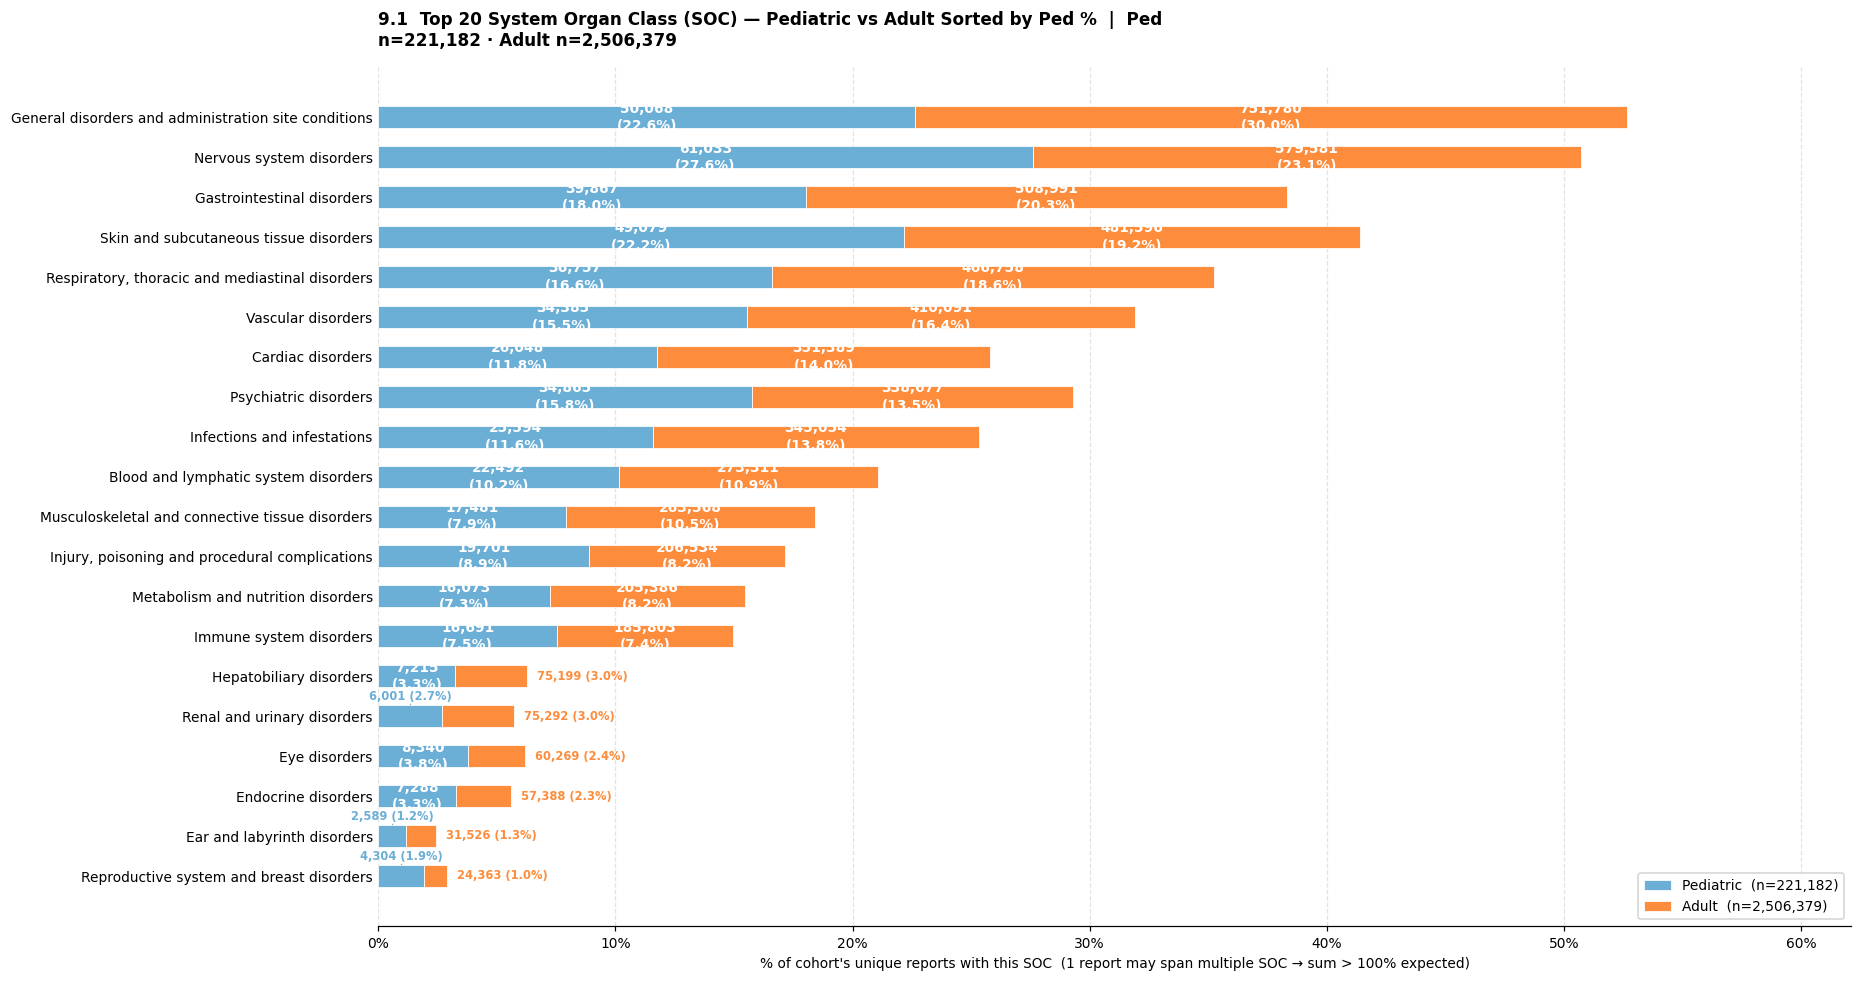

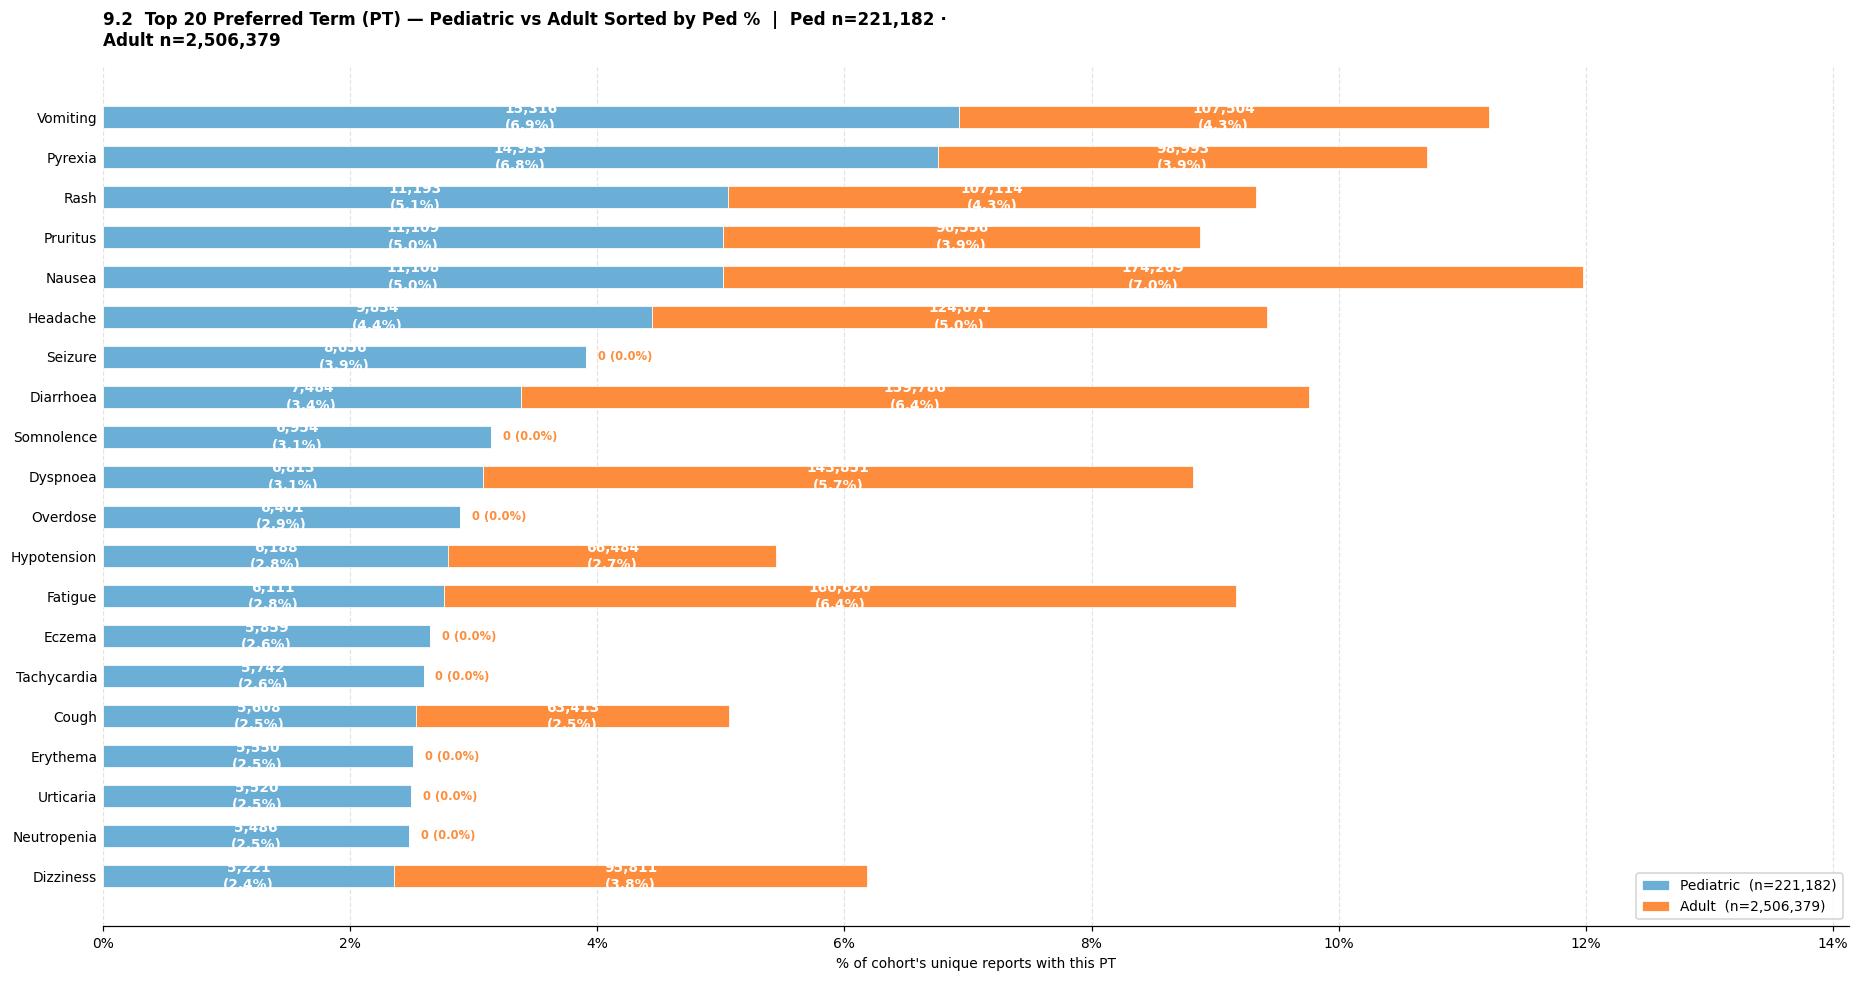

ValueError: zero-size array to reduction operation maximum which has no identity

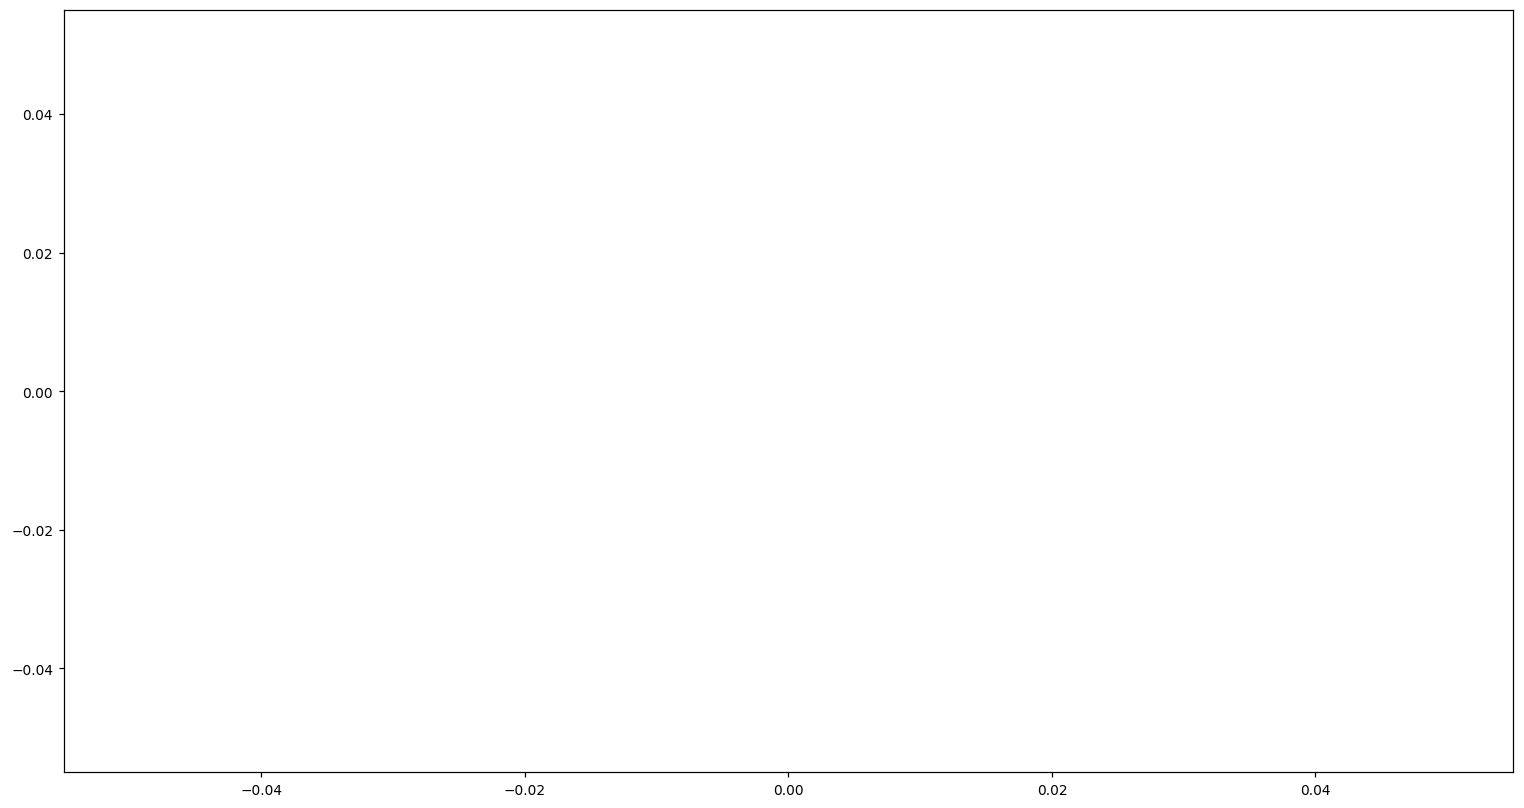

In [112]:
from pathlib import Path

setup_plot_style()
figures_dir = Path("../data/notebook/output/top_terms_adult/figures")
figures_dir.mkdir(parents=True, exist_ok=True)

# ── 9.1 Top 20 SOC ──────────────────────────────────────────────────────────
fig, _ = plot_barh_intersection(
    dist_soc20.rename(columns={"meddra_soc_names": "_term"}),
    term_col="_term", ped_col="n_ped", adu_col="n_adu",
    ped_denom=ped_total, adu_denom=adu_total,
    title=(
        f"9.1  Top {N_DIST} System Organ Class (SOC) — Pediatric vs Adult\n"
        f"Sorted by Ped %  |  Ped n={ped_total:,} · Adult n={adu_total:,}"
    ),
    xlabel="% of cohort's unique reports with this SOC  (1 report may span multiple SOC → sum > 100% expected)",
    figsize=(17, 9),
)
plt.tight_layout()
plt.savefig(figures_dir / "dist_top20_soc.png", dpi=150, bbox_inches="tight")
plt.show()

# ── 9.2 Top 20 PT ────────────────────────────────────────────────────────────
fig, _ = plot_barh_intersection(
    dist_pt20.assign(_term=dist_pt20["reaction_meddrapt"].map(shorten_label)),
    term_col="_term", ped_col="n_ped", adu_col="n_adu",
    ped_denom=ped_total, adu_denom=adu_total,
    title=(
        f"9.2  Top {N_DIST} Preferred Term (PT) — Pediatric vs Adult\n"
        f"Sorted by Ped %  |  Ped n={ped_total:,} · Adult n={adu_total:,}"
    ),
    xlabel="% of cohort's unique reports with this PT",
    figsize=(17, 9),
)
plt.tight_layout()
plt.savefig(figures_dir / "dist_top20_pt.png", dpi=150, bbox_inches="tight")
plt.show()

# ── 9.3 Top 20 Suspect Drug Products ─────────────────────────────────────────
fig, _ = plot_barh_intersection(
    dist_prod20.assign(_term=dist_prod20["medicinal_product"].map(shorten_label)),
    term_col="_term", ped_col="n_ped", adu_col="n_adu",
    ped_denom=ped_total, adu_denom=adu_total,
    title=(
        f"9.3  Top {N_DIST} Suspect Drug Products — Pediatric vs Adult\n"
        f"Sorted by Ped %  |  drug_characterization = '1'  |  Ped n={ped_total:,} · Adult n={adu_total:,}"
    ),
    xlabel="% of cohort's unique reports listing this product as primary suspect",
    figsize=(17, 9),
)
plt.tight_layout()
plt.savefig(figures_dir / "dist_top20_suspect_products.png", dpi=150, bbox_inches="tight")
plt.show()

# ── 9.4 Top 20 Active Ingredients (Drug Class Proxy) ─────────────────────────
fig, _ = plot_barh_intersection(
    dist_ingr20.assign(_term=dist_ingr20["ingredient"].map(shorten_label)),
    term_col="_term", ped_col="n_ped", adu_col="n_adu",
    ped_denom=ped_total, adu_denom=adu_total,
    title=(
        f"9.4  Top {N_DIST} Active Ingredients (Drug Class Proxy) — Pediatric vs Adult\n"
        f"Sorted by Ped %  |  drug_characterization = '1', ingredient exploded  |  "
        f"Ped n={ped_total:,} · Adult n={adu_total:,}"
    ),
    xlabel="% of cohort's unique reports listing this ingredient as primary suspect",
    figsize=(17, 9),
)
plt.tight_layout()
plt.savefig(figures_dir / "dist_top20_ingredients.png", dpi=150, bbox_inches="tight")
plt.show()

print("Figures saved to", figures_dir)

In [ ]:
# ── Jaccard overlap: how similar are Ped vs Adult top-20 term sets? ──────────
# Jaccard(A, B) = |A ∩ B| / |A ∪ B|
# J = 0 → no overlap · J = 1 → identical sets
# Low J → distributions are very different → stronger evidence for separate populations

def _jaccard(set_a: set, set_b: set):
    inter = len(set_a & set_b)
    union = len(set_a | set_b)
    return round(inter / union, 3) if union > 0 else 0.0, inter

soc_j,  soc_shared  = _jaccard(set(_d_soc_ped["meddra_soc_names"].dropna()),
                                set(_d_soc_adu["meddra_soc_names"].dropna()))
pt_j,   pt_shared   = _jaccard(set(_d_pt_ped["reaction_meddrapt"].dropna()),
                                set(_d_pt_adu["reaction_meddrapt"].dropna()))
prod_j, prod_shared = _jaccard(set(_d_prod_ped["medicinal_product"].dropna()),
                                set(_d_prod_adu["medicinal_product"].dropna()))
ingr_j, ingr_shared = _jaccard(set(_d_ingr_ped["ingredient"].dropna()),
                                set(_d_ingr_adu["ingredient"].dropna()))

overlap_summary = pd.DataFrame({
    "Category": ["9.1  SOC", "9.2  PT", "9.3  Suspect Drug Products", "9.4  Active Ingredients"],
    "Top-N": [N_DIST] * 4,
    "Shared terms (Ped ∩ Adult)": [soc_shared, pt_shared, prod_shared, ingr_shared],
    "Jaccard (J)": [soc_j, pt_j, prod_j, ingr_j],
})
overlap_summary["Interpretation"] = overlap_summary["Jaccard (J)"].apply(
    lambda j: (
        "สูง — distribution คล้ายกัน" if j >= 0.6
        else "ปานกลาง — มีความแตกต่างบางส่วน" if j >= 0.35
        else "ต่ำ — distribution ต่างกันมาก → population คนละแบบ"
    )
)
print("=" * 60)
print("Distribution Overlap Summary — Pediatric vs Adult top-20")
print("=" * 60)
display(overlap_summary)

# ── Export CSV ────────────────────────────────────────────────────────────────
from pathlib import Path

csv_dir = Path("../data/notebook/output/top_terms_adult/csv")
csv_dir.mkdir(parents=True, exist_ok=True)

dist_soc20.to_csv( csv_dir / "dist_top20_soc.csv",              index=False)
dist_pt20.to_csv(  csv_dir / "dist_top20_pt.csv",               index=False)
dist_prod20.to_csv(csv_dir / "dist_top20_suspect_products.csv", index=False)
dist_ingr20.to_csv(csv_dir / "dist_top20_ingredients.csv",      index=False)
overlap_summary.to_csv(csv_dir / "dist_overlap_summary.csv",    index=False)

print("\nExported to", csv_dir)
for fname in ["dist_top20_soc.csv", "dist_top20_pt.csv",
              "dist_top20_suspect_products.csv", "dist_top20_ingredients.csv",
              "dist_overlap_summary.csv"]:
    print(f"  {fname}")